Pick whether the notebook should be run for G-SIBs or O-SIIs or both

In [142]:
# Choose group ONCE here
# =========================
GROUP = "BOTH"   # options: "GSIB", "OSII", "BOTH"

# Choose run to plot
PLOT_RUN = "OSII_C" # "GSIB", "OSII_A", "OSII_B", "OSII_C"

### Packages

In [143]:
# Python packages
import numpy as np
import pandas as pd
import datetime
import pandas_datareader.data as web
import re
from arch import arch_model
from typing import Union
from scipy.stats import norm

In [144]:
# R packages
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri, numpy2ri, r, globalenv, default_converter
from rpy2.robjects.packages import importr
from rpy2.robjects.conversion import localconverter
from rpy2.robjects.vectors import StrVector

base = importr('base')
methods = importr('methods')
rugarch = importr('rugarch')
rmgarch = importr('rmgarch')

Matplotlib settings

In [145]:
# For the most beautiful plots!
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams["text.usetex"] = False

mpl.rcParams.update({
    # Fonts + sizes
    "font.family": "serif",
    "font.serif": ["STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,

    # Ticks
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,

    # Lines / axes / legend
    "axes.linewidth": 0.7,
    "lines.linewidth": 0.6,
    "legend.frameon": True,
    "axes.xmargin":(0.02),

    # Grid style (but not on/off)
    "axes.grid": False,
    "grid.alpha": 0.18,
    "grid.linewidth": 0.6,
    "grid.linestyle": "-",
})

# Output folder (created once)
FIG_DIR = Path("./Outputs/Figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Canonical sizes for your LaTeX document
FIG_FULL = (6.5, 3.2)   # ~ \textwidth
FIG_HALF = (3.2, 2.4)   # ~ 0.49\textwidth (two side-by-side)

%config InlineBackend.figure_format = 'retina'
mpl.rcParams["figure.dpi"] = 160      # bigger/sharper in notebook
mpl.rcParams["savefig.dpi"] = 300     # only affects PNG exports, PDF unaffected

### Data collection & initial visualization

Load and build datasets for G-SIBs, O-SIIs from Data request file.

In [146]:
# Load + Standardize + Build RUNS
# =========================

excel_file = pd.ExcelFile("./Data GSIBs OSIIs.xlsx", engine="openpyxl")
print("Sheet names:", excel_file.sheet_names)

# ---- Load sheets ----
GSIBs = excel_file.parse("G-SIBs")
OSIIs = excel_file.parse("O-SIIs")

GSIBs_prices = excel_file.parse("G-SIBs Price")
GSIBs_equity = excel_file.parse("G-SIBs Marktwaarde")
GSIBs_liabilities = excel_file.parse("G-SIBs Liabilities")
GSIBs_assets = excel_file.parse("G-SIBs Assets")

OSIIs_prices = excel_file.parse("O-SIIs Price")
OSIIs_equity = excel_file.parse("O-SIIs Marktwaarde")
OSIIs_liabilities = excel_file.parse("O-SIIs Liabilities")
OSIIs_assets = excel_file.parse("O-SIIs Assets")

MSCI_indices = excel_file.parse("MSCI Indices")

# ---- Helpers ----
def standardize_datetime_index(df: pd.DataFrame, date_col: str = "DATE") -> pd.DataFrame:
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.set_index(date_col)
    df = df.sort_index()  # ✅ old -> new
    return df

def period_to_quarter_end(s: str) -> Union[pd.Timestamp, pd.NaT]:
    if not isinstance(s, str):
        return pd.NaT
    m = re.match(r"^Q([1-4])\s+(\d{4})$", s.strip())
    if not m:
        return pd.NaT
    q = int(m.group(1))
    y = int(m.group(2))
    p = pd.Period(f"{y}Q{q}", freq="Q-DEC")
    return p.to_timestamp(how="end").normalize()

def standardize_quarter_index(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["PERIOD"] = df["PERIOD"].apply(period_to_quarter_end)
    df = df.set_index("PERIOD")
    df = df.sort_index()  # ✅ old -> new
    return df

def to_numeric_millions(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    return df.apply(pd.to_numeric, errors="coerce") / 1000

# ---- Standardize daily indices ----
GSIBs_prices = standardize_datetime_index(GSIBs_prices, "DATE")
GSIBs_equity = standardize_datetime_index(GSIBs_equity, "DATE")

OSIIs_prices = standardize_datetime_index(OSIIs_prices, "DATE")
OSIIs_equity = standardize_datetime_index(OSIIs_equity, "DATE")

MSCI_indices = standardize_datetime_index(MSCI_indices, "DATE")

# ---- Standardize quarterly indices ----
GSIBs_liabilities = standardize_quarter_index(GSIBs_liabilities)
GSIBs_assets      = standardize_quarter_index(GSIBs_assets)
OSIIs_liabilities = standardize_quarter_index(OSIIs_liabilities)
OSIIs_assets      = standardize_quarter_index(OSIIs_assets)

# ---- Convert liabilities/assets thousands -> millions ----
GSIBs_liabilities = to_numeric_millions(GSIBs_liabilities)
GSIBs_assets      = to_numeric_millions(GSIBs_assets)
OSIIs_liabilities = to_numeric_millions(OSIIs_liabilities)
OSIIs_assets      = to_numeric_millions(OSIIs_assets)

# ---- Drop bad OSIIs ---- where data is not high-frequency or otherwise problematic
drop_bad_osiis = [
    "BQ.INTL.LUXEMBOURG",
    "MONTEPIO",
    "BANCO BPI DEAD - DELIST.18/12/18",
    "PRIMA BANKA SLOVENSKO 2",
    "HRVATSKA POSTANSKA BANKA",
    "TATRA BANKA",
    "ARTEA BANKAS",
    "APS BANK",
    "SPAR NORD BANK",
]

for _df_name in ["OSIIs_prices", "OSIIs_equity", "OSIIs_liabilities", "OSIIs_assets"]:
    _df = globals()[_df_name]
    globals()[_df_name] = _df.drop(columns=[c for c in drop_bad_osiis if c in _df.columns], errors="ignore")


# ---- Convert UK GBp -> GBP (if columns exist) ----
uk_gbp_cols = ["HSBC HOLDINGS", "BARCLAYS", "STANDARD CHARTERED"]

GSIBs_prices.columns = GSIBs_prices.columns.astype(str).str.strip()
OSIIs_prices.columns = OSIIs_prices.columns.astype(str).str.strip()

for df_prices in [GSIBs_prices, OSIIs_prices]:
    existing_cols = [c for c in uk_gbp_cols if c in df_prices.columns]
    df_prices[existing_cols] = df_prices[existing_cols] / 100

# =========================
# Create RUNS
# =========================

runs = {}

run_gsib = GROUP in ["GSIB", "BOTH"]
run_osii = GROUP in ["OSII", "BOTH"]

# ---- GSIB run ----
if run_gsib:
    runs["GSIB"] = {
        "banks": GSIBs,
        "prices": GSIBs_prices.copy(),
        "equity": GSIBs_equity.copy(),
        "liabilities": GSIBs_liabilities.copy(),
        "assets": GSIBs_assets.copy(),
        "msci": MSCI_indices.copy(),
    }

# ---- OSII splits: A/B/C based on series length ----
if run_osii:
    # replace '#N/A' once for length computation
    tmp_prices = OSIIs_prices.replace("#N/A", np.nan)
    lengths = tmp_prices.notna().sum().sort_values(ascending=False)

    # Base thresholds
    osii_A = lengths[lengths > 6200].index.tolist()

    # CUMULATIVE splits (nested): A ⊂ B ⊂ C
    osii_B = lengths[lengths > 4700].index.tolist()
    osii_C = lengths[lengths > 2000].index.tolist()

    # Ensure stable nesting + ordering (A first, then extras)
    osii_B = osii_A + [c for c in osii_B if c not in osii_A]
    osii_C = osii_B + [c for c in osii_C if c not in osii_B]

    # (Optional) sanity checks
    assert set(osii_A).issubset(osii_B)
    assert set(osii_B).issubset(osii_C)

    osii_B_extra = [c for c in osii_B if c not in osii_A]
    osii_C_extra = [c for c in osii_C if c not in osii_B]

    print("\n====== OSII split summary (nested) ======")
    print(f"OSII_A (>6200): {len(osii_A)} banks")
    print(f"OSII_B (>4700): {len(osii_B)} banks  (adds {len(osii_B_extra)} vs A)")
    print(f"OSII_C (>2000): {len(osii_C)} banks  (adds {len(osii_C_extra)} vs B)")

    for key, cols in [("OSII_A", osii_A), ("OSII_B", osii_B), ("OSII_C", osii_C)]:
        cols = [c for c in cols if c in OSIIs_prices.columns]  # safety
        runs[key] = {
            "banks": OSIIs,
            "prices": OSIIs_prices[cols].copy(),
            "equity": OSIIs_equity.reindex(columns=cols).copy(),
            "liabilities": OSIIs_liabilities.reindex(columns=cols).copy(),
            "assets": OSIIs_assets.reindex(columns=cols).copy(),
            "msci": MSCI_indices.copy(),
        }

print("\n✅ Runs created:", list(runs.keys()))

Sheet names: ['G-SIBs', 'G-SIBs Price', 'G-SIBs Marktwaarde', 'G-SIBs Liabilities', 'G-SIBs Assets', 'O-SIIs', 'O-SIIs Price', 'O-SIIs Marktwaarde', 'O-SIIs Liabilities', 'O-SIIs Assets', 'MSCI Indices']

====== OSII split summary (nested) ======
OSII_A (>6200): 47 banks
OSII_B (>4700): 52 banks  (adds 5 vs A)
OSII_C (>2000): 56 banks  (adds 4 vs B)

✅ Runs created: ['GSIB', 'OSII_A', 'OSII_B', 'OSII_C']


### Data processing

Select groups, split O-SIIs depending on length, add MSCI index

In [147]:
# Process each run (GSIB + OSII_A/B/C)
# =========================

initial_date = pd.Timestamp("2008-01-01")

def get_msci_series(msci_df: pd.DataFrame, run_name: str) -> pd.Series:
    """
    - GSIB: MSCI World (Banks)
    - OSII_*: MSCI Europe Banks
    Falls back to the 2nd column if no match found.
    """
    df = msci_df.copy()
    df.columns = df.columns.astype(str).str.strip()

    if run_name == "GSIB":
        desired_name = "MSCI World Banks"
        keyword_sets = [("world", "banks"), ("world",)]
    else:
        desired_name = "MSCI Europe Banks"
        keyword_sets = [("europe", "banks"), ("europe",), ("euro", "banks")]

    for kw in keyword_sets:
        for c in df.columns:
            if all(k in c.lower() for k in kw):
                s = df[c].copy()
                s.name = desired_name
                return s

    s = df.iloc[:, 1].copy()
    s.name = desired_name
    return s


def clean_gsib(run_dict: dict, msci_df: pd.DataFrame):
    prices = run_dict["prices"].copy().replace("#N/A", np.nan)
    equity = run_dict["equity"].copy()
    liabilities = run_dict["liabilities"].copy()
    assets = run_dict["assets"].copy()

    # 1) drop banks with late start
    first_valid = prices.apply(lambda s: s.first_valid_index())
    too_late_cols = first_valid[first_valid > initial_date].index
    prices = prices.drop(columns=too_late_cols, errors="ignore")

    # 2) drop banks with any NA after 2008-01-01
    na_after_date = prices.loc[prices.index > initial_date].isna().any(axis=0)
    cols_with_na_after_date = na_after_date[na_after_date].index
    prices_omitted = prices.drop(columns=cols_with_na_after_date, errors="ignore")

    # 3) drop rows with any NA
    prices_clean = prices_omitted.dropna(axis=0, how="any")
    dropped_rows = prices_omitted.index.difference(prices_clean.index)

    # align other frames to kept columns
    keep_cols = prices_clean.columns
    equity = equity.reindex(columns=keep_cols)
    liabilities = liabilities.reindex(columns=keep_cols)
    assets = assets.reindex(columns=keep_cols)

    # add MSCI World Banks
    msci_series = get_msci_series(msci_df, "GSIB").replace("#N/A", np.nan)
    msci_series = msci_series.reindex(prices_clean.index)
    assert prices_clean.index.equals(msci_series.index), "MSCI index and GSIB prices index not aligned!"

    if msci_series.name not in prices_clean.columns:
        prices_clean.insert(0, msci_series.name, msci_series)

    print("\n====== GSIB cleaning summary ======")
    print(f"Dropped columns (late start > {initial_date.date()}): {len(too_late_cols)}")
    print(f"Dropped columns (NA after {initial_date.date()}): {len(cols_with_na_after_date)}")
    print(f"Remaining banks: {prices_clean.shape[1] - 1} (excluding MSCI col)")
    print(f"Dropped rows due to missing values: {len(dropped_rows)}")

    return prices_clean, equity, liabilities, assets


def clean_osii_panel(run_dict: dict, run_name: str, msci_df: pd.DataFrame):
    """
    OSII_A/B/C cleaning:
    - '#N/A' -> NaN
    - drop rows with any NA (within this split)
    - align equity/liabilities/assets
    - add MSCI Europe Banks
    """
    prices = run_dict["prices"].copy().replace("#N/A", np.nan)
    equity = run_dict["equity"].copy()
    liabilities = run_dict["liabilities"].copy()
    assets = run_dict["assets"].copy()

    # drop rows with any NA so split becomes a clean panel
    prices_clean = prices.dropna(axis=0, how="any")

    keep_cols = prices_clean.columns
    equity = equity.reindex(columns=keep_cols)
    liabilities = liabilities.reindex(columns=keep_cols)
    assets = assets.reindex(columns=keep_cols)

    msci_series = get_msci_series(msci_df, run_name).replace("#N/A", np.nan)
    msci_series = msci_series.reindex(prices_clean.index)
    assert prices_clean.index.equals(msci_series.index), f"MSCI index and {run_name} prices index not aligned!"

    if msci_series.name not in prices_clean.columns:
        prices_clean.insert(0, msci_series.name, msci_series)

    print(f"\n====== {run_name} cleaning summary ======")
    print(f"Banks: {len(keep_cols)}")
    print(f"Rows: {prices_clean.shape[0]}")

    return prices_clean, equity, liabilities, assets


# -----------------------------
# Main processing
# -----------------------------
new_runs = {}

for run_name, r in runs.items():
    if run_name == "GSIB":
        p, e, l, a = clean_gsib(r, r["msci"])
    else:
        p, e, l, a = clean_osii_panel(r, run_name, r["msci"])

    new_runs[run_name] = {**r, "prices": p, "equity": e, "liabilities": l, "assets": a}

runs = new_runs

# =========================
# Create convenient aliases for downstream cells
# =========================

prices_by_run = {k: v["prices"] for k, v in runs.items()}
equity_by_run = {k: v["equity"] for k, v in runs.items()}
liabilities_by_run = {k: v["liabilities"] for k, v in runs.items()}
assets_by_run = {k: v["assets"] for k, v in runs.items()}

# Backwards-ish compatible names for GSIB
GSIBs_prices = prices_by_run.get("GSIB", pd.DataFrame())
GSIBs_equity = equity_by_run.get("GSIB", pd.DataFrame())
GSIBs_liabilities = liabilities_by_run.get("GSIB", pd.DataFrame())
GSIBs_assets = assets_by_run.get("GSIB", pd.DataFrame())

# Per-split globals for OSII (so different lengths remain separate)
OSII_A_prices = prices_by_run.get("OSII_A", pd.DataFrame())
OSII_B_prices = prices_by_run.get("OSII_B", pd.DataFrame())
OSII_C_prices = prices_by_run.get("OSII_C", pd.DataFrame())

OSII_A_equity = equity_by_run.get("OSII_A", pd.DataFrame())
OSII_B_equity = equity_by_run.get("OSII_B", pd.DataFrame())
OSII_C_equity = equity_by_run.get("OSII_C", pd.DataFrame())

OSII_A_liabilities = liabilities_by_run.get("OSII_A", pd.DataFrame())
OSII_B_liabilities = liabilities_by_run.get("OSII_B", pd.DataFrame())
OSII_C_liabilities = liabilities_by_run.get("OSII_C", pd.DataFrame())

OSII_A_assets = assets_by_run.get("OSII_A", pd.DataFrame())
OSII_B_assets = assets_by_run.get("OSII_B", pd.DataFrame())
OSII_C_assets = assets_by_run.get("OSII_C", pd.DataFrame())

print("\n✅ Finished processing for:", list(runs.keys()))

# Optional quick preview
for k in ["GSIB", "OSII_A", "OSII_B", "OSII_C"]:
    if k in runs:
        print(f"\n=== {k} prices preview ===")
        print(runs[k]["prices"].iloc[:5, :4])



====== GSIB cleaning summary ======
Dropped columns (late start > 2008-01-01): 1
Dropped columns (NA after 2008-01-01): 0
Remaining banks: 27 (excluding MSCI col)
Dropped rows due to missing values: 1780

====== OSII_A cleaning summary ======
Banks: 47
Rows: 6237

====== OSII_B cleaning summary ======
Banks: 52
Rows: 4718

====== OSII_C cleaning summary ======
Banks: 56
Rows: 2098

✅ Finished processing for: ['GSIB', 'OSII_A', 'OSII_B', 'OSII_C']

=== GSIB prices preview ===
            MSCI World Banks  ROYAL BANK OF CANADA  TORONTO DOMINION  \
DATE                                                                   
2006-10-27           145.572                 49.52             32.22   
2006-10-30           145.185                 49.65             32.33   
2006-10-31           145.080                 49.80             32.55   
2006-11-01           145.511                 50.40             32.74   
2006-11-02           144.741                 51.60             33.47   

            UB

Compute returns

In [148]:
# Compute returns for each run
# =========================
def calculate_log_returns(df):
    df = df.apply(pd.to_numeric, errors="coerce")
    return 100 * np.log(df / df.shift(1)).dropna(how="all")

returns_by_run = {}

for run_name, prices in prices_by_run.items():
    returns = calculate_log_returns(prices)
    returns = returns - returns.mean()
    returns_by_run[run_name] = returns

# Print a preview
for k, ret in returns_by_run.items():
    print(f"\n=== {k} returns preview ===")
    print(ret.iloc[:5, :4])


=== GSIB returns preview ===
            MSCI World Banks  ROYAL BANK OF CANADA  TORONTO DOMINION  \
DATE                                                                   
2006-10-30         -0.270448              0.233661          0.315445   
2006-10-31         -0.076594              0.273144          0.652802   
2006-11-01          0.292391              1.169104          0.556644   
2006-11-02         -0.534821              2.324534          2.179818   
2006-11-03          0.189705              0.087696         -0.264682   

            UBS GROUP  
DATE                   
2006-10-30  -0.746118  
2006-10-31  -5.163071  
2006-11-01   0.887788  
2006-11-02  -1.123795  
2006-11-03   0.823921  

=== OSII_A returns preview ===
            MSCI Europe Banks  ERSTE GROUP BANK  KBC GROUP  HELLENIC BANK
DATE                                                                     
2001-12-14          -0.454785         -1.391104  -3.369973      -0.680694
2001-12-17           2.285839          0.42

Visualize some log returns

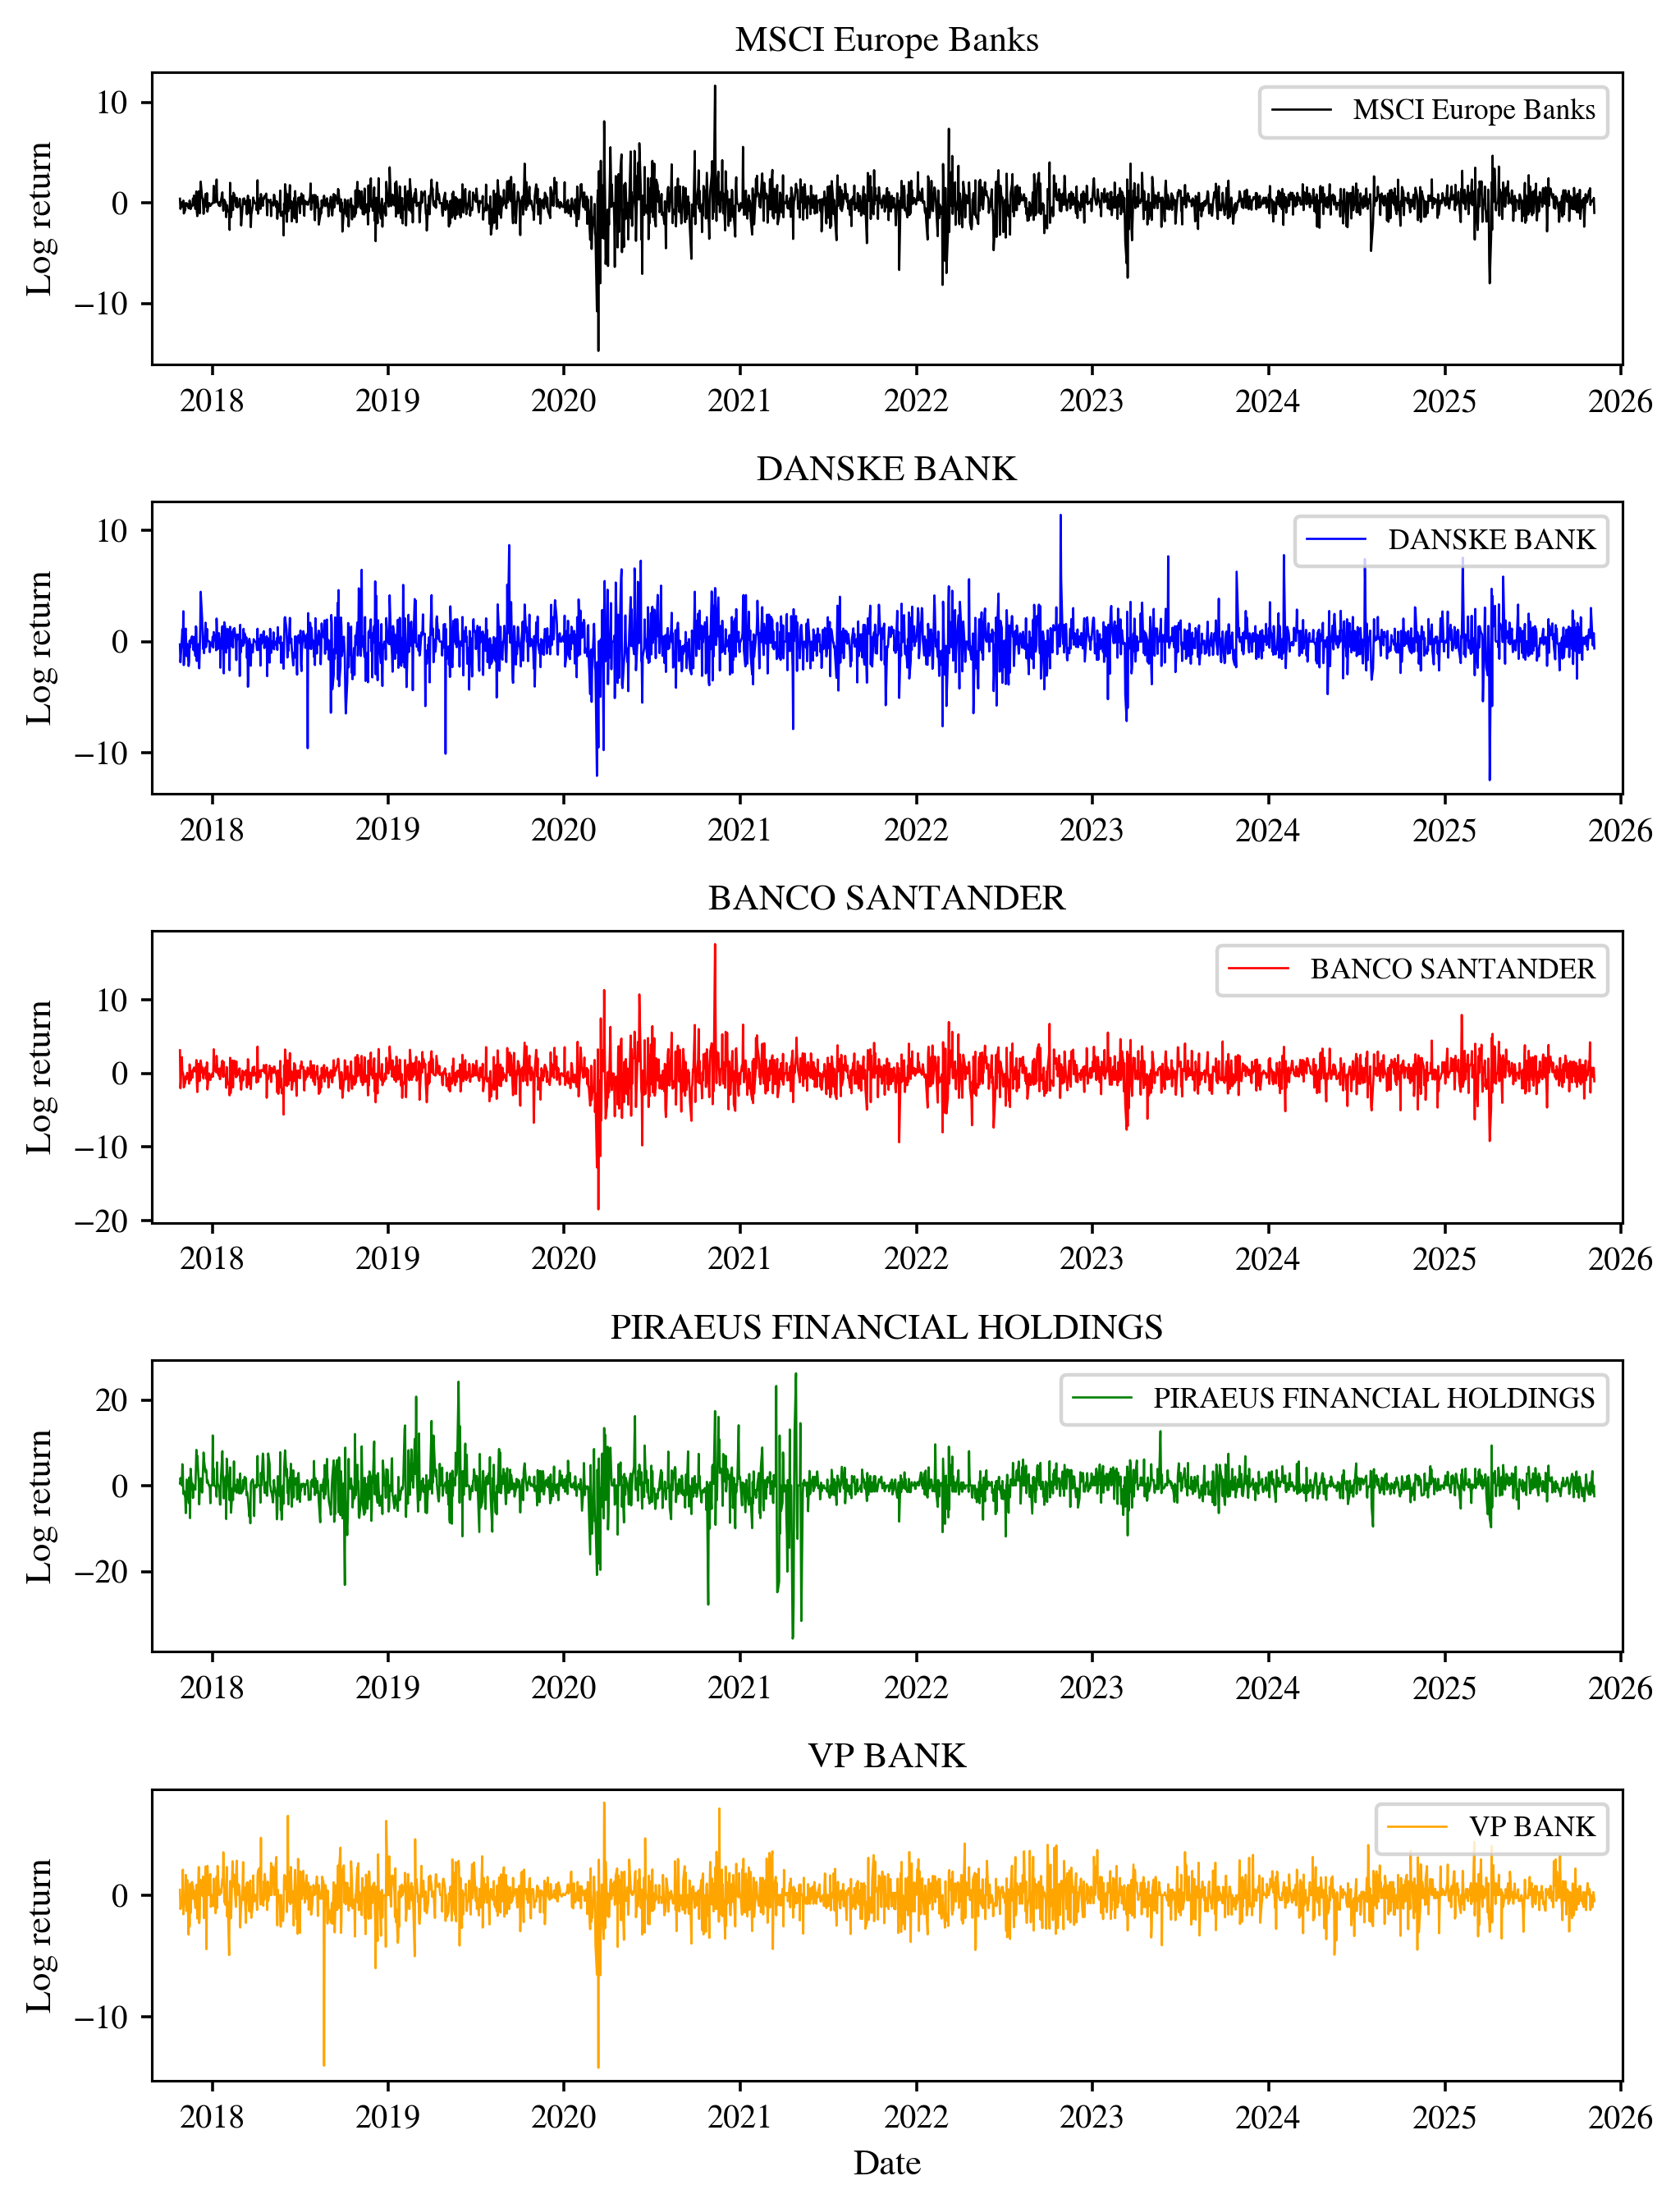

In [149]:
# Plot log returns for MSCI + selected banks
R = returns_by_run.get(PLOT_RUN, next(iter(returns_by_run.values())))

cols = [0, 8, 13, 19, 22]
cols = [i for i in cols if i < R.shape[1]]
selected_returns = R.iloc[:, cols] if cols else R.iloc[:, :min(5, R.shape[1])]

fig, axes = plt.subplots(nrows=selected_returns.shape[1], ncols=1, figsize=(6.5, 8.5), sharex=False)
axes = np.atleast_1d(axes)
colors = ['black', 'blue', 'red', 'green', 'orange'][:selected_returns.shape[1]]

for ax, col, color in zip(axes, selected_returns.columns, colors):
    ax.plot(selected_returns.index, selected_returns[col], color=color, label=col)
    ax.set_title(col, pad=6)
    ax.set_ylabel("Log return")
    ax.grid(False)
    ax.legend(loc="upper right", frameon=True, fontsize=8)

axes[-1].set_xlabel("Date")
fig.tight_layout()
plt.show()

### GPR index

In [150]:
# GPR LOAD DAILY and MA30 + SWITCH
# =========================
GPR_FILE = "./GPR_index_data.xlsx"  

# uncomment ONE: "DAILY" / "MA30"
USE_GPR_SERIES = "MA30"
# USE_GPR_SERIES = "DAILY"  

def load_gpr(GPR_FILE: str, series_choice: str = "DAILY") -> pd.DataFrame:
    """
    Returns a DataFrame with a daily DateTimeIndex and one column: 'GPR'.
    series_choice: 'DAILY' (official), 'MA30' (official)
    """
    gpr = pd.read_excel(GPR_FILE, engine="openpyxl")

    # Parse DATE robustly (your new file should already be parseable without custom format)
    gpr["DATE"] = pd.to_datetime(gpr["DATE"], errors="coerce")
    gpr = gpr.dropna(subset=["DATE"]).sort_values("DATE").set_index("DATE")

    # Map column names in the combined file
    col_map = {
        "DAILY": "GPR DAILY",
        "MA30": "GPR MA30",
    }

    if series_choice not in col_map:
        raise ValueError(f"Unknown series_choice={series_choice}. Choose from {list(col_map.keys())}")

    gpr = gpr[[col_map[series_choice]]].rename(columns={col_map[series_choice]: "GPR"})

    # Safety: treat zeros as missing for DAILY (sometimes missing coded as 0 in indices)
    # (MA30 and synth likely won't be 0; keep rule simple and harmless)
    gpr.loc[gpr["GPR"] == 0, "GPR"] = pd.NA

    # Ensure daily frequency (no harm if already daily)
    # Use asfreq to avoid creating synthetic values; fill strategy decided later.
    gpr = gpr.asfreq("D")

    # For DAILY/MA30, we generally do NOT want interpolation.
    # For synth series, it's already interpolated; still safe to keep as-is.
    # If there are gaps in the official daily, forward-fill is defensible for alignment to trading days
    # (it effectively creates a step function over non-reported days).
    gpr["GPR"] = gpr["GPR"].ffill()

    return gpr


gpr_data = load_gpr(GPR_FILE, USE_GPR_SERIES)


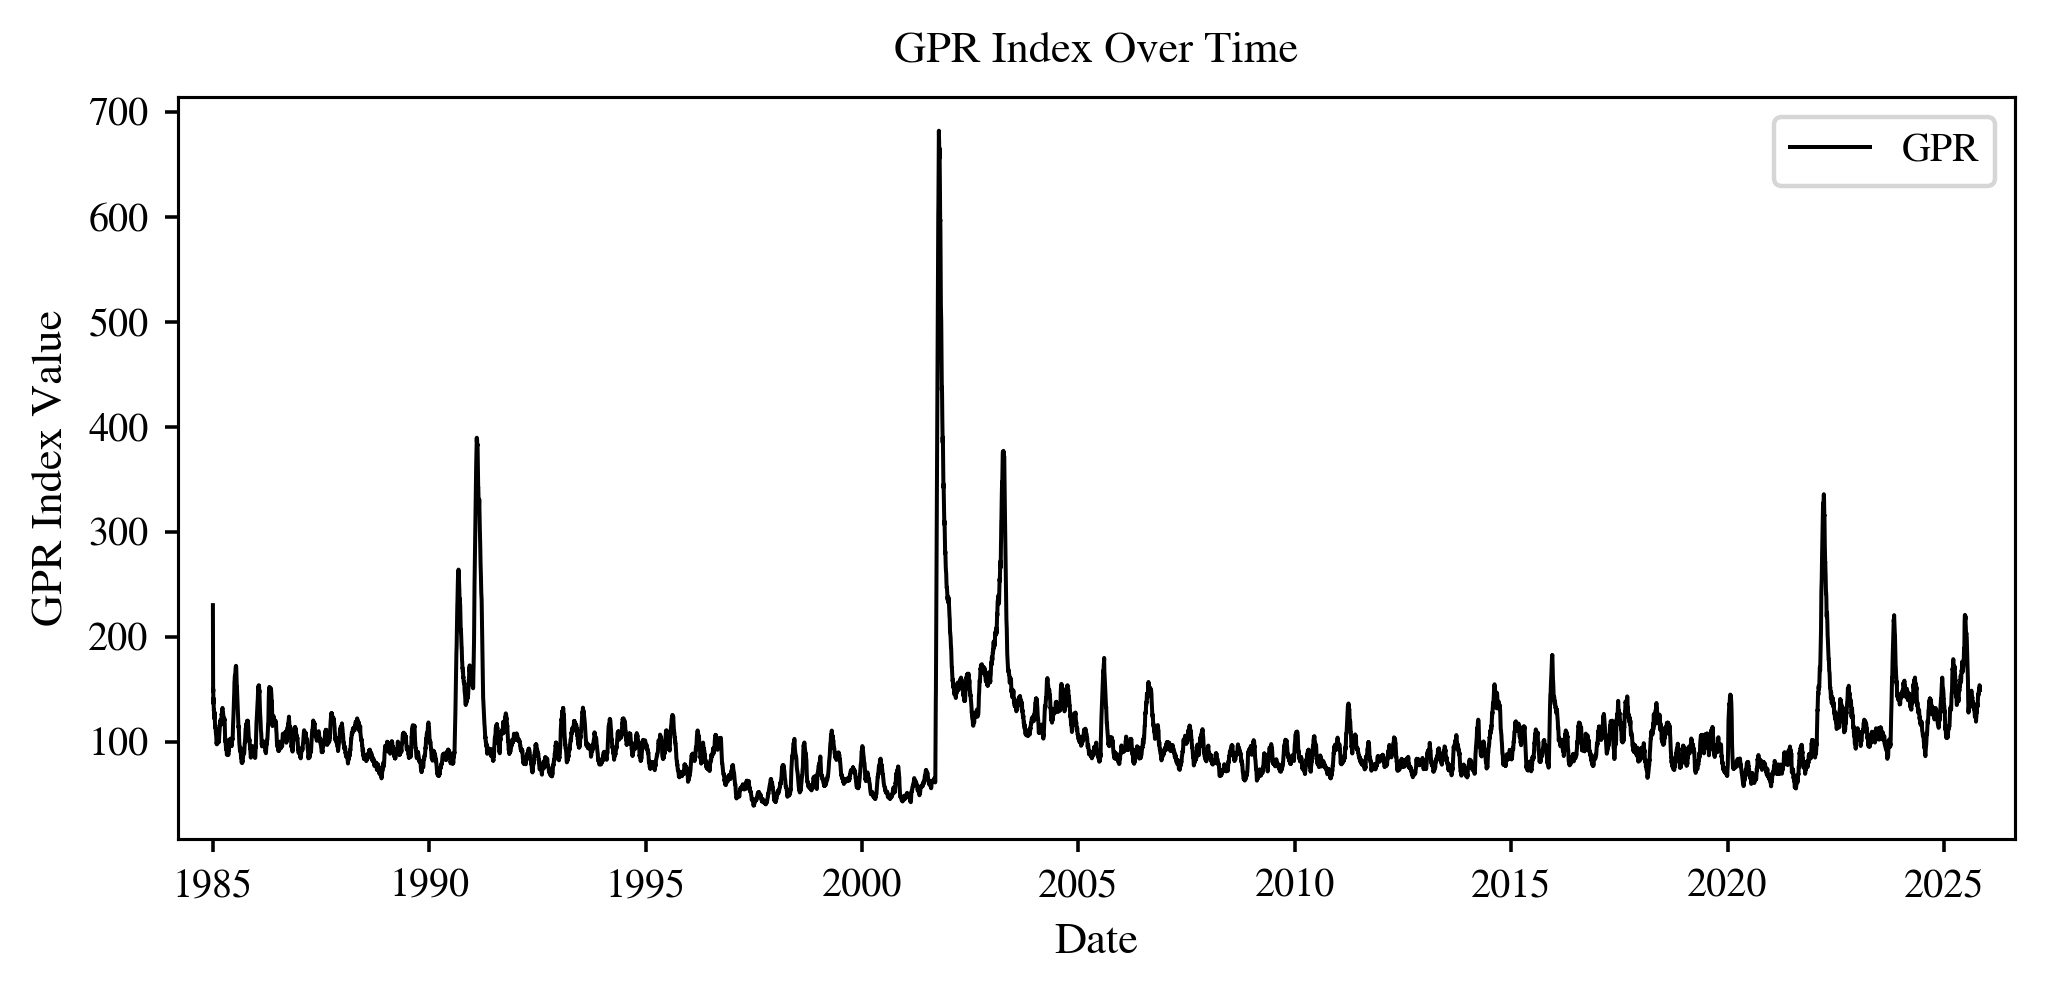

In [151]:
# Plot the GPR index over time
fig, ax = plt.subplots(figsize=FIG_FULL)

ax.plot(gpr_data.index, gpr_data.iloc[:, 0], color="black", label="GPR", linewidth=0.9)

ax.set_title("GPR Index Over Time", pad=8)
ax.set_xlabel("Date")
ax.set_ylabel("GPR Index Value")
ax.legend(loc="best")

ax.margins(x=0.02)

fig.tight_layout()
fig.savefig(FIG_DIR / "GPR_over_time.pdf", bbox_inches='tight')
plt.show()

In [152]:
# Helper to plot a zoomed GPR panel with event markers (exact dates, readable labels)
def plot_gpr_zoom(gpr_data, start, end, title, events):
    fig, ax = plt.subplots(figsize=FIG_FULL)

    gpr_win = gpr_data.loc[start:end].copy()
    series = gpr_win.iloc[:, 0].dropna()

    ax.plot(
        series.index,
        series.values,
        color="black",
        label="GPR (MA30)",
        linewidth=0.9
    )

    ax.set_title(title, pad=6)
    ax.set_xlabel("Date")
    ax.set_ylabel("GPR (MA30)")

    xmin, xmax = series.index.min(), series.index.max()

    for i, (label, date_str) in enumerate(events):
        dt = pd.Timestamp(date_str)
        if not (xmin <= dt <= xmax):
            continue

        # Find the highest GPR peak within 30 days around the event date
        window_start = dt - pd.Timedelta(days=30)
        window_end = dt + pd.Timedelta(days=30)
        window_data = series.loc[(series.index >= window_start) & (series.index <= window_end)]
        if window_data.empty:
            continue
        peak_date = window_data.idxmax()
        peak_value = window_data.max()

        ax.axvline(
            peak_date,
            color="black",
            linestyle=":",
            linewidth=0.7
        )

        # Stagger labels vertically to reduce overlap
        y_pos = 0.98 if i % 2 == 0 else 0.90

        ax.text(
            peak_date,
            y_pos,
            label,
            transform=ax.get_xaxis_transform(),
            rotation=90,
            va="top",
            ha="right",
            fontsize=8,
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.6,
                pad=0.6
            )
        )

    ax.legend(loc="lower left", frameon=True)
    ax.grid(False)
    ax.margins(x=0.02)

    fig.tight_layout()
    plt.show()

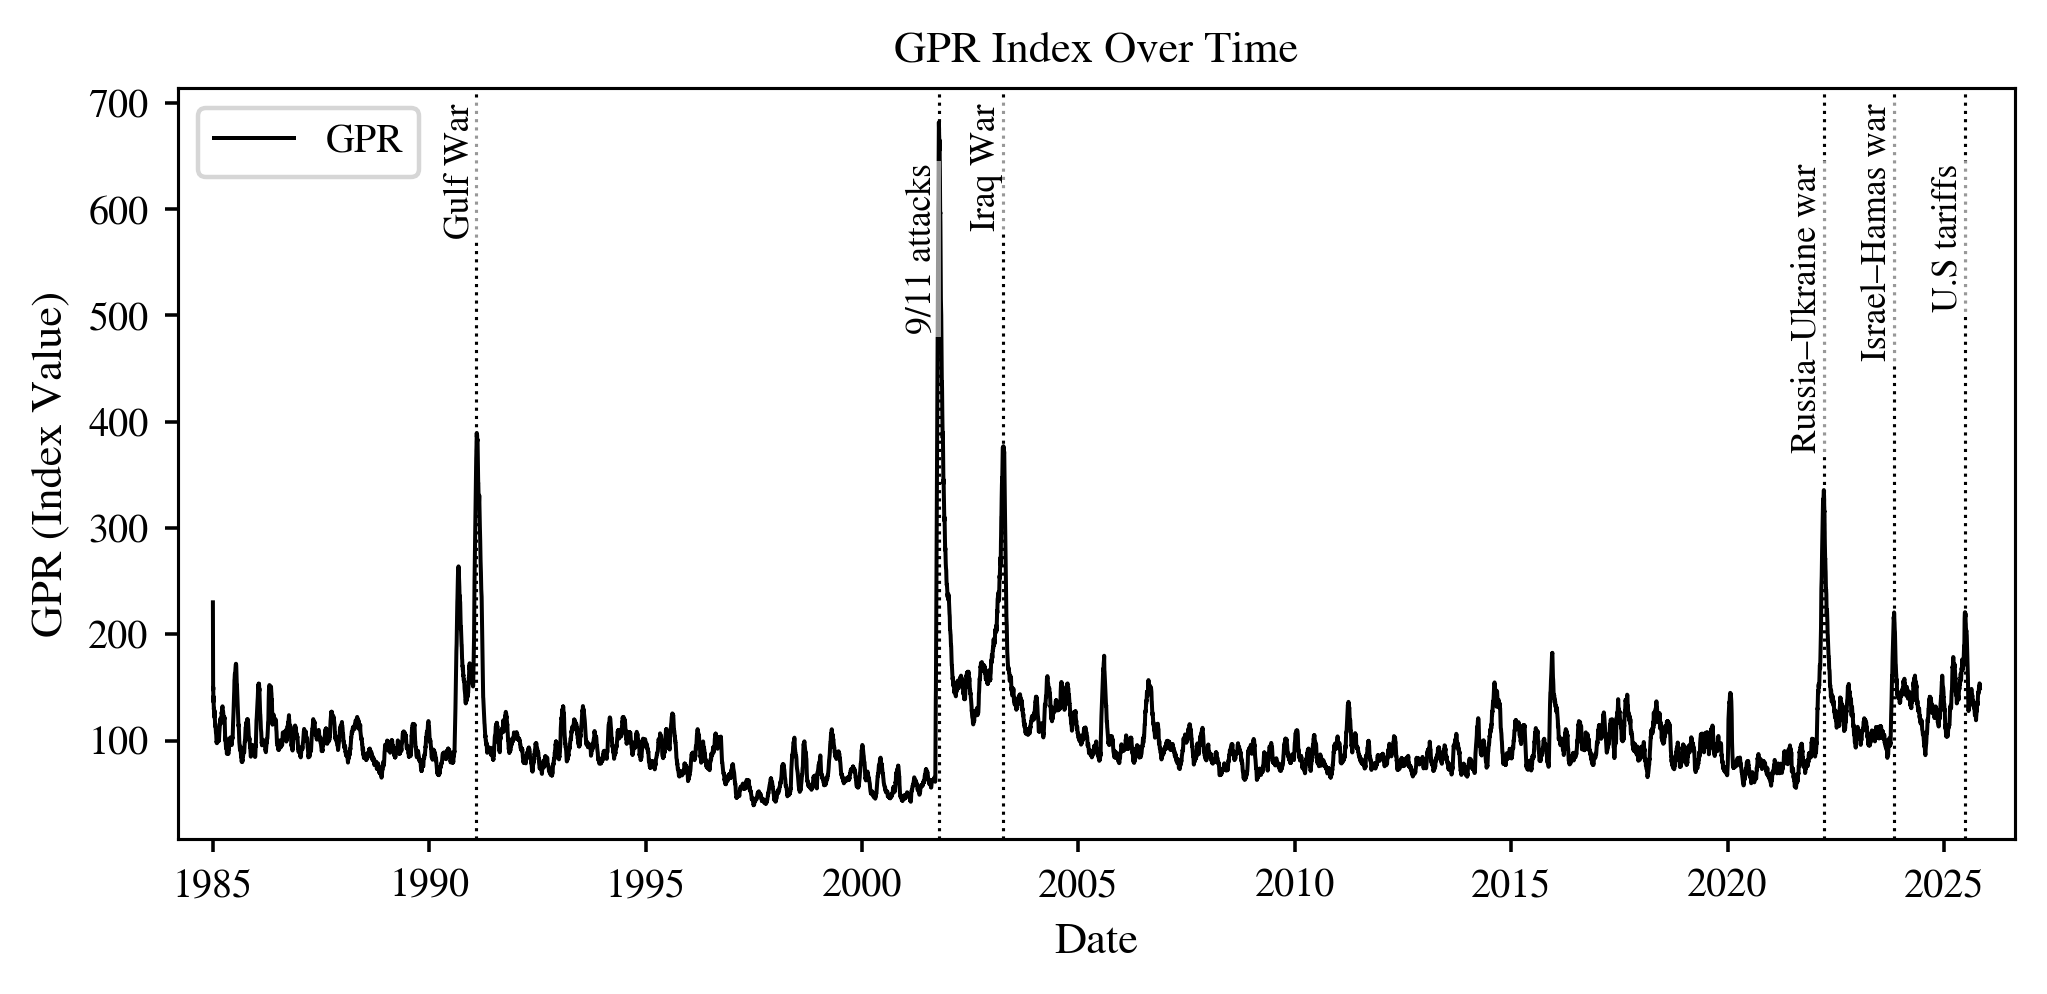

In [153]:
# 1985 - 2025
fig, ax = plt.subplots(figsize=FIG_FULL)

ax.plot(
    gpr_data.index,
    gpr_data.iloc[:, 0],
    color="black",
    label="GPR",
    linewidth=0.9
)

ax.set_title("GPR Index Over Time", pad=6)
ax.set_xlabel("Date")
ax.set_ylabel("GPR (Index Value)")

# Major geopolitical events (full-sample, only salient GPR-relevant shocks)
events = [
    ("Gulf War", "1991-01-02"),
    ("9/11 attacks", "2001-09-11"),
    ("Iraq War", "2003-03-20"),
    ("Russia–Ukraine war", "2022-02-24"),
    ("Israel–Hamas war", "2023-10-07"),
    ("U.S tariffs", "2025-07-10"),
]

series = gpr_data.iloc[:, 0].dropna()

xmin, xmax = gpr_data.index.min(), gpr_data.index.max()

for i, (label, date_str) in enumerate(events):
    dt = pd.Timestamp(date_str)
    if not (xmin <= dt <= xmax):
        continue

    # Find the highest GPR peak within 30 days around the event date
    window_start = dt - pd.Timedelta(days=30)
    window_end = dt + pd.Timedelta(days=30)
    window_data = series.loc[(series.index >= window_start) & (series.index <= window_end)]
    if window_data.empty:
        continue
    peak_date = window_data.idxmax()
    peak_value = window_data.max()

    ax.axvline(
        peak_date,
        color="black",
        linestyle=":",
        linewidth=0.7
    )

    # Stagger labels vertically to reduce overlap
    y_pos = 0.98 if i % 2 == 0 else 0.90

    ax.text(
        peak_date,
        y_pos,
        label,
        transform=ax.get_xaxis_transform(),
        rotation=90,
        va="top",
        ha="right",
        fontsize=8,
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.6,
            pad=0.6
        )
    )

ax.legend(loc="best", frameon=True)
ax.grid(False)
ax.margins(x=0.02)

fig.tight_layout()
# plt.show()

# Save the figure
# fig.savefig(FIG_DIR / "GPR_full_with_events.pdf", bbox_inches='tight')


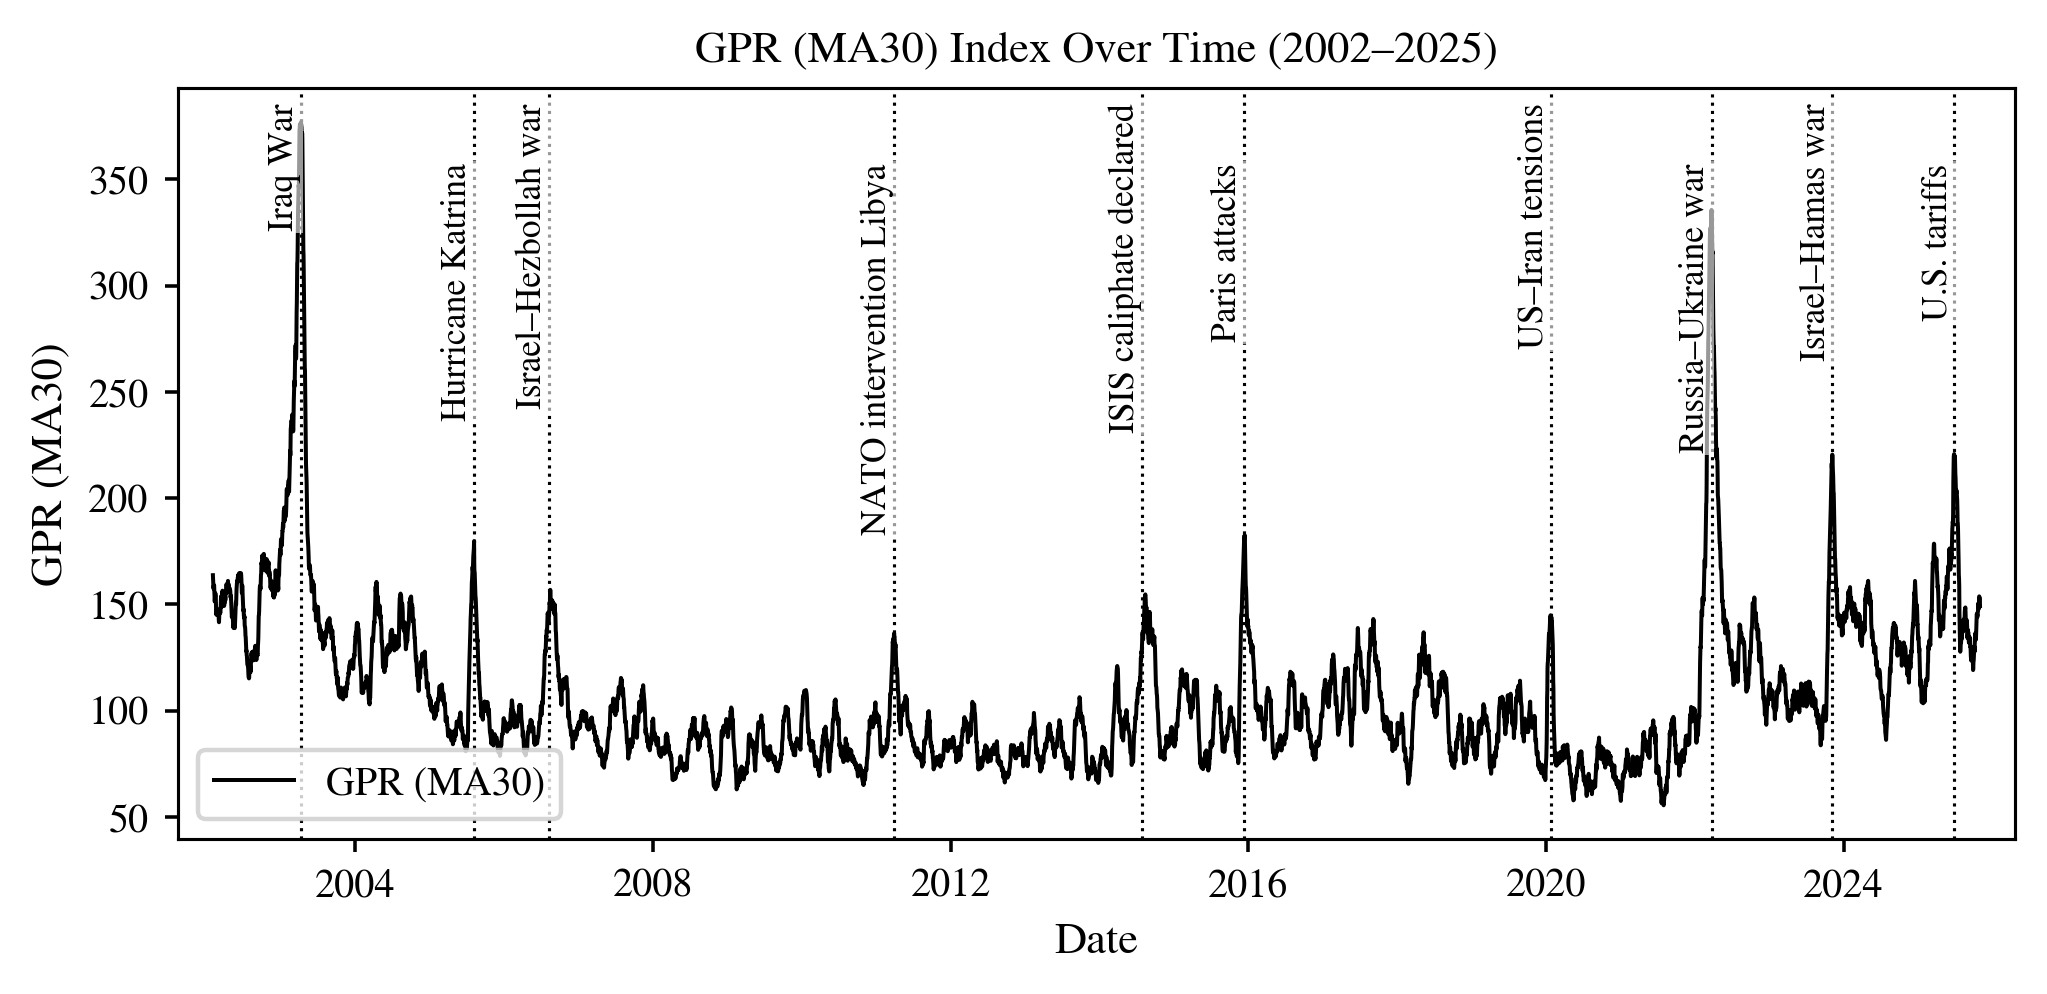

In [154]:
# 2002-2025
events_2002_2025 = [
    ("Iraq War", "2003-03-20"),
    ("Hurricane Katrina", "2005-08-29"),
    ("Israel–Hezbollah war", "2006-07-12"),
    ("NATO intervention Libya", "2011-03-30"),  
    ("ISIS caliphate declared", "2014-06-29"),
    ("Paris attacks", "2015-11-13"),
    ("US–Iran tensions", "2020-01-03"),
    ("Russia–Ukraine war", "2022-02-24"),
    ("Israel–Hamas war", "2023-10-07"),
    ("U.S. tariffs", "2025-07-10"),
]

plot_gpr_zoom(
    gpr_data=gpr_data,
    start="2002-02-01",
    end="2025-11-06",
    title="GPR (MA30) Index Over Time (2002–2025)",
    events=events_2002_2025
)

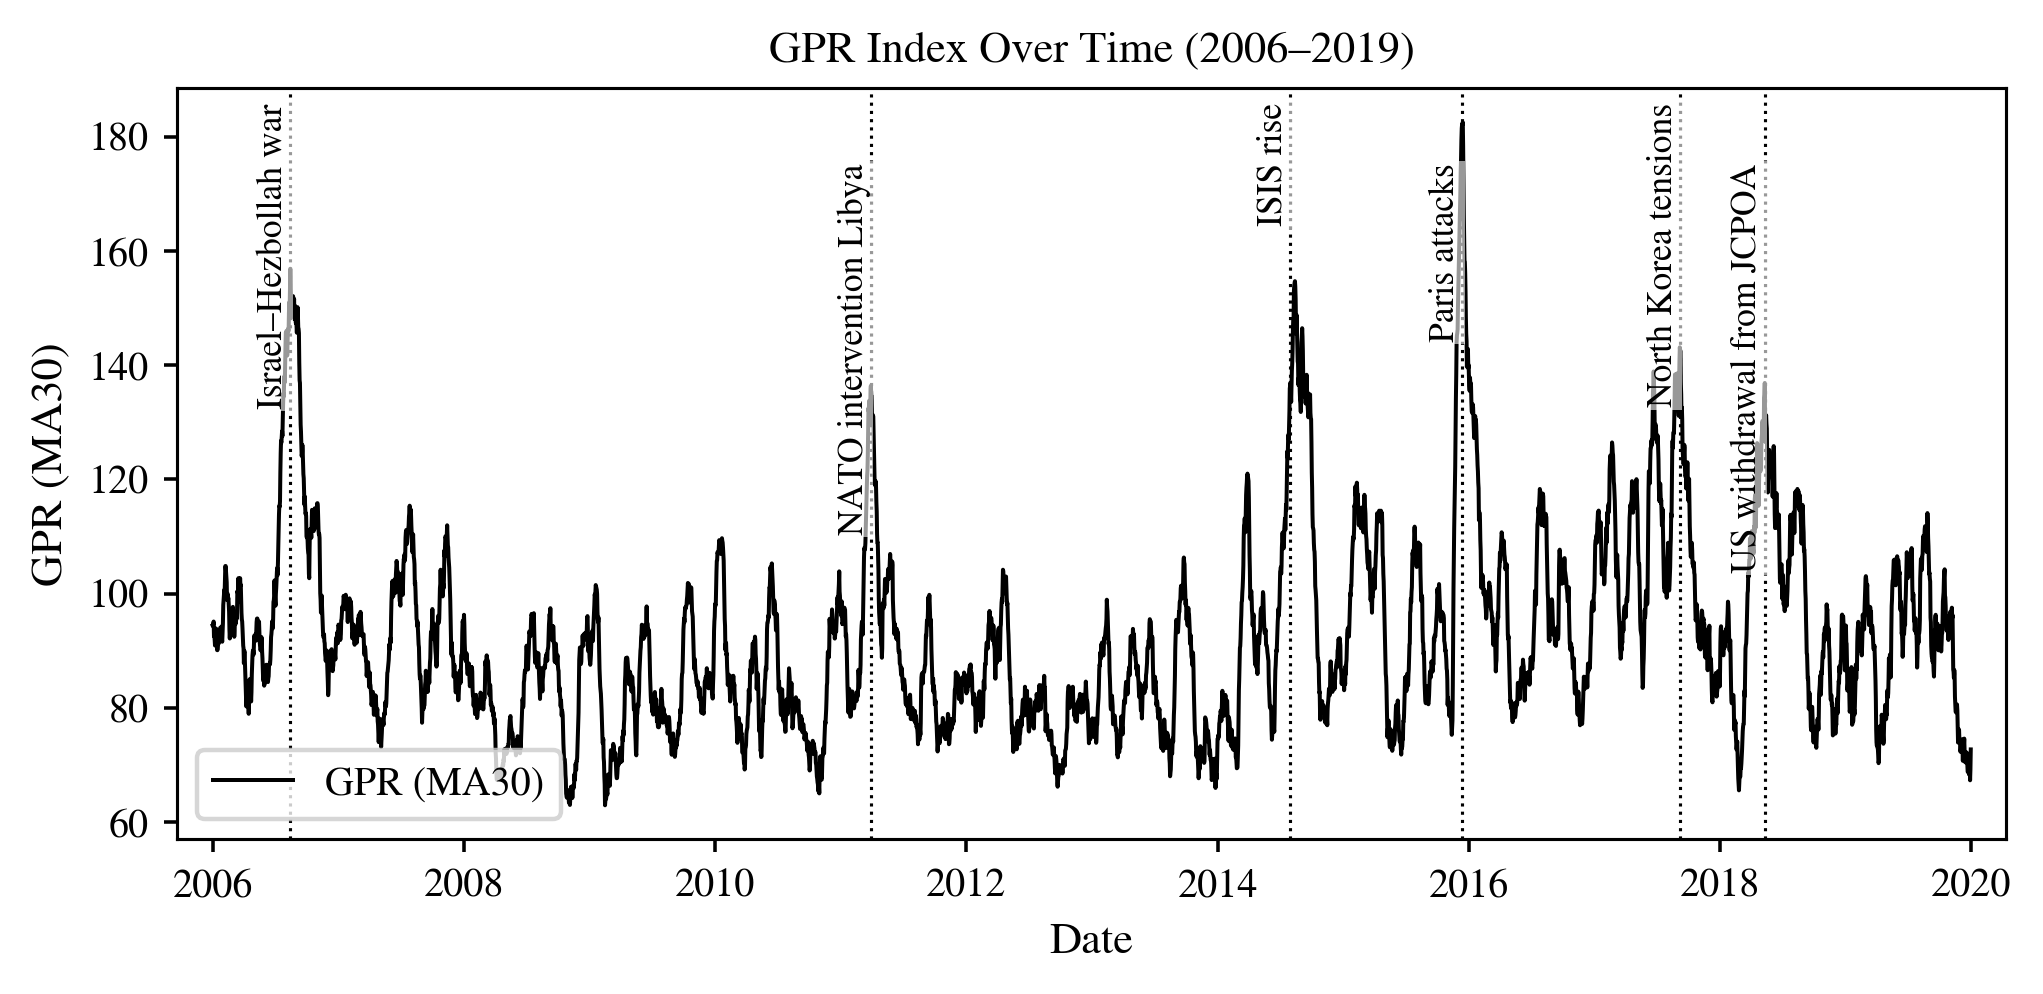

In [155]:
# 2006–2019
# =========================
events_2006_2019 = [
    ("Israel–Hezbollah war", "2006-07-30"),
    ("NATO intervention Libya", "2011-03-30"),
    ("ISIS rise", "2014-06-30"),
    ("Paris attacks", "2015-11-13"),
    ("North Korea tensions", "2017-08-08"),
    ("US withdrawal from JCPOA", "2018-05-01"),
]

plot_gpr_zoom(
    gpr_data=gpr_data,
    start="2006-01-01",
    end="2019-12-31",
    title="GPR Index Over Time (2006–2019)",
    events=events_2006_2019
)

# Save the figure
fig.savefig(FIG_DIR / "GPR_2006_2019_with_events.pdf")

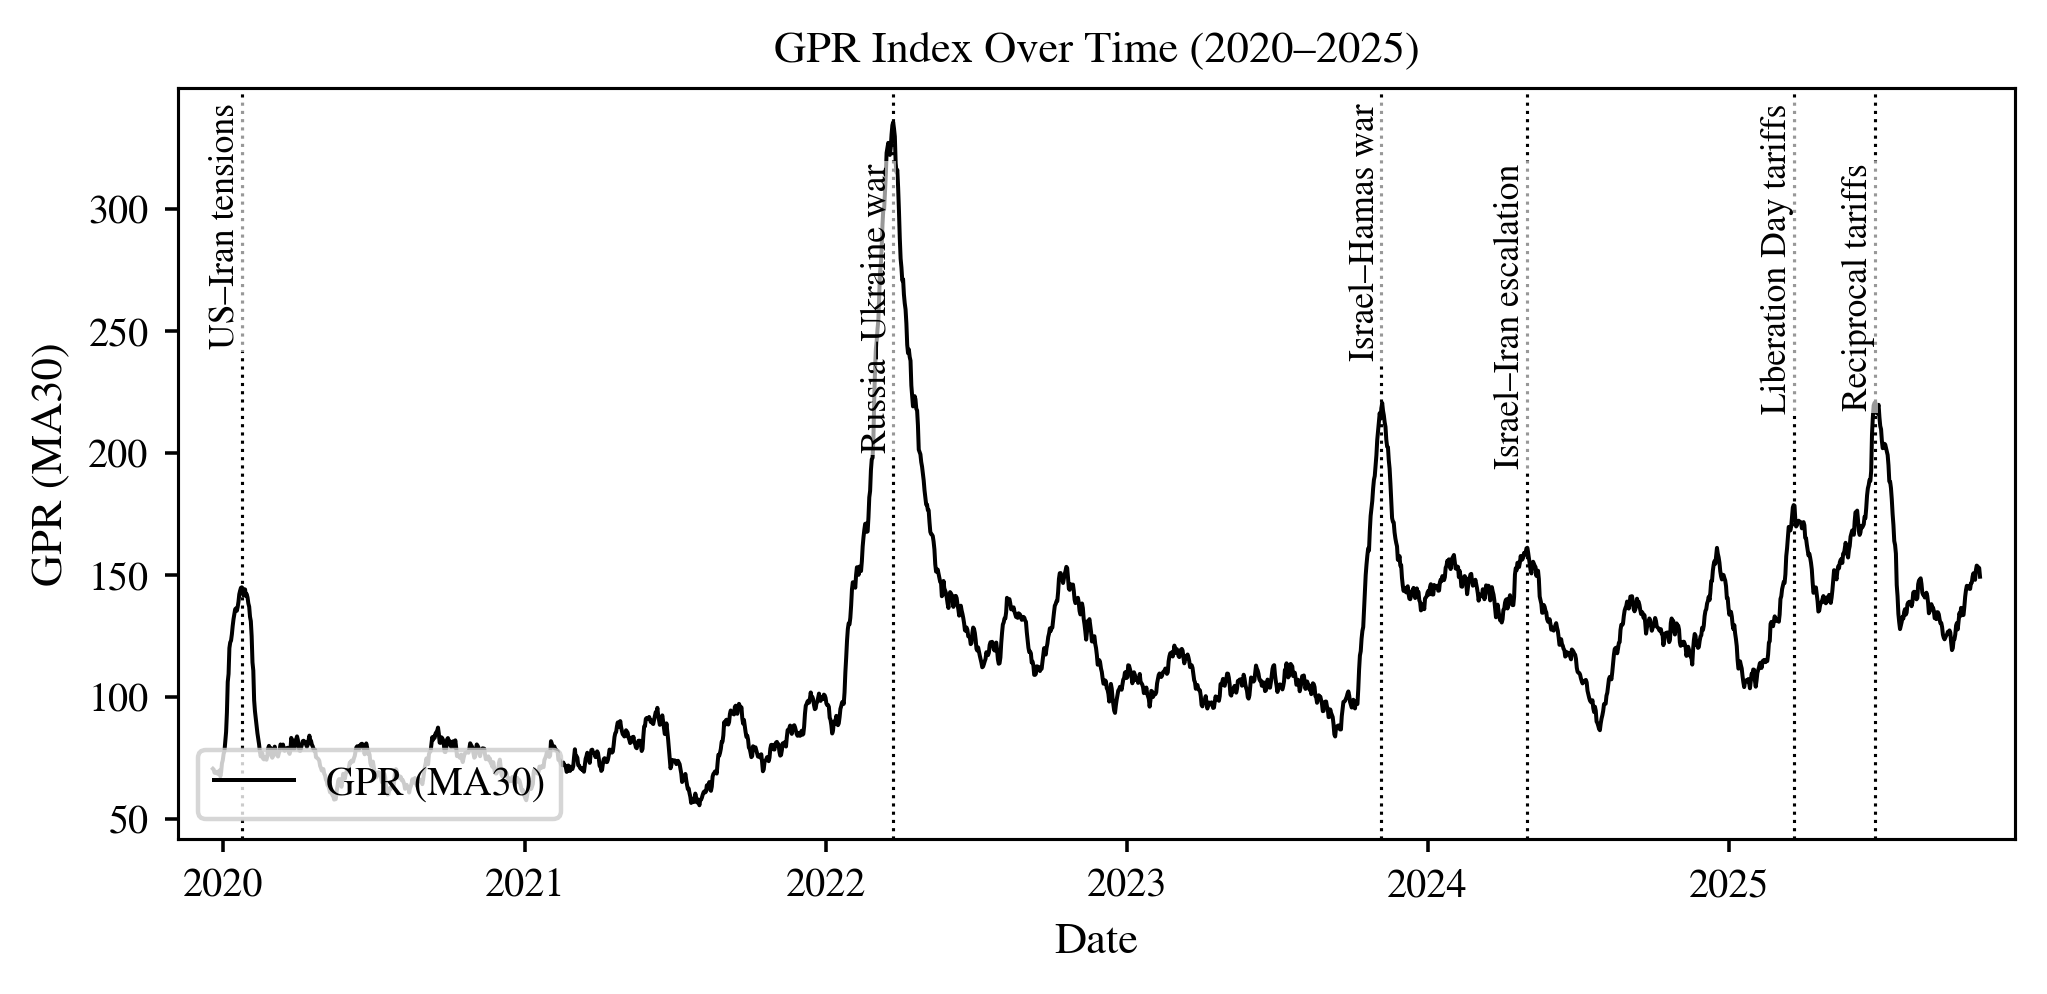

In [156]:
# 2020–2025
# =========================
events_2020_2025 = [
    ("US–Iran tensions", "2020-01-03"),
    ("Russia–Ukraine war", "2022-02-24"),
    ("Israel–Hamas war", "2023-10-07"),
    ("Israel–Iran escalation", "2024-04-13"),
    ("Liberation Day tariffs", "2025-04-02"),
    ("Reciprocal tariffs", "2025-07-10"),
]


plot_gpr_zoom(
    gpr_data=gpr_data,
    start="2019-12-20",
    end="2025-12-31",
    title="GPR Index Over Time (2020–2025)",
    events=events_2020_2025
)

# Save the figure
fig.savefig(FIG_DIR / "GPR_2020_2025_with_events.pdf")

### Univariate GARCH(1,1) model fitting

Using R rugarch package

In [157]:
# Fit GARCH(1,1) model using rugarch for returns and store results
rugarch_models_by_run, cond_var_by_run = {}, {}

spec = rugarch.ugarchspec(
    variance_model=ro.ListVector({'model': 'sGARCH', 'garchOrder': ro.IntVector([1, 1]), 'variance.targeting': False}),
    mean_model=ro.ListVector({'armaOrder': ro.IntVector([0, 0]), 'include.mean': False}),
    distribution_model='norm'
)

for run_name, R in returns_by_run.items():
    models = {}
    cond_var = pd.DataFrame(index=R.index, columns=R.columns, dtype=float)

    for asset in R.columns:
        s = R[asset].dropna()
        if len(s) < 50:
            continue
        with localconverter(ro.default_converter + pandas2ri.converter):
            returns_r = ro.conversion.py2rpy(s)
        fit = rugarch.ugarchfit(spec, returns_r, solver='hybrid')
        models[asset] = fit
        cond_var.loc[s.index, asset] = np.asarray(rugarch.sigma(fit)).ravel() ** 2

    rugarch_models_by_run[run_name] = models
    cond_var_by_run[run_name] = cond_var

print("✅ GARCH done for:", list(cond_var_by_run.keys()))


✅ GARCH done for: ['GSIB', 'OSII_A', 'OSII_B', 'OSII_C']


Compute the diagonal matrix of conditional standard deviations $D_t$ (just for checking purposes, $H_t$ will be extracted directly later)

In [158]:
# # Calculate D matrices for the entire cond_var_r_df_gsibs dataframe
# # Ensure all columns in cond_var_r_df_gsibs are numeric
# cond_var_r_df_gsibs = cond_var_r_df_gsibs.apply(pd.to_numeric, errors='coerce')

# # Calculate D matrices
# gsibs_D_matrices = {date: np.diag(np.sqrt(cond_var_r_df_gsibs.loc[date])) for date in cond_var_r_df_gsibs.index}

# # Flatten D matrices into a DataFrame for CSV export
# gsibs_D_df = pd.DataFrame({
#     'Date': cond_var_r_df_gsibs.index,
#     **{f'D_{i+1}{i+1}': [gsibs_D_matrices[date][i, i] for date in cond_var_r_df_gsibs.index] for i in range(cond_var_r_df_gsibs.shape[1])}
# }).set_index('Date')

# # Save the D matrices to a CSV file
# print("D Matrices DataFrame (first 5 rows):\n", gsibs_D_df.head())


### DCC estimation

To compute the time-varying conditional correlation and covariance matrix we use the DCC approach introduced by Engle (2002)

In [159]:
# DCC estimation (LOAD CACHED CSVs OR RUN & SAVE)
# ============================================

# Choose where your cached files live
data_dir = Path("./Outputs presentation/Dataframes")
data_dir.mkdir(parents=True, exist_ok=True)

# ---------- 1) Try loading cached results ----------
R_df_by_run = {}
H_df_by_run = {}

for f in data_dir.glob("DCC_R_*.csv"):
    run_name = f.stem.replace("DCC_R_", "")
    R_df_by_run[run_name] = pd.read_csv(f, index_col=0, parse_dates=True)

for f in data_dir.glob("DCC_H_*.csv"):
    run_name = f.stem.replace("DCC_H_", "")
    H_df_by_run[run_name] = pd.read_csv(f, index_col=0, parse_dates=True)

# If we loaded something, we skip the DCC estimation
if len(R_df_by_run) > 0 and len(H_df_by_run) > 0:
    print(f"✅ Loaded cached DCC results from {data_dir.resolve()}")
    print(f"   Runs loaded: {len(R_df_by_run)}")
    print("   Example runs:", list(R_df_by_run.keys())[:5])

    # Optional: create empty placeholders to keep later code happy
    dcc_fit_by_run, Rt_np_by_run, Ht_np_by_run = {}, {}, {}

else:
    print("⏳ No cached DCC CSVs found. Running DCC estimation (slow)...")

    # ---------- 2) Run your original DCC estimation loop ----------
    dcc_fit_by_run, Rt_np_by_run, Ht_np_by_run = {}, {}, {}
    R_df_by_run, H_df_by_run = {}, {}

    def _ok_for_garch(s, min_obs=500, zero_thr=0.8, min_std=1e-6):
        s = s.dropna()
        if len(s) < min_obs:
            return False
        if (s.abs() < 1e-12).mean() > zero_thr:
            return False
        if s.std() < min_std:
            return False
        return True

    for run_name, R in returns_by_run.items():
        R_panel = R.dropna(axis=0, how="any")
        if R_panel.shape[0] < 500 or R_panel.shape[1] < 2:
            print(f"Skipping {run_name}: panel too small ({R_panel.shape})")
            continue

        # Filter columns that are likely to break univariate GARCH
        keep = [c for c in R_panel.columns if _ok_for_garch(R_panel[c])]
        R_panel = R_panel[keep]
        if R_panel.shape[1] < 2:
            print(f"Skipping {run_name}: <2 series after filtering")
            continue

        with localconverter(ro.default_converter + pandas2ri.converter):
            R_r = ro.conversion.py2rpy(R_panel)

        # Make univariate fits more stable
        uspec = rugarch.multispec([
            rugarch.ugarchspec(
                variance_model=ro.ListVector({'model': 'sGARCH', 'garchOrder': ro.IntVector([1, 1])}),
                mean_model=ro.ListVector({'armaOrder': ro.IntVector([0, 0]), 'include.mean': True}),
                distribution_model='std'
            ) for _ in range(R_panel.shape[1])
        ])

        dcc_spec = rmgarch.dccspec(uspec=uspec, dccOrder=ro.IntVector([1, 1]), distribution='mvt')
        fit = rmgarch.dccfit(dcc_spec, data=R_r)

        # Check what we got back
        fit_class = list(ro.r["class"](fit))
        if "DCCfit" not in fit_class:
            print(f"\n❌ {run_name}: DCC failed (returned {fit_class}). Univariate GARCH did not converge for some series.")
            continue

        Rt_array = rmgarch.rcor(fit)
        Ht_array = rmgarch.rcov(fit)

        with localconverter(default_converter + numpy2ri.converter):
            Rt_np = ro.conversion.rpy2py(Rt_array)
            Ht_np = ro.conversion.rpy2py(Ht_array)

        dates = R_panel.index
        n = Rt_np.shape[0]
        Rt_flat = Rt_np.reshape(n*n, Rt_np.shape[2]).T
        Ht_flat = Ht_np.reshape(n*n, Ht_np.shape[2]).T

        R_df = pd.DataFrame(
            Rt_flat,
            index=dates,
            columns=[f"R_{i+1}{j+1}" for i in range(n) for j in range(n)]
        )
        H_df = pd.DataFrame(
            Ht_flat,
            index=dates,
            columns=[f"H_{i+1}{j+1}" for i in range(n) for j in range(n)]
        )

        dcc_fit_by_run[run_name] = fit
        Rt_np_by_run[run_name], Ht_np_by_run[run_name] = Rt_np, Ht_np
        R_df_by_run[run_name], H_df_by_run[run_name] = R_df, H_df

        print(f"\n✅ {run_name}: DCC fit done. n={n}, T={len(dates)}")
        print("R preview:\n", R_df.iloc[:2, :6].to_string())
        print("H preview:\n", H_df.iloc[:2, :6].to_string())

    # ---------- 3) Save results to CSV so next time is instant ----------
    for run_name in R_df_by_run.keys():
        R_df_by_run[run_name].to_csv(data_dir / f"DCC_R_{run_name}.csv")
        H_df_by_run[run_name].to_csv(data_dir / f"DCC_H_{run_name}.csv")

    print(f"\n💾 Saved cached DCC results to: {data_dir.resolve()}")


✅ Loaded cached DCC results from C:\Users\Asus\Documents\Econometrie\Master\Thesis DNB\Outputs presentation\Dataframes
   Runs loaded: 4
   Example runs: ['GSIB', 'OSII_A', 'OSII_B', 'OSII_C']


### Time-varying Betas

The conditional beta of asset i with respect to the market at time t is defined as: $\beta_{i,t} = \frac{Cov_t(r_{i,t}, r_{m,t})}{Var_t(r_{m,t})} = \frac{h_{im,t}}{h_{m,t}}$ where $h_{im,t}$ is the (i, m)-th element of the conditional covariance matrix $H_t$.

In [160]:
# Dynamic beta from cached DCC H_t (LOAD CACHED CSVs OR COMPUTE & SAVE)
# ====================================================================

beta_dir = Path("./Outputs presentation/Dataframes")
beta_dir.mkdir(parents=True, exist_ok=True)

beta_by_run = {}

# ---------- 1) Try loading cached betas ----------
for f in beta_dir.glob("DCC_BETA_*.csv"):
    run_name = f.stem.replace("DCC_BETA_", "")
    beta_by_run[run_name] = pd.read_csv(f, index_col=0, parse_dates=True)

if len(beta_by_run) > 0:
    print(f"✅ Loaded cached beta results from {beta_dir.resolve()}")
    print("   Example runs:", list(beta_by_run.keys())[:5])

else:
    print("⏳ No cached beta CSVs found. Computing betas from H_df_by_run...")

    # same filter you used for DCC (so column ordering matches)
    def _ok_for_garch(s, min_obs=500, zero_thr=0.8, min_std=1e-6):
        s = s.dropna()
        if len(s) < min_obs:
            return False
        if (s.abs() < 1e-12).mean() > zero_thr:
            return False
        if s.std() < min_std:
            return False
        return True

    for run_name, H_df in H_df_by_run.items():
        # rebuild the exact column order used in DCC for this run (MSCI must be first)
        R = returns_by_run[run_name].dropna(axis=0, how="any")
        keep_cols = [c for c in R.columns if _ok_for_garch(R[c])]
        R = R[keep_cols]

        if R.shape[1] < 2:
            print(f"Skipping {run_name}: <2 series available after filtering")
            continue

        # infer N from H_df columns (H has N^2 entries)
        H_cols = [c for c in H_df.columns if c.startswith("H_")]
        N_cache = int(np.sqrt(len(H_cols)))

        if N_cache != R.shape[1]:
            print(f"⚠️ {run_name}: N mismatch (cache N={N_cache}, rebuilt N={R.shape[1]}). Using cache N.")
            # fall back to generic names
            col_names = [f"Asset_{i+1}" for i in range(N_cache)]
        else:
            col_names = list(R.columns)

        # market is series 1 (MSCI), so h_mm is H_11
        h_mm = H_df["H_11"].astype(float)

        # beta for each bank i=2..N: beta_i = H_i1 / H_11
        beta_df = pd.DataFrame(index=H_df.index, dtype=float)

        for i in range(2, N_cache + 1):
            bank_name = col_names[i - 1]          # i=2 -> col_names[1]
            beta_df[bank_name] = H_df[f"H_{i}1"].astype(float) / h_mm

        beta_by_run[run_name] = beta_df

        # Save each run
        beta_df.to_csv(beta_dir / f"DCC_BETA_{run_name}.csv")

        print(f"✅ {run_name}: beta computed & saved ({beta_df.shape})")
        print(beta_df.iloc[:2, :6].to_string())

    print(f"\n💾 Saved beta CSVs to: {beta_dir.resolve()}")

✅ Loaded cached beta results from C:\Users\Asus\Documents\Econometrie\Master\Thesis DNB\Outputs presentation\Dataframes
   Example runs: ['GSIB', 'OSII_A', 'OSII_B', 'OSII_C']


Plot the dynamic betas

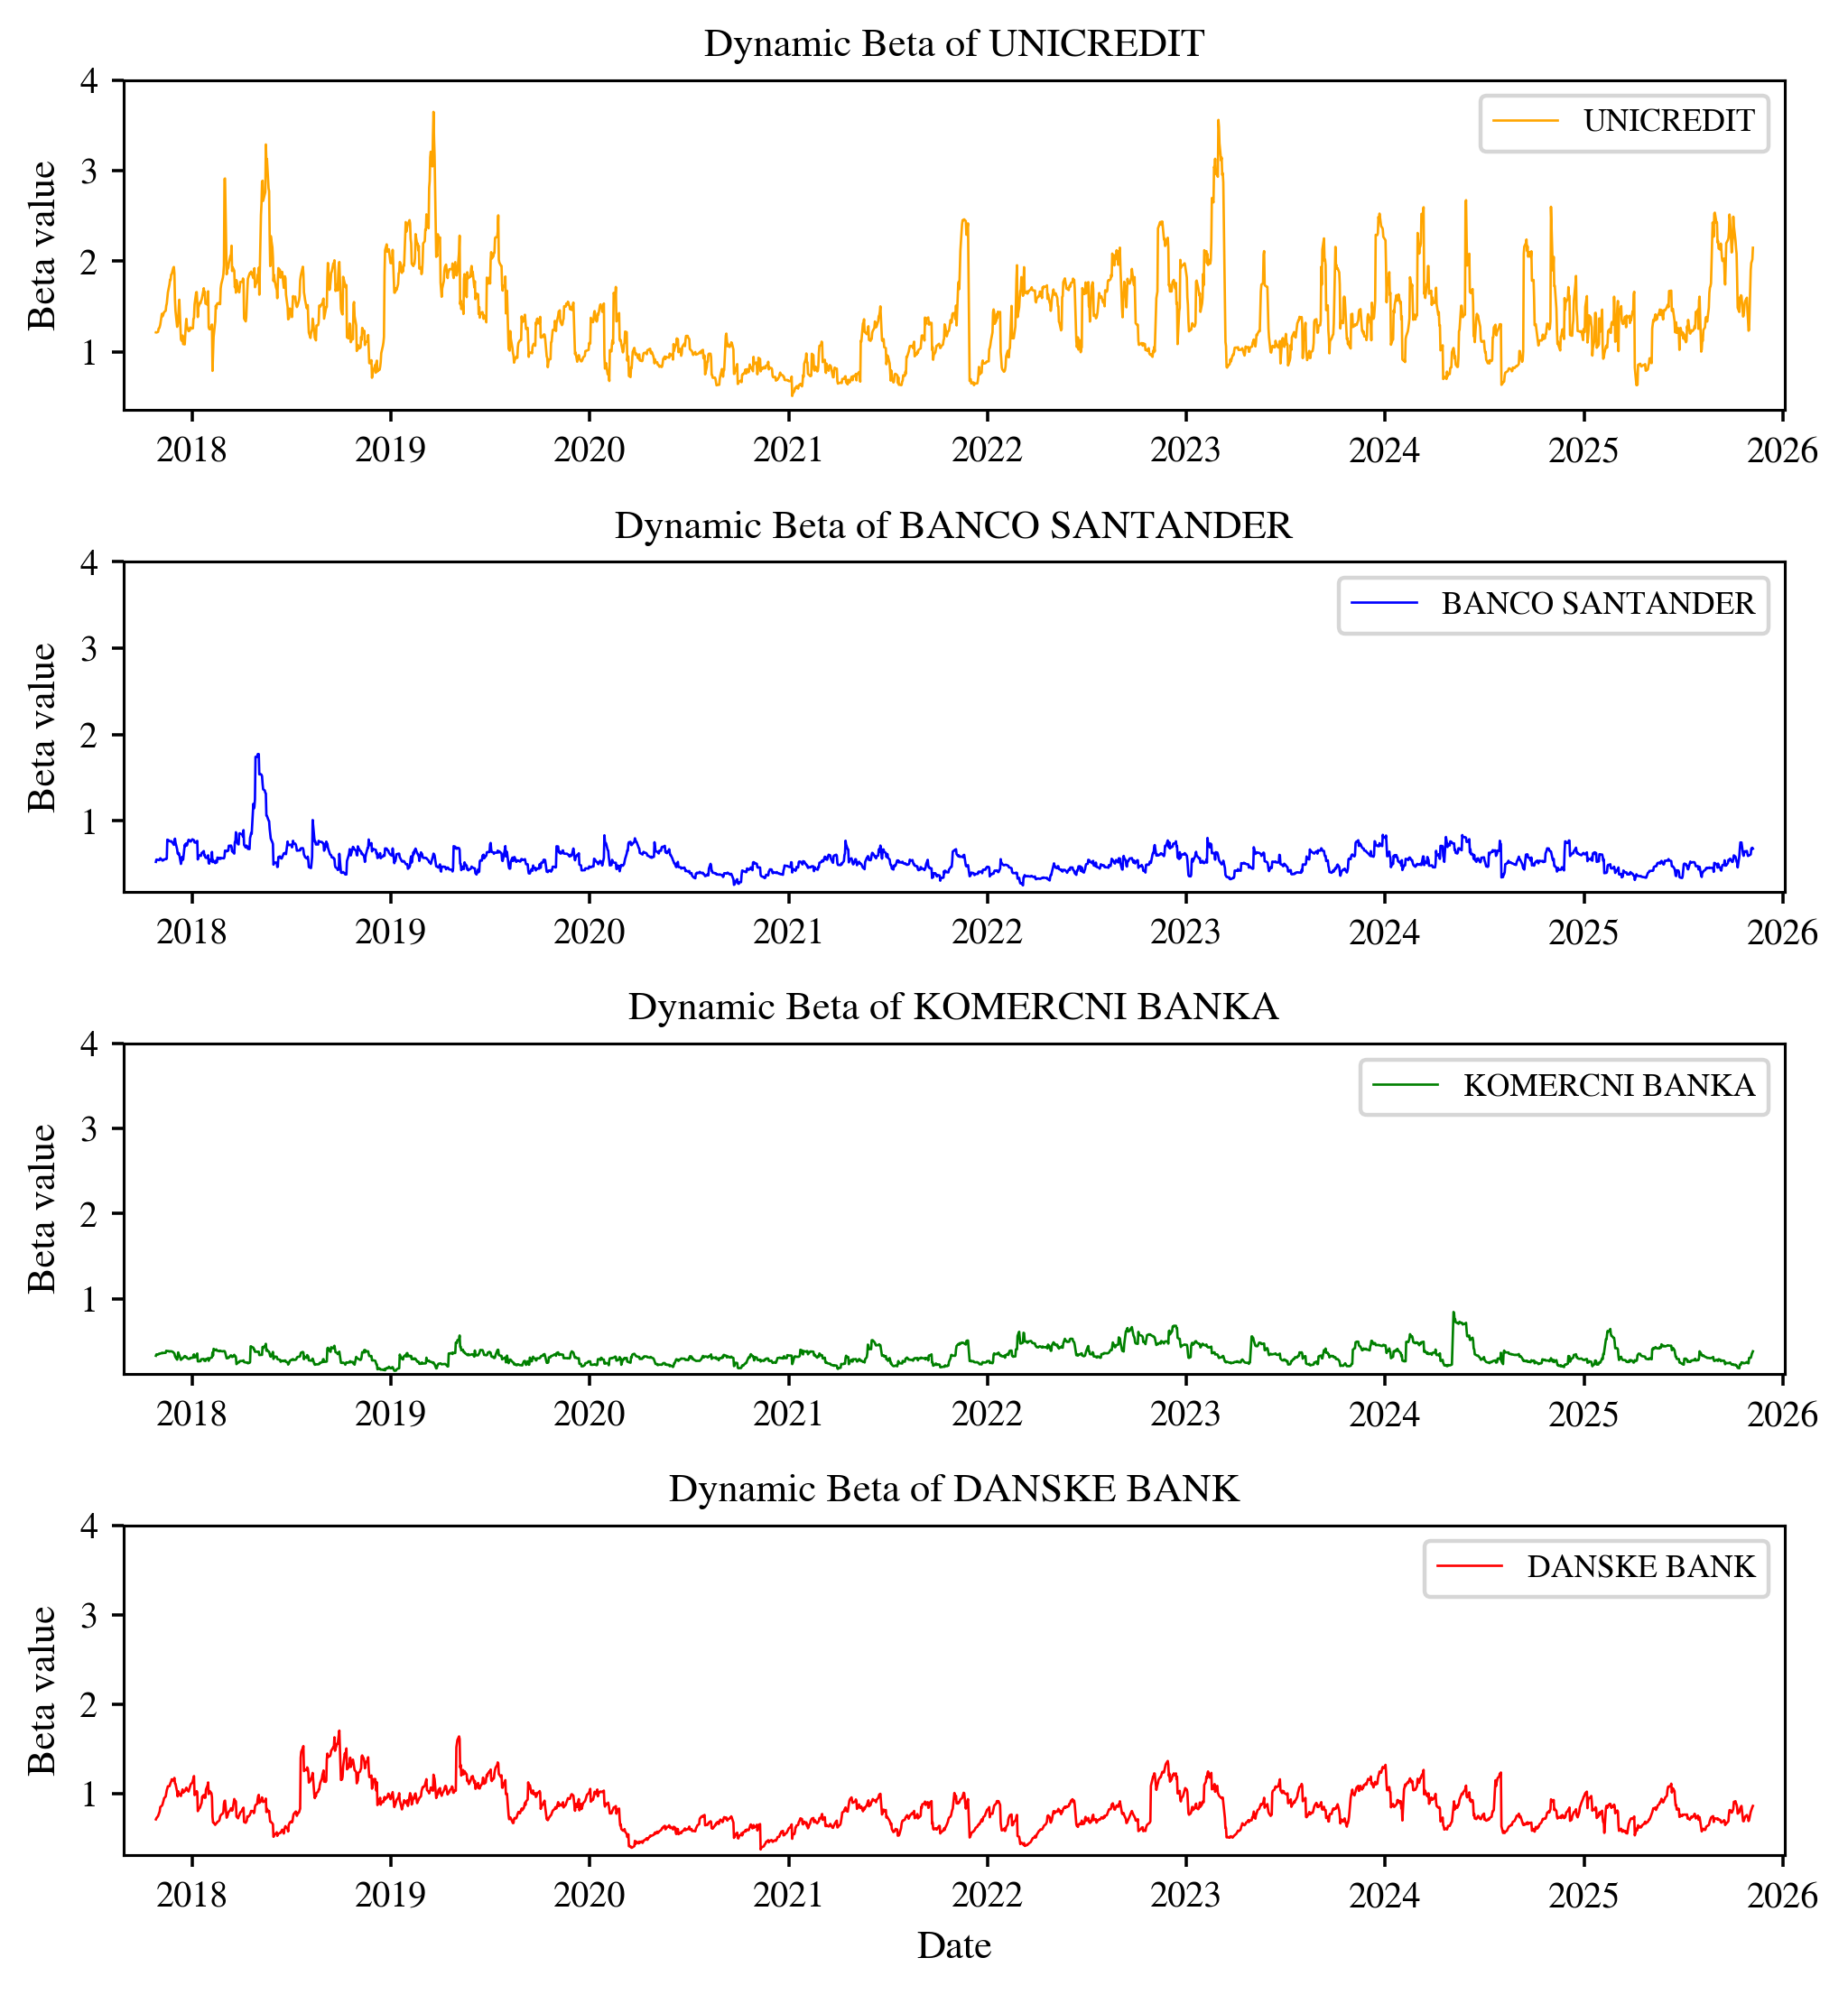

In [161]:
# Plot dynamic betas for the chosen run
B = beta_by_run.get(PLOT_RUN)
if B is None or B.empty:
    raise ValueError(f"No beta data found for PLOT_RUN={PLOT_RUN}. Available: {list(beta_by_run.keys())}")

# Select banks by position (fallback if not enough columns)
columns_to_plot = [19, 12, 5, 7]
columns_to_plot = [i for i in columns_to_plot if i < B.shape[1]]
selected_banks = B.columns[columns_to_plot] if columns_to_plot else B.columns[:4]

colors = ["orange", "blue", "green", "red"][:len(selected_banks)]

fig, axes = plt.subplots(
    nrows=len(selected_banks),
    ncols=1,
    figsize=(6.5, 7.0),
    sharex=False
)

axes = np.atleast_1d(axes)

for ax, bank, color in zip(axes, selected_banks, colors):
    ax.plot(B.index, B[bank], color=color, label=bank)
    ax.set_title(f"Dynamic Beta of {bank}", pad=6)
    ax.set_ylabel("Beta value")
    ax.legend(loc="upper right", frameon=True, fontsize=8)
    ax.grid(False)
    ax.margins(x=0.02)

for ax in axes:
    ax.tick_params(axis="x", labelbottom=True)
    ax.set_yticks([1, 2, 3, 4])

axes[-1].set_xlabel("Date")

fig.tight_layout()
fig.savefig(FIG_DIR / f"Dynamic_betas_{PLOT_RUN}.pdf")
plt.show()


Plot the GPR index into the conditional betas

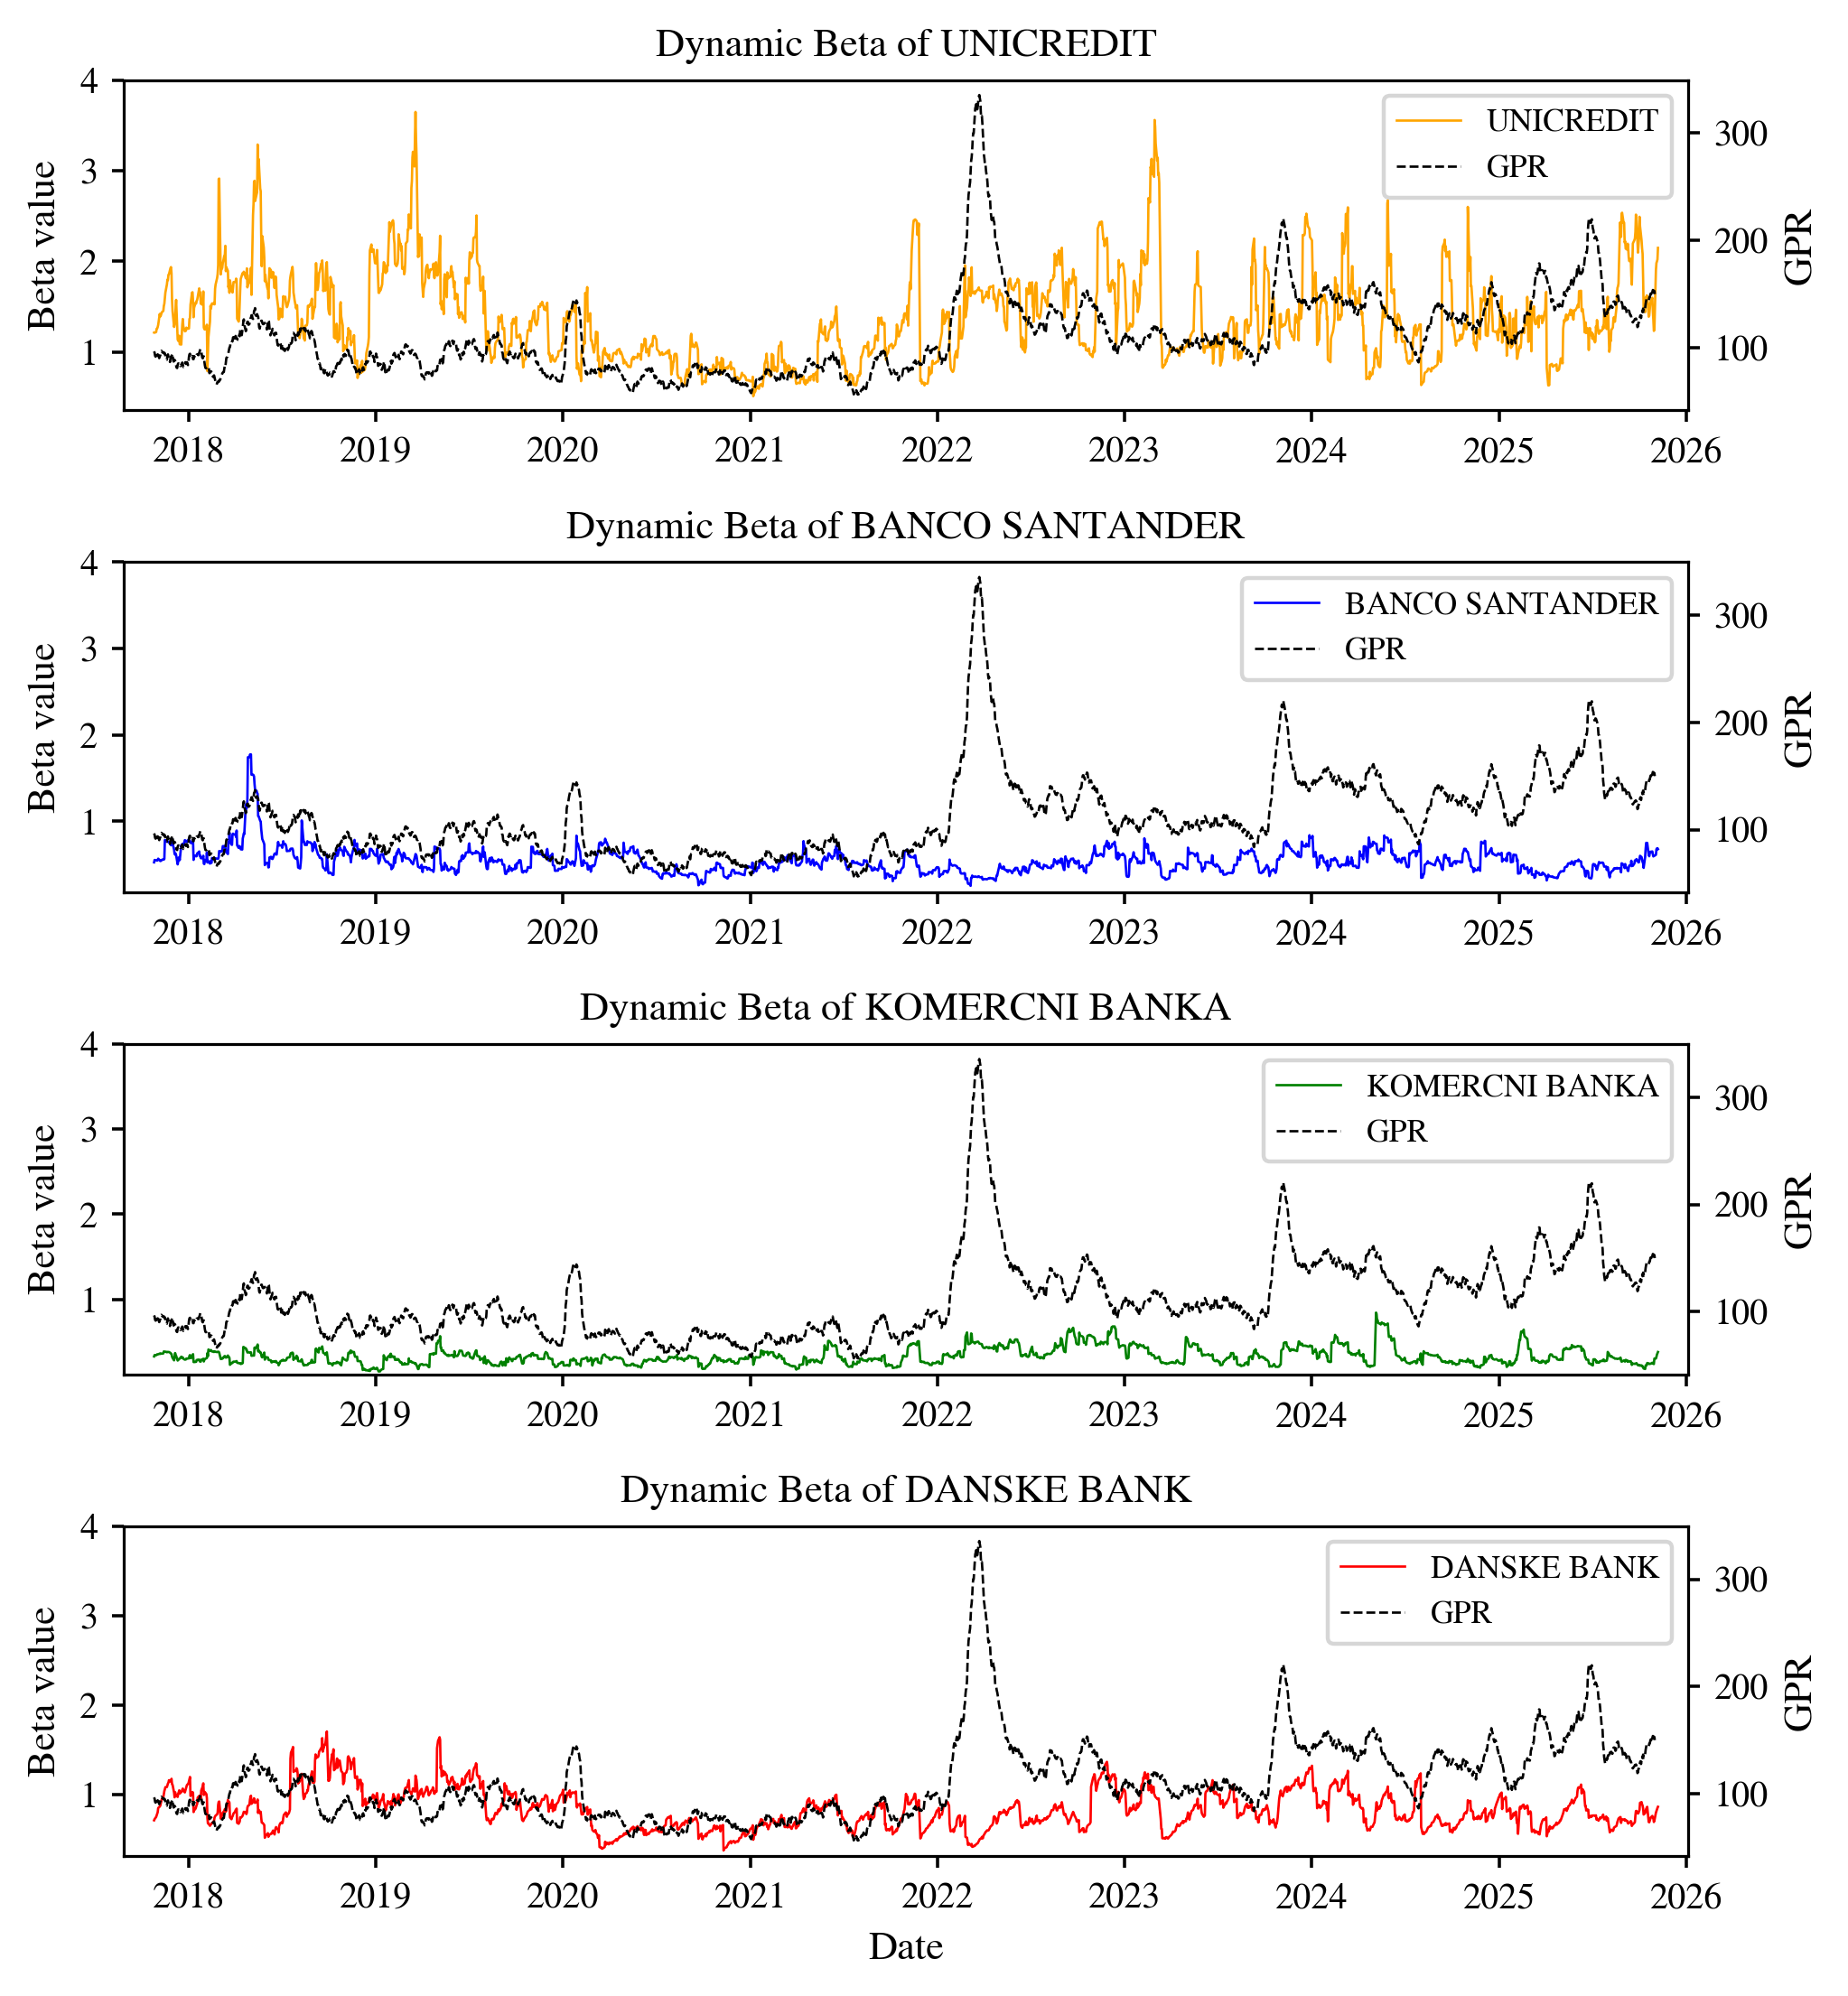

In [162]:
# Pick beta series for the chosen run
B = beta_by_run.get(PLOT_RUN)
if B is None or B.empty:
    raise ValueError(f"No beta data found for PLOT_RUN={PLOT_RUN}. Available: {list(beta_by_run.keys())}")

# Ensure GPR overlaps beta date range
gpr_plot = gpr_data[(gpr_data.index >= B.index.min()) & (gpr_data.index <= B.index.max())]

# Select banks by position (fallback if not enough columns)
columns_to_plot = [19, 12, 5, 7]
columns_to_plot = [i for i in columns_to_plot if i < B.shape[1]]
selected_banks = B.columns[columns_to_plot] if columns_to_plot else B.columns[:4]

colors = ["orange", "blue", "green", "red"][:len(selected_banks)]

fig, axes = plt.subplots(
    nrows=len(selected_banks),
    ncols=1,
    figsize=(6.5, 7.0),
    sharex=False
)

axes = np.atleast_1d(axes)

for ax, bank, color in zip(axes, selected_banks, colors):

    # Left axis: beta
    beta_line, = ax.plot(B.index, B[bank], color=color, label=bank)

    ax.set_title(f"Dynamic Beta of {bank}", pad=6)
    ax.set_ylabel("Beta value")
    ax.set_yticks([1, 2, 3, 4])
    ax.margins(x=0.02)
    ax.grid(False)

    # Right axis: GPR
    ax_gpr = ax.twinx()
    gpr_line, = ax_gpr.plot(
        gpr_plot.index,
        gpr_plot["GPR"],
        color="black",
        linestyle="--",
        label="GPR"
    )

    ax_gpr.set_ylabel("GPR")
    ax_gpr.tick_params(axis="y")

    ax.legend(handles=[beta_line, gpr_line], loc="upper right", frameon=True, fontsize=8)

for ax in axes:
    ax.tick_params(axis="x", labelbottom=True)

axes[-1].set_xlabel("Date")

fig.tight_layout()
fig.savefig(FIG_DIR / f"Dynamic_betas_with_gpr_{PLOT_RUN}.pdf")
plt.show()

Correlation between GPR and betas

In [163]:
# Calculate correlation between GPR index and conditional betas for selected banks
for run_name, B in beta_by_run.items():
    print(f"\n=== Correlations: {run_name} ===")

    # Pick same banks as before if columns_to_plot exists, else first 4
    cols = [i for i in columns_to_plot if i < B.shape[1]] if "columns_to_plot" in globals() else []
    banks = B.columns[cols] if cols else B.columns[:4]

    for bank in banks:
        merged = pd.merge(B[[bank]], gpr_data[["GPR"]], left_index=True, right_index=True, how="inner")
        corr = merged[bank].corr(merged["GPR"])
        print(f"Correlation between GPR and beta of {bank}: {corr:.4f}")


=== Correlations: GSIB ===
Correlation between GPR and beta of JP MORGAN CHASE & CO.: -0.0890
Correlation between GPR and beta of HSBC HOLDINGS: 0.0200
Correlation between GPR and beta of INDL&COML.BOC.: -0.2147
Correlation between GPR and beta of DEUTSCHE BANK: 0.0697

=== Correlations: OSII_A ===
Correlation between GPR and beta of UNICREDIT: -0.0507
Correlation between GPR and beta of BANCO SANTANDER: -0.0543
Correlation between GPR and beta of KOMERCNI BANKA: 0.0457
Correlation between GPR and beta of DANSKE BANK: -0.0635

=== Correlations: OSII_B ===
Correlation between GPR and beta of UNICREDIT: 0.0756
Correlation between GPR and beta of BANCO SANTANDER: 0.1429
Correlation between GPR and beta of KOMERCNI BANKA: 0.0837
Correlation between GPR and beta of DANSKE BANK: 0.0456

=== Correlations: OSII_C ===
Correlation between GPR and beta of UNICREDIT: 0.2233
Correlation between GPR and beta of BANCO SANTANDER: -0.0672
Correlation between GPR and beta of KOMERCNI BANKA: 0.3334
Corr

# SRISK

First some preparations. We want to match the dates of $E_t$ and $D_t$ with the betas.

In [164]:
# SRISK preparation (aligned with current runs / ascending indices)
# ===============================================================

def date_only_index(df, index_name="DATE"):
    df = df.copy()
    df.index = pd.to_datetime(df.index).normalize()
    df.index.name = index_name
    return df

def to_yearly_start(df):
    # take last observation in each calendar year, then label it as Jan 1 of that year
    yearly = df.resample("Y").last()
    yearly.index = yearly.index.to_period("Y").to_timestamp("Y").normalize()
    yearly.index = yearly.index - pd.offsets.YearBegin(1)  # -> Jan 1
    return yearly.sort_index()  # keep old -> new

for run_name in runs.keys():

    # --- 1) Align daily equity to beta index ---
    B = beta_by_run.get(run_name)
    if B is None or B.empty:
        print(f"Skipping {run_name}: no beta found")
        continue

    equity_daily = runs[run_name]["equity"].copy()
    equity_daily = equity_daily.reindex(B.index)

    assert equity_daily.index.equals(B.index), f"{run_name}: equity and beta indices not aligned!"
    runs[run_name]["equity_aligned"] = equity_daily

    # --- 2) Prepare liabilities/assets as YEARLY (Jan 1 labels) ---
    Lq = date_only_index(runs[run_name]["liabilities"], "PERIOD")
    Aq = date_only_index(runs[run_name]["assets"], "PERIOD")

    L_year = to_yearly_start(Lq)
    A_year = to_yearly_start(Aq)

    runs[run_name]["liabilities_yearly"] = L_year
    runs[run_name]["assets_yearly"] = A_year

    print(f"✅ {run_name}: equity aligned to beta + yearly liabilities/assets prepared")

✅ GSIB: equity aligned to beta + yearly liabilities/assets prepared
✅ OSII_A: equity aligned to beta + yearly liabilities/assets prepared
✅ OSII_B: equity aligned to beta + yearly liabilities/assets prepared
✅ OSII_C: equity aligned to beta + yearly liabilities/assets prepared


C:\Users\Asus\AppData\Local\Temp\ipykernel_13460\2878767796.py:12: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly = df.resample("Y").last()
C:\Users\Asus\AppData\Local\Temp\ipykernel_13460\2878767796.py:12: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly = df.resample("Y").last()
C:\Users\Asus\AppData\Local\Temp\ipykernel_13460\2878767796.py:12: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly = df.resample("Y").last()
C:\Users\Asus\AppData\Local\Temp\ipykernel_13460\2878767796.py:12: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly = df.resample("Y").last()
C:\Users\Asus\AppData\Local\Temp\ipykernel_13460\2878767796.py:12: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly = df.resample("Y").la

Now we want to reindex to the trading-day index from yearly, and interpolate by time by forward-filling

In [165]:
# Align liabilities and assets to beta index with forward-fill
def reindex_to_beta_and_ffill(df, target_idx, cols):
    df2 = df.loc[:, cols].copy()
    df2.index = pd.to_datetime(df2.index).normalize()
    df2 = df2.sort_index()

    target_idx = pd.to_datetime(target_idx).normalize().sort_values()
    union_idx = target_idx.union(df2.index).sort_values()

    out = df2.reindex(union_idx).ffill()
    return out.reindex(target_idx)

for run_name in runs.keys():
    B = beta_by_run.get(run_name)
    if B is None or B.empty:
        print(f"Skipping {run_name}: no beta found")
        continue

    target_idx = B.index

    L = runs[run_name]["liabilities_yearly"]
    A = runs[run_name]["assets_yearly"]

    common_cols = [c for c in B.columns if c in L.columns and c in A.columns]
    if len(common_cols) == 0:
        print(f"Skipping {run_name}: no common columns between beta/liabilities/assets")
        continue

    runs[run_name]["liabilities_aligned"] = reindex_to_beta_and_ffill(L, target_idx, common_cols)
    runs[run_name]["assets_aligned"]      = reindex_to_beta_and_ffill(A, target_idx, common_cols)

    print(f"{run_name}: liabilities aligned {runs[run_name]['liabilities_aligned'].shape}, "
          f"index matches beta: {runs[run_name]['liabilities_aligned'].index.equals(pd.to_datetime(B.index).normalize())}")
    print(f"{run_name}: assets aligned      {runs[run_name]['assets_aligned'].shape}, "
          f"index matches beta: {runs[run_name]['assets_aligned'].index.equals(pd.to_datetime(B.index).normalize())}")

GSIB: liabilities aligned (4965, 27), index matches beta: True
GSIB: assets aligned      (4965, 27), index matches beta: True
OSII_A: liabilities aligned (6236, 47), index matches beta: True
OSII_A: assets aligned      (6236, 47), index matches beta: True
OSII_B: liabilities aligned (4717, 52), index matches beta: True
OSII_B: assets aligned      (4717, 52), index matches beta: True
OSII_C: liabilities aligned (2097, 56), index matches beta: True
OSII_C: assets aligned      (2097, 56), index matches beta: True


### LRMES

We can either exponentially approximate LRMES following Acharya:

In [166]:
# Approximate LRMES using the conditional betas and a market decline of 40%
market_decline = -0.4  # 40% market drop

LRMES_by_run = {}
out_dir = Path("./Outputs presentation/Dataframes")
out_dir.mkdir(parents=True, exist_ok=True)

for run_name, B in beta_by_run.items():
    LRMES = 1 - np.exp(B * market_decline)
    LRMES_by_run[run_name] = LRMES

    print(f"\nLRMES ({run_name}) preview (first 5 rows, first 4 cols):")
    print(LRMES.iloc[:5, :4].to_string())
    print(f"\nLRMES ({run_name}) preview (last 5 rows, first 4 cols):")
    print(LRMES.iloc[-5:, :4].to_string())

    LRMES.to_csv(out_dir / f"{run_name}_LRMES_beta.csv")

print(f"\n💾 Saved LRMES CSVs to: {out_dir.resolve()}")



LRMES (GSIB) preview (first 5 rows, first 4 cols):
            ROYAL BANK OF CANADA  TORONTO DOMINION  UBS GROUP  BANK OF CHINA
DATE                                                                        
2006-10-30              0.210635          0.209576   0.372118       0.136472
2006-10-31              0.211291          0.209812   0.373925       0.138191
2006-11-01              0.212360          0.211678   0.421450       0.140218
2006-11-02              0.218690          0.212880   0.423373       0.142535
2006-11-03              0.239002          0.230825   0.424449       0.143434

LRMES (GSIB) preview (last 5 rows, first 4 cols):
            ROYAL BANK OF CANADA  TORONTO DOMINION  UBS GROUP  BANK OF CHINA
DATE                                                                        
2025-11-03              0.204497          0.220286   0.328807       0.120873
2025-11-04              0.212588          0.219364   0.329161       0.143198
2025-11-05              0.223179          0.240042

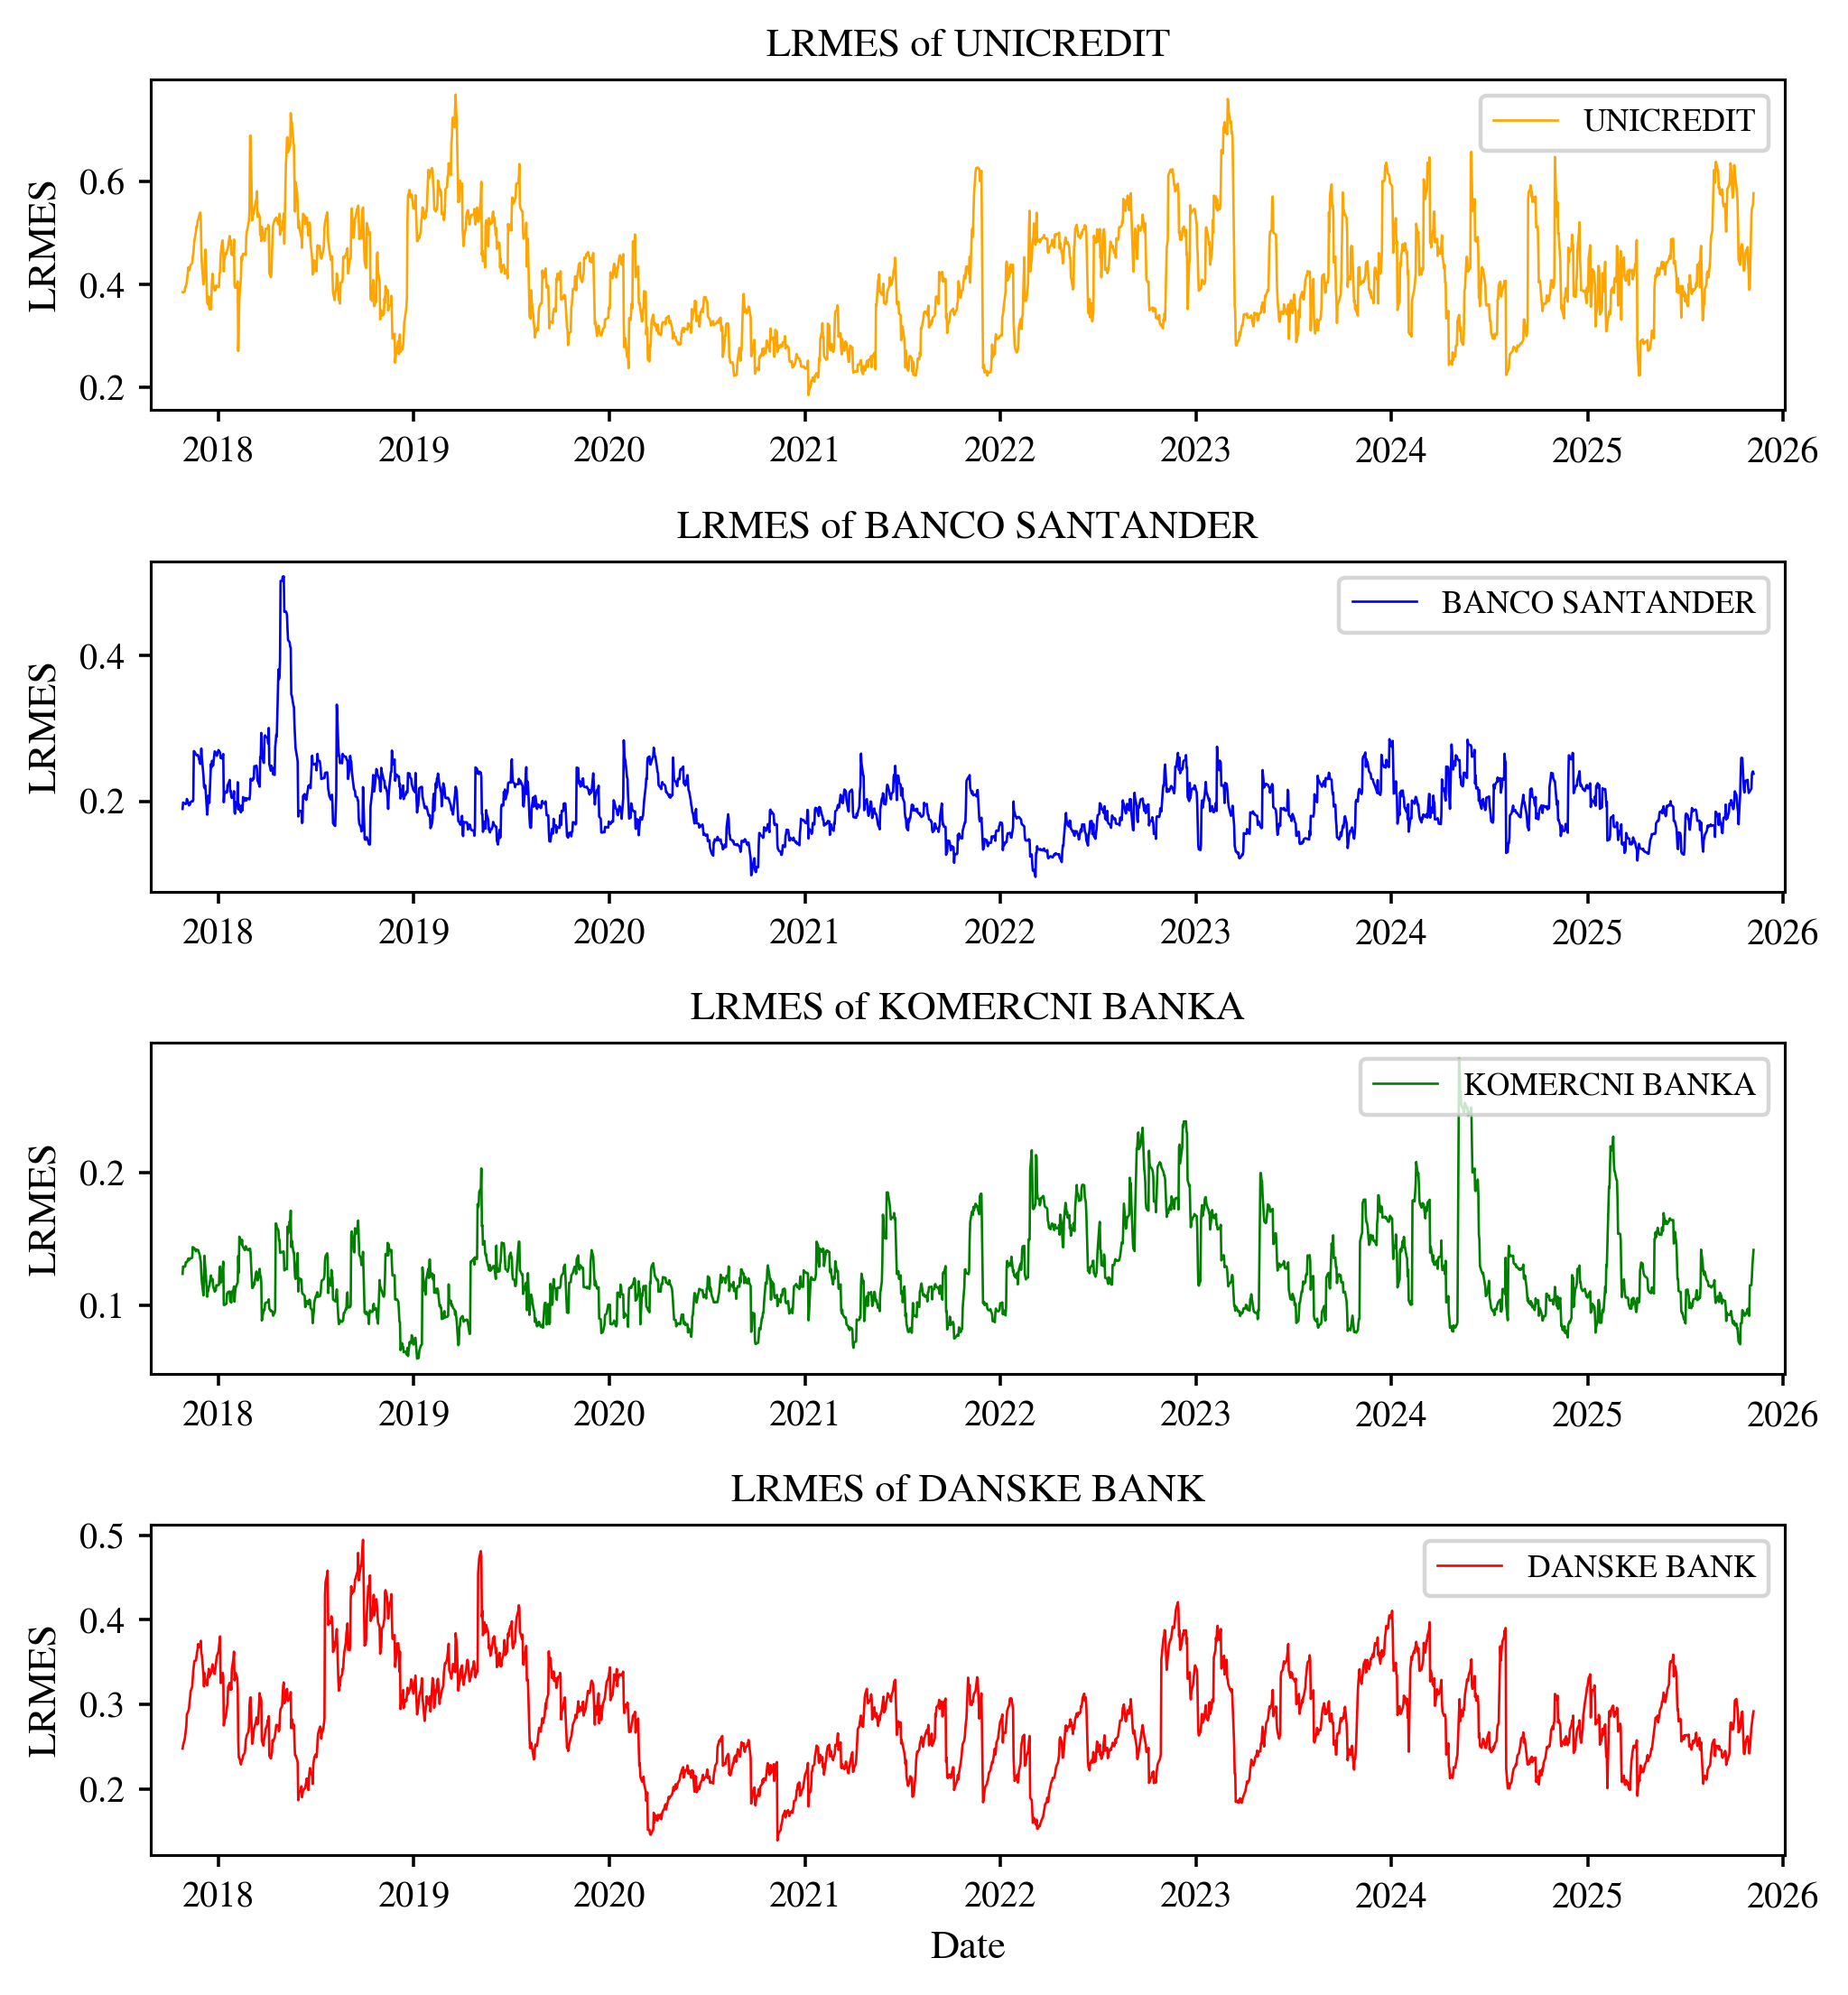

In [167]:
# Select the columns to plot approximated LRMES for selected banks
LR = LRMES_by_run.get(PLOT_RUN)
if LR is None or LR.empty:
    raise ValueError(f"No LRMES data found for PLOT_RUN={PLOT_RUN}. Available: {list(LRMES_by_run.keys())}")

# Select banks by position (fallback if not enough columns)
cols = [i for i in columns_to_plot if i < LR.shape[1]] if "columns_to_plot" in globals() else []
selected_banks = LR.columns[cols] if cols else LR.columns[:4]

colors = ["orange", "blue", "green", "red"][:len(selected_banks)]

fig, axes = plt.subplots(
    nrows=len(selected_banks),
    ncols=1,
    figsize=(6.5, 7.0),
    sharex=False
)

axes = np.atleast_1d(axes)

for ax, bank, color in zip(axes, selected_banks, colors):
    ax.plot(LR.index, LR[bank], color=color, label=bank)
    ax.set_title(f"LRMES of {bank}", pad=6)
    ax.set_ylabel("LRMES")
    ax.legend(loc="upper right", frameon=True, fontsize=8)
    ax.grid(False)
    ax.margins(x=0.02)

for ax in axes:
    ax.tick_params(axis="x", labelbottom=True)

axes[-1].set_xlabel("Date")

fig.tight_layout()
fig.savefig(FIG_DIR / f"LRMES_{PLOT_RUN}.pdf")
plt.show()

Correlate LRMES with the GPR index

In [168]:
# Calculate correlation between GPR index and LRMES for selected banks
for run_name, LR in LRMES_by_run.items():
    print(f"\n=== Correlations: {run_name} ===")

    # Use same selection logic if columns_to_plot exists; otherwise take first 4 banks
    cols = [i for i in columns_to_plot if i < LR.shape[1]] if "columns_to_plot" in globals() else []
    banks = LR.columns[cols] if cols else LR.columns[:4]

    for bank in banks:
        merged = pd.merge(LR[[bank]], gpr_data[["GPR"]], left_index=True, right_index=True, how="inner")
        corr = merged[bank].corr(merged["GPR"])
        print(f"Correlation between GPR and LRMES of {bank}: {corr:.4f}")


=== Correlations: GSIB ===
Correlation between GPR and LRMES of JP MORGAN CHASE & CO.: -0.0875
Correlation between GPR and LRMES of HSBC HOLDINGS: 0.0245
Correlation between GPR and LRMES of INDL&COML.BOC.: -0.2253
Correlation between GPR and LRMES of DEUTSCHE BANK: 0.0920

=== Correlations: OSII_A ===
Correlation between GPR and LRMES of UNICREDIT: -0.0668
Correlation between GPR and LRMES of BANCO SANTANDER: -0.0603
Correlation between GPR and LRMES of KOMERCNI BANKA: 0.0465
Correlation between GPR and LRMES of DANSKE BANK: -0.0685

=== Correlations: OSII_B ===
Correlation between GPR and LRMES of UNICREDIT: 0.1101
Correlation between GPR and LRMES of BANCO SANTANDER: 0.1435
Correlation between GPR and LRMES of KOMERCNI BANKA: 0.0828
Correlation between GPR and LRMES of DANSKE BANK: 0.0462

=== Correlations: OSII_C ===
Correlation between GPR and LRMES of UNICREDIT: 0.2548
Correlation between GPR and LRMES of BANCO SANTANDER: -0.0803
Correlation between GPR and LRMES of KOMERCNI BAN

Or compute it directly from the DCC-GARCH model output (following Engle/Brownlees):

In [169]:
# Compute LRMES using DCC-GARCH conditional covariances
HORIZON_DAYS = 125
CRASH_SIMPLE = -0.40
CRASH_LOG    = np.log(1.0 + CRASH_SIMPLE)

out_dir = Path("./Outputs presentation/Dataframes")
out_dir.mkdir(parents=True, exist_ok=True)

LRMES_DCC_by_run = {}

for run_name, H_df in H_df_by_run.items():

    # infer N from number of H_ij columns
    H_cols = [c for c in H_df.columns if c.startswith("H_")]
    N = int(np.sqrt(len(H_cols)))
    if N < 2:
        print(f"Skipping {run_name}: N < 2")
        continue

    dates = H_df.index
    T = len(dates)

    # Precompute denominators: H_11 is market variance (MSCI is first series in DCC ordering)
    h_mm = H_df["H_11"].astype(float).values

    # Storage: (T, N-1) for banks 2..N
    lrmes_ts = np.full((T, N - 1), np.nan, dtype=float)

    for t in range(T):
        # Convert from (% log returns)^2 daily cov to decimal log cov over horizon
        var_m = (h_mm[t] * HORIZON_DAYS) / (100.0 ** 2)
        if not np.isfinite(var_m) or var_m <= 0:
            continue

        sd_m = np.sqrt(var_m)
        logP_crash = norm.logcdf(CRASH_LOG / sd_m)

        for i in range(2, N + 1):
            var_i  = (H_df[f"H_{i}{i}"].iat[t] * HORIZON_DAYS) / (100.0 ** 2)
            cov_im = (H_df[f"H_{i}1"].iat[t] * HORIZON_DAYS) / (100.0 ** 2)

            if (not np.isfinite(var_i)) or (not np.isfinite(cov_im)) or var_i < 0:
                continue

            log_num = norm.logcdf((CRASH_LOG - cov_im) / sd_m)
            cond_E_gross = np.exp(0.5 * var_i + (log_num - logP_crash))
            lrmes_ts[t, i - 2] = 1.0 - cond_E_gross

    # Use the same names as your beta files (banks only, MSCI excluded)
    # If you want the *exact* bank names, pull them from beta_by_run (recommended)
    if run_name in beta_by_run:
        bank_cols = list(beta_by_run[run_name].columns)
    else:
        bank_cols = [f"Bank_{k}" for k in range(1, N)]

    LRMES_DCC = pd.DataFrame(lrmes_ts, index=dates, columns=bank_cols)
    LRMES_DCC_by_run[run_name] = LRMES_DCC

    # Save
    LRMES_DCC.to_csv(out_dir / f"DCC_LRMES_{run_name}_daily.csv")

    print(f"✅ {run_name}: LRMES(DCC) computed & saved {LRMES_DCC.shape}")
    print(LRMES_DCC.iloc[:2, :6].to_string())

print(f"\n💾 Saved LRMES(DCC) CSVs to: {out_dir.resolve()}")

✅ GSIB: LRMES(DCC) computed & saved (4965, 27)
            ROYAL BANK OF CANADA  TORONTO DOMINION  UBS GROUP  BANK OF CHINA  CHINA CON.BANK  INDL&COML.BOC.
DATE                                                                                                        
2006-10-30              0.271569          0.270103   0.461590       0.168231        0.181630        0.179448
2006-10-31              0.271658          0.269699   0.462768       0.170427        0.184669        0.183193
✅ OSII_A: LRMES(DCC) computed & saved (6236, 47)
            ERSTE GROUP BANK  KBC GROUP  HELLENIC BANK     BAYER  DEUTSCHE BANK  KOMERCNI BANKA
DATE                                                                                           
2001-12-14          0.391047   0.470391       0.055820  0.254227       0.443743        0.172247
2001-12-17          0.394194   0.484695       0.056833  0.253142       0.444819        0.175058
✅ OSII_B: LRMES(DCC) computed & saved (4717, 52)
            ERSTE GROUP BANK  KBC G

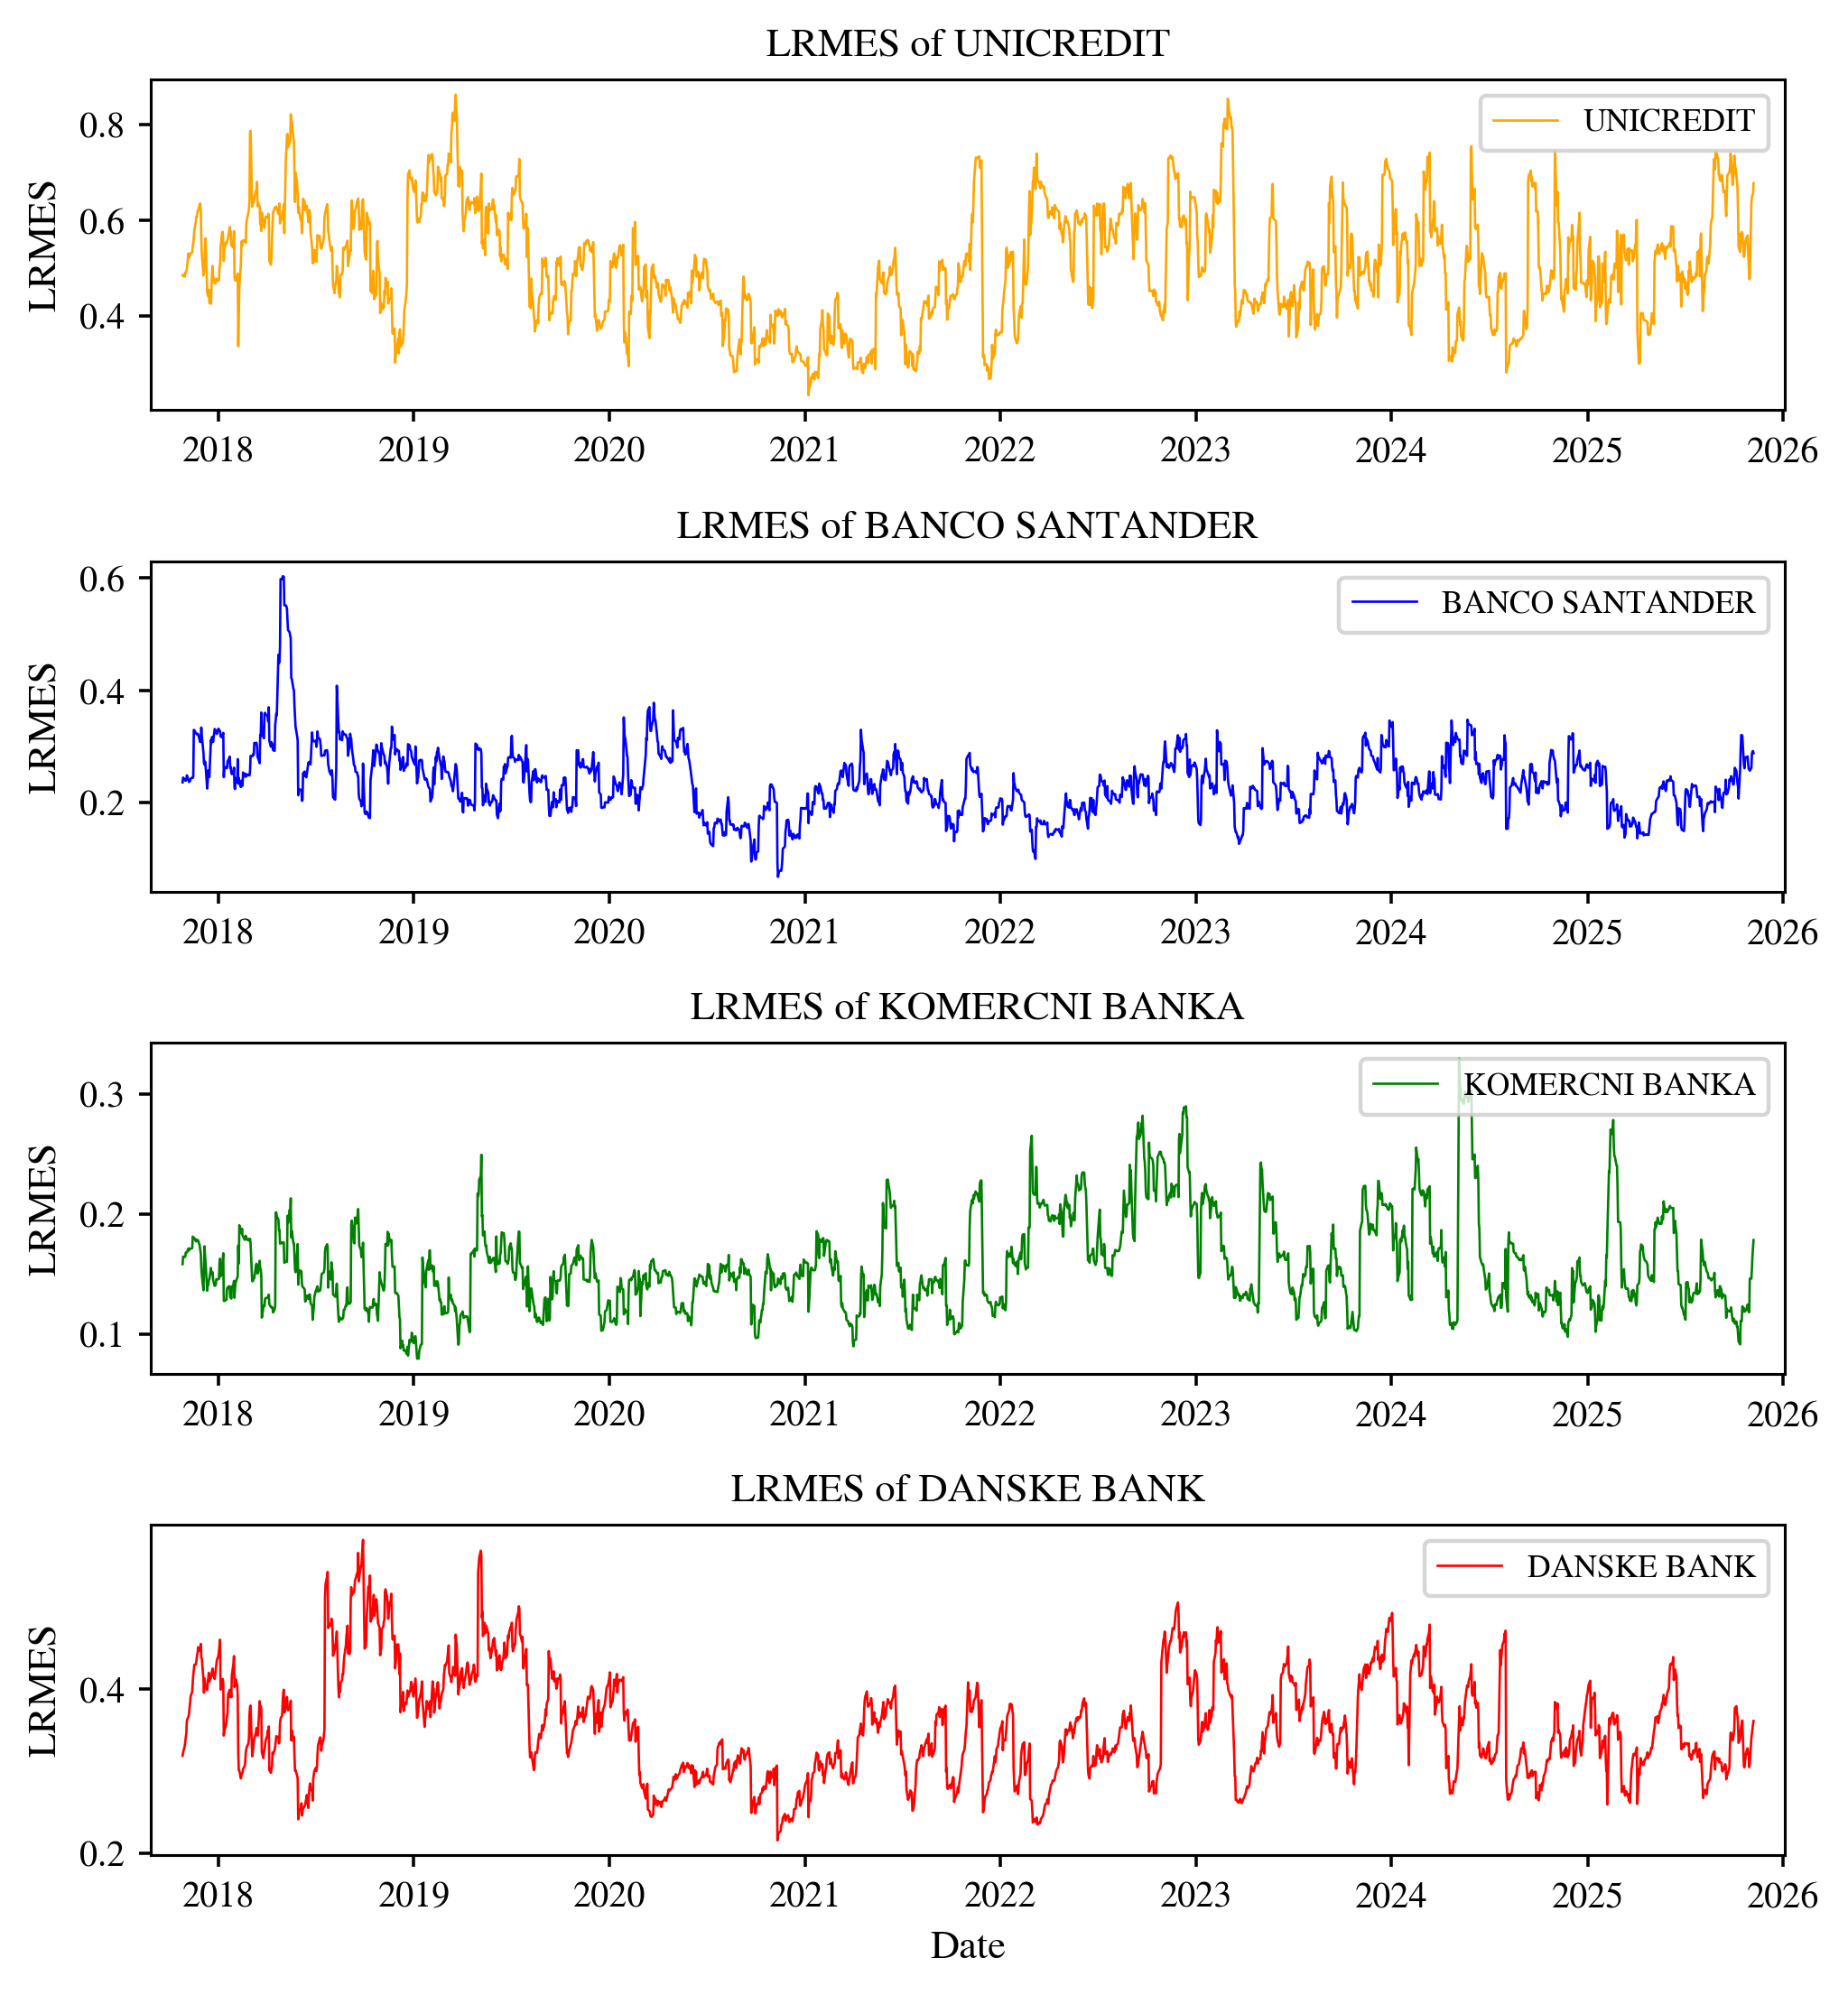

In [170]:
# Plot DCC-based LRMES selected banks
LR = LRMES_DCC_by_run.get(PLOT_RUN)
if LR is None or LR.empty:
    raise ValueError(f"No DCC-LRMES found for PLOT_RUN={PLOT_RUN}. Available: {list(LRMES_DCC_by_run.keys())}")

# Select banks by position (fallback if not enough columns)
cols = [i for i in columns_to_plot if i < LR.shape[1]] if "columns_to_plot" in globals() else []
selected_banks = LR.columns[cols] if cols else LR.columns[:4]

colors = ["orange", "blue", "green", "red"][:len(selected_banks)]

fig, axes = plt.subplots(
    nrows=len(selected_banks),
    ncols=1,
    figsize=(6.5, 7.0),
    sharex=False
)

axes = np.atleast_1d(axes)

for ax, bank, color in zip(axes, selected_banks, colors):
    ax.plot(LR.index, LR[bank], color=color, label=bank)
    ax.set_title(f"LRMES of {bank}", pad=6)
    ax.set_ylabel("LRMES")
    ax.legend(loc="upper right", frameon=True, fontsize=8)
    ax.grid(False)
    ax.margins(x=0.02)

for ax in axes:
    ax.tick_params(axis="x", labelbottom=True)

axes[-1].set_xlabel("Date")

fig.tight_layout()
fig.savefig(FIG_DIR / f"LRMES_DCC_{PLOT_RUN}.pdf")
plt.show()


In [171]:
# Pick which LRMES definition is FINAL for SRISK downstream
LRMES_final_by_run = LRMES_DCC_by_run   # use DCC-based LRMES

# Store inside runs so downstream code can always do: runs[run]["LRMES"]
for run_name, LR in LRMES_final_by_run.items():
    runs[run_name]["LRMES"] = LR

Finally we are ready to apply the SRISK formula

In [172]:
# Set a capital ratio
k = 0.08

# Output folder
out_dir = Path("./Outputs presentation/Dataframes")
out_dir.mkdir(parents=True, exist_ok=True)

SRISK_local_by_run = {}
SRISK_local_max0_by_run = {}

for run_name, r in runs.items():

    L = r.get("liabilities_aligned")
    E = r.get("equity_aligned")
    LR = r.get("LRMES")

    if L is None or E is None or LR is None or L.empty or E.empty or LR.empty:
        print(f"Skipping {run_name}: missing inputs (liabilities_aligned / equity_aligned / LRMES)")
        continue

    # common columns
    common_cols = [c for c in LR.columns if (c in E.columns) and (c in L.columns)]
    if len(common_cols) == 0:
        print(f"Skipping {run_name}: no common bank columns across L/E/LRMES")
        continue

    Lc  = L[common_cols].copy()
    Ec  = E[common_cols].copy()
    LRc = LR[common_cols].copy()

    # align index robustly
    idx = Ec.index.intersection(Lc.index).intersection(LRc.index)
    Lc  = Lc.reindex(idx)
    Ec  = Ec.reindex(idx)
    LRc = LRc.reindex(idx)

    # Raw SRISK (keep negatives)
    SRISK_raw = k * (Lc + Ec) - (1 - LRc) * Ec

    # Truncated SRISK (max(., 0))
    SRISK_max0 = SRISK_raw.clip(lower=0)

    # store
    SRISK_local_by_run[run_name] = SRISK_raw
    SRISK_local_max0_by_run[run_name] = SRISK_max0

    runs[run_name]["SRISK_local"] = SRISK_raw
    runs[run_name]["SRISK_local_max0"] = SRISK_max0

    # preview (latest 10, newest first)
    print(f"\nSRISK (raw) for {run_name} (latest 10, newest first):")
    with pd.option_context("display.float_format", "{:,.0f}".format):
        print(SRISK_raw.tail(10).iloc[::-1])

    print(f"\nSRISK (max0) for {run_name} (latest 10, newest first):")
    with pd.option_context("display.float_format", "{:,.0f}".format):
        print(SRISK_max0.tail(10).iloc[::-1])

    # save
    SRISK_raw.to_csv(out_dir / f"SRISK_{run_name}_local.csv")
    SRISK_max0.to_csv(out_dir / f"SRISK_{run_name}_local_max0.csv")

print(f"\n💾 Saved SRISK CSVs to: {out_dir.resolve()}")

# Optional convenience aliases
GSIBs_SRISK        = SRISK_local_by_run.get("GSIB", pd.DataFrame())
OSII_A_SRISK       = SRISK_local_by_run.get("OSII_A", pd.DataFrame())
OSII_B_SRISK       = SRISK_local_by_run.get("OSII_B", pd.DataFrame())
OSII_C_SRISK       = SRISK_local_by_run.get("OSII_C", pd.DataFrame())

GSIBs_SRISK_max0   = SRISK_local_max0_by_run.get("GSIB", pd.DataFrame())
OSII_A_SRISK_max0  = SRISK_local_max0_by_run.get("OSII_A", pd.DataFrame())
OSII_B_SRISK_max0  = SRISK_local_max0_by_run.get("OSII_B", pd.DataFrame())
OSII_C_SRISK_max0  = SRISK_local_max0_by_run.get("OSII_C", pd.DataFrame())


SRISK (raw) for GSIB (latest 10, newest first):
            ROYAL BANK OF CANADA  TORONTO DOMINION  UBS GROUP  BANK OF CHINA  \
DATE                                                                           
2025-11-07               -21,928            34,432     58,800      2,305,698   
2025-11-06               -21,704            35,543     57,621      2,305,032   
2025-11-05               -22,302            35,110     52,796      2,306,307   
2025-11-04               -25,680            30,733     53,741      2,305,882   
2025-11-03               -30,127            29,195     53,565      2,296,548   
2025-10-31               -29,414            29,527     53,779      2,302,179   
2025-10-30               -27,516            30,207     54,175      2,298,576   
2025-10-29               -38,369            28,406     53,425      2,298,276   
2025-10-28               -41,077            26,039     52,934      2,297,604   
2025-10-27               -37,654            28,243     54,045      2,29

Plot SRISK (still in local currency)

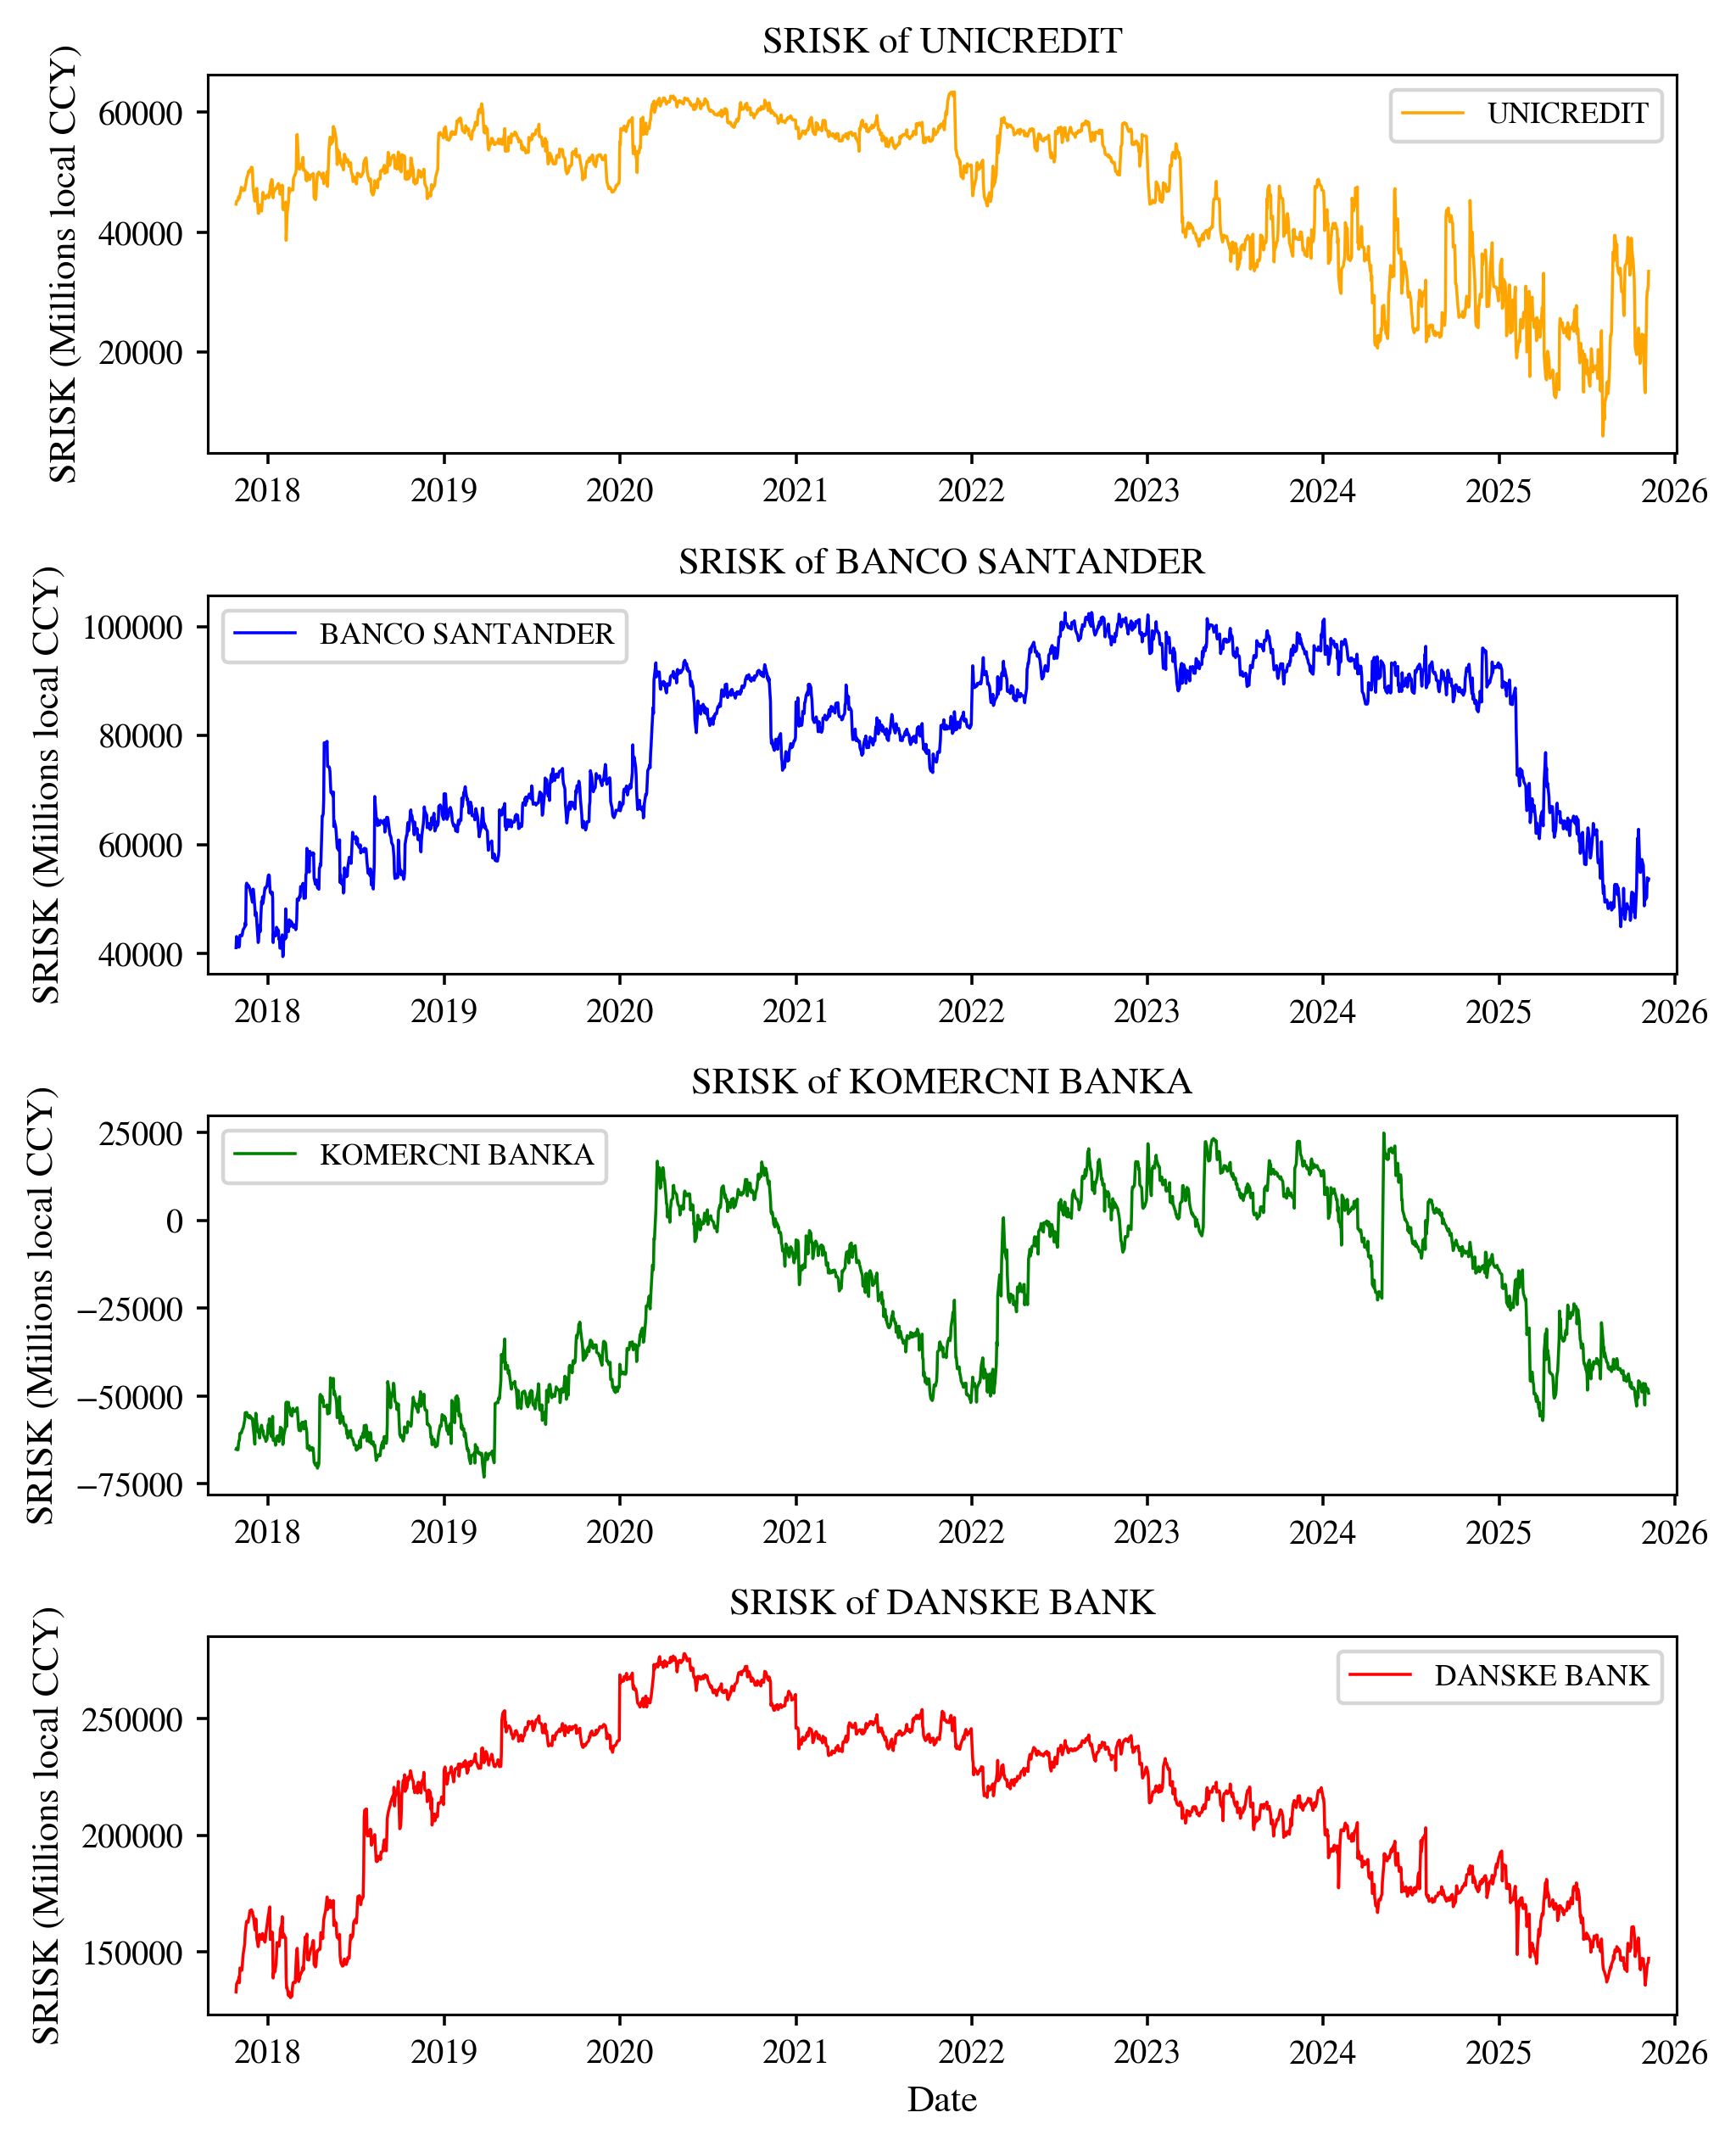

In [173]:
# Plot SRISK for selected banks in local currencies (run-aware via PLOT_RUN)

SRISK_to_plot = runs.get(PLOT_RUN, {}).get("SRISK_local")

if SRISK_to_plot is None or SRISK_to_plot.empty:
    raise ValueError(f"No SRISK_local found (or empty) for PLOT_RUN='{PLOT_RUN}'. "
                     "Make sure SRISK has been computed and stored in runs[run]['SRISK_local'].")

# Select which bank columns to plot using your existing columns_to_plot index list
valid_idx = [i for i in columns_to_plot if i < SRISK_to_plot.shape[1]]
if len(valid_idx) == 0:
    raise ValueError(f"columns_to_plot has no valid indices for PLOT_RUN='{PLOT_RUN}'. "
                     f"SRISK_to_plot has {SRISK_to_plot.shape[1]} columns.")

selected_banks = SRISK_to_plot.columns[valid_idx]

# Colors (extend automatically if you plot more than 4 banks)
from itertools import cycle
color_cycle = cycle(["orange", "blue", "green", "red", "purple", "brown", "gray"])

fig, axes = plt.subplots(
    nrows=len(selected_banks),
    ncols=1,
    figsize=(6.5, max(2.0 * len(selected_banks), 3.5)),
    sharex=False
)

# If only one bank is selected, axes is not an array
if len(selected_banks) == 1:
    axes = [axes]

for ax, bank, color in zip(axes, selected_banks, color_cycle):
    ax.plot(
        SRISK_to_plot.index,
        SRISK_to_plot[bank],
        color=color,
        linewidth=0.8,
        label=bank
    )

    ax.set_title(f"SRISK of {bank}", pad=6)
    ax.set_ylabel("SRISK (Millions local CCY)")
    ax.margins(x=0.02)
    ax.grid(False)
    ax.legend(loc="best", frameon=True, fontsize=8)

# X-axis formatting
for ax in axes:
    ax.tick_params(axis="x", labelbottom=True)

axes[-1].set_xlabel("Date")

fig.tight_layout()
plt.show()

Normalized SRISK by market cap so that we can compare banks irrespective of currency

In [174]:
# Normalized SRISK for all runs: SRISK / equity market value (market cap proxy)

out_dir = Path("./Outputs presentation/Dataframes")
out_dir.mkdir(parents=True, exist_ok=True)

SRISK_norm_by_run = {}
SRISK_norm_max0_by_run = {}

for run_name, r in runs.items():

    S_raw  = r.get("SRISK_local")
    S_max0 = r.get("SRISK_local_max0")
    M      = r.get("equity_aligned")          # equity market value (proxy for market cap)

    if S_raw is None or S_max0 is None or M is None or S_raw.empty or S_max0.empty or M.empty:
        print(f"Skipping {run_name}: missing SRISK_local / SRISK_local_max0 / equity_aligned")
        continue

    # Keep only common bank columns across SRISK and MarketCap proxy
    common_cols = [c for c in S_raw.columns if c in M.columns]
    if len(common_cols) == 0:
        print(f"Skipping {run_name}: no common bank columns across SRISK and equity_aligned")
        continue

    S_raw_c  = S_raw[common_cols].copy()
    S_max0_c = S_max0[common_cols].copy()
    M_c      = M[common_cols].copy()

    # Align indices robustly
    idx = S_raw_c.index.intersection(S_max0_c.index).intersection(M_c.index)
    S_raw_c  = S_raw_c.reindex(idx)
    S_max0_c = S_max0_c.reindex(idx)
    M_c      = M_c.reindex(idx)

    # Avoid division by zero
    M_c = M_c.replace(0, np.nan)

    # Normalized SRISK (dimensionless)
    SRISK_norm      = S_raw_c / M_c
    SRISK_norm_max0 = S_max0_c / M_c

    # Store
    SRISK_norm_by_run[run_name] = SRISK_norm
    SRISK_norm_max0_by_run[run_name] = SRISK_norm_max0

    runs[run_name]["SRISK_norm"] = SRISK_norm
    runs[run_name]["SRISK_norm_max0"] = SRISK_norm_max0

    # Quick preview (latest 5, newest first)
    print(f"\nNormalized SRISK (raw) for {run_name} (latest 5, newest first):")
    with pd.option_context("display.float_format", "{:.3f}".format):
        print(SRISK_norm.tail(5).iloc[::-1])

    print(f"\nNormalized SRISK (max0) for {run_name} (latest 5, newest first):")
    with pd.option_context("display.float_format", "{:.3f}".format):
        print(SRISK_norm_max0.tail(5).iloc[::-1])

    # Save
    SRISK_norm.to_csv(out_dir / f"SRISK_{run_name}_norm.csv")
    SRISK_norm_max0.to_csv(out_dir / f"SRISK_{run_name}_norm_max0.csv")

print(f"\n💾 Saved normalized SRISK CSVs to: {out_dir.resolve()}")

# Optional convenience aliases
GSIBs_SRISK_norm        = SRISK_norm_by_run.get("GSIB", pd.DataFrame())
OSII_A_SRISK_norm       = SRISK_norm_by_run.get("OSII_A", pd.DataFrame())
OSII_B_SRISK_norm       = SRISK_norm_by_run.get("OSII_B", pd.DataFrame())
OSII_C_SRISK_norm       = SRISK_norm_by_run.get("OSII_C", pd.DataFrame())

GSIBs_SRISK_norm_max0   = SRISK_norm_max0_by_run.get("GSIB", pd.DataFrame())
OSII_A_SRISK_norm_max0  = SRISK_norm_max0_by_run.get("OSII_A", pd.DataFrame())
OSII_B_SRISK_norm_max0  = SRISK_norm_max0_by_run.get("OSII_B", pd.DataFrame())
OSII_C_SRISK_norm_max0  = SRISK_norm_max0_by_run.get("OSII_C", pd.DataFrame())


Normalized SRISK (raw) for GSIB (latest 5, newest first):
            ROYAL BANK OF CANADA  TORONTO DOMINION  UBS GROUP  BANK OF CHINA  \
DATE                                                                           
2025-11-07                -0.077             0.179      0.580          6.020   
2025-11-06                -0.075             0.185      0.560          6.032   
2025-11-05                -0.077             0.182      0.507          6.088   
2025-11-04                -0.089             0.160      0.527          6.101   
2025-11-03                -0.103             0.149      0.523          6.089   

            CHINA CON.BANK  INDL&COML.BOC.  BANK OF COMMS.  DEUTSCHE BANK  \
DATE                                                                        
2025-11-07           0.831           5.819           3.686          1.410   
2025-11-06           0.822           5.836           3.697          1.419   
2025-11-05           0.841           5.895           3.712          1.39

Rankings of normalized SRISK

In [175]:
# Rank banks in PLOT_RUN by normalized SRISK at a specified date (exclude zeros)

NORM_KEY = "SRISK_norm_max0"
RANK_DATE = "2025-11-07"   # <- change this

df = runs.get(PLOT_RUN, {}).get(NORM_KEY)

if df is None or df.empty:
    raise ValueError(
        f"No '{NORM_KEY}' found (or empty) for PLOT_RUN='{PLOT_RUN}'. "
        f"Make sure you computed and stored runs[run]['{NORM_KEY}']."
    )

df = df.copy()
df.index = pd.to_datetime(df.index)

rank_date = pd.to_datetime(RANK_DATE)

# If exact date not available (weekend/holiday), use most recent available date <= RANK_DATE
if rank_date not in df.index:
    df_upto = df.loc[df.index <= rank_date]
    if df_upto.empty:
        raise ValueError(
            f"No data on or before {rank_date.date()} for PLOT_RUN='{PLOT_RUN}'. "
            f"First available date is {df.index.min().date()}."
        )
    used_date = df_upto.index.max()
else:
    used_date = rank_date

# Take the row for that date, drop NaNs, and EXCLUDE zeros
row = df.loc[used_date].dropna()
row = row[row != 0]  # <-- exclude exact zeros (from truncation)

if row.empty:
    print(f"\nNo non-zero values for {PLOT_RUN} on {used_date.date()} using {NORM_KEY}.")
else:
    ranking = (
        row.sort_values(ascending=False)
           .reset_index()
           .rename(columns={"index": "Bank", used_date: NORM_KEY})
    )

    ranking.insert(0, "Rank", range(1, len(ranking) + 1))

    print(f"\nRanking for {PLOT_RUN} on {used_date.date()} using {NORM_KEY} (zeros excluded):")
    display(ranking)

    # Optional: save
    out_dir = Path("./Outputs presentation/Tables")
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f"Ranking_{PLOT_RUN}_{NORM_KEY}_{used_date.date()}_nozeros.csv"
    ranking.to_csv(out_path, index=False)
    print(f"💾 Saved ranking to: {out_path.resolve()}")


Ranking for OSII_C on 2025-11-07 using SRISK_norm_max0 (zeros excluded):


,Rank,Bank,SRISK_norm_max0
0,1,CREDIT AGRICOLE,3.313786
1,2,SOCIETE GENERALE,2.546432
2,3,BNP PARIBAS,2.545299
3,4,DEUTSCHE BANK,1.329263
4,5,ABN AMRO BANK,1.259229
5,6,CB FIRST INV BANK,1.138556
6,7,RAIFFEISEN BANK INTL.,1.073341
7,8,VP BANK,1.013240
8,9,COMMERZBANK,0.750033
9,10,BANCO DE SABADELL,0.735994


💾 Saved ranking to: C:\Users\Asus\Documents\Econometrie\Master\Thesis DNB\Outputs presentation\Tables\Ranking_OSII_C_SRISK_norm_max0_2025-11-07_nozeros.csv


Group OSIIs per region, North/West/South/East Europe. Group G-SIBs per region, North America/Europe/Asia

In [176]:
# OSII banks grouped by European region (HQ-country based)
# NOTE: Austria is grouped under West Europe per your request.

REGION_BANKS = {
    "North": [
        "SPAR NORD BANK",
        "DANSKE BANK",
        "JYSKE BANK",
        "SYDBANK",
        "NORDEA BANK",
        "COOP PANK",
        "LHV GROUP",
        "ARTEA BANKAS",
        "ARION BANKI",
        "ISLANDSBANKI",
        "DNB BANK",
        "SPAREBANK 1 SR- NORGE",
        "SKANDINAVISKA ENSKILDA BANKEN A",
        "SWEDBANK A",
        "SVENSKA HANDELSBANKEN A",
    ],
    "West": [
        # Benelux / Germany / France / Ireland / Lux / Liechtenstein
        "KBC GROUP",
        "DEUTSCHE BANK",
        "COMMERZBANK",
        "BAYER",
        "CREDIT AGRICOLE",
        "SOCIETE GENERALE",
        "BNP PARIBAS",
        "BANK OF IRELAND GROUP",
        "AIB GROUP",
        "PERMANENT TSB GHG.",
        "ABN AMRO BANK",
        "ING GROEP",
        "BQ.INTL.LUXEMBOURG",
        "VP BANK",
        "LIECHTENSTEINISCHE LANDESBANK",
        # Austria (moved to West)
        "RAIFFEISEN BANK INTL.",
        "ERSTE GROUP BANK",
        "BAWAG GROUP",
        "ADDIKO BANK",
    ],
    "South": [
        # Spain / Portugal / Italy / Greece / Cyprus / Malta
        "BBV.ARGENTARIA",
        "BANCO DE SABADELL",
        "BANCO SANTANDER",
        "CAIXABANK",
        "BANCO COMR.PORTUGUES 'R'",
        "BANCO BPI DEAD - DELIST.18/12/18",
        "MONTEPIO",
        "MEDIOBANCA BC.FIN",
        "BPER BANCA",
        "INTESA SANPAOLO",
        "BANCO BPM",
        "UNICREDIT",
        "NATIONAL BK.OF GREECE",
        "PIRAEUS FINANCIAL HOLDINGS",
        "EUROBANK HOLDINGS",
        "ALPHA BANK",
        "HELLENIC BANK",
        "BANK OF CYPRUS HOLDING",
        "BANK OF VALETTA",
        "APS BANK",
        "HSBC BANK MALTA",
    ],
    "East": [
        # Central/Eastern + Balkans (excl. Austria)
        "KOMERCNI BANKA",
        "TATRA BANKA",
        "PRIMA BANKA SLOVENSKO 2",
        "BANK HANDLOWY W WARSZAWIE",
        "BANK MILLENNIUM",
        "MBANK",
        "BANK POLSKA KASA OPIEKI",
        "PKO BANK",
        "ING BANK SLASKI",
        "OTP BANK",
        "MBH BANK",
        "HRVATSKA POSTANSKA BANKA",
        "ZAGREBACKA BANKA SER A",
        "NOVA LJUBLJANSKA BANKA",
        "BANCA TRANSILVAN",
        "CB FIRST INV BANK",
    ],
}

# Optional helpers
REGION_BY_BANK = {b: region for region, banks in REGION_BANKS.items() for b in banks}

def banks_in_region(region: str):
    return REGION_BANKS.get(region, [])

def region_of_bank(bank: str):
    return REGION_BY_BANK.get(bank, None)

In [177]:
# --- Region mappings (GSIB vs OSII) + selector based on PLOT_RUN ---

# GSIB mapping (North America / Europe / Asia)
banks_by_region_gsib = {
    "North America": [
        "JP MORGAN CHASE & CO.",
        "CITIGROUP",
        "BANK OF AMERICA",
        "GOLDMAN SACHS GP.",
        "MORGAN STANLEY",
        "WELLS FARGO & CO",
        "BANK OF NEW YORK MELLON",
        "STATE STREET",
        "ROYAL BANK OF CANADA",
        "TORONTO DOMINION",
    ],
    "Europe": [
        "DEUTSCHE BANK",
        "UBS GROUP",
        "CREDIT AGRICOLE",
        "BNP PARIBAS",
        "SOCIETE GENERALE",
        "BANCO SANTANDER",
        "ING GROEP",
        "BARCLAYS",
        "HSBC HOLDINGS",
        "STANDARD CHARTERED",
    ],
    "Asia": [
        "BANK OF CHINA",
        "CHINA CON.BANK",
        "INDL&COML.BOC.",
        "BANK OF COMMS.",
        "MITSUBISHI UFJ FINL.GP.",
        "MIZUHO FINL.GP.",
        "SUMITOMO MITSUI FINL.GP.",
    ],
}
REGION_BY_BANK_GSIB = {b: r for r, banks in banks_by_region_gsib.items() for b in banks}

# OSII mapping (North / West / South / East) - assumes you already defined REGION_BY_BANK from REGION_BANKS
# If you used the earlier code, you already have: REGION_BY_BANK (OSII)
if "REGION_BY_BANK" not in globals():
    raise ValueError("OSII REGION_BY_BANK not found. Run the OSII region grouping cell first.")

REGION_BY_BANK_OSII = REGION_BY_BANK

def get_region_mapping(plot_run: str):
    """Return the correct region map for the dataset being plotted."""
    if plot_run == "GSIB":
        return REGION_BY_BANK_GSIB
    elif plot_run in ["OSII_A", "OSII_B", "OSII_C"]:
        return REGION_BY_BANK_OSII
    else:
        # default: OSII-style, but you can choose another default if needed
        return REGION_BY_BANK_OSII

Compute rankings now with colors per region

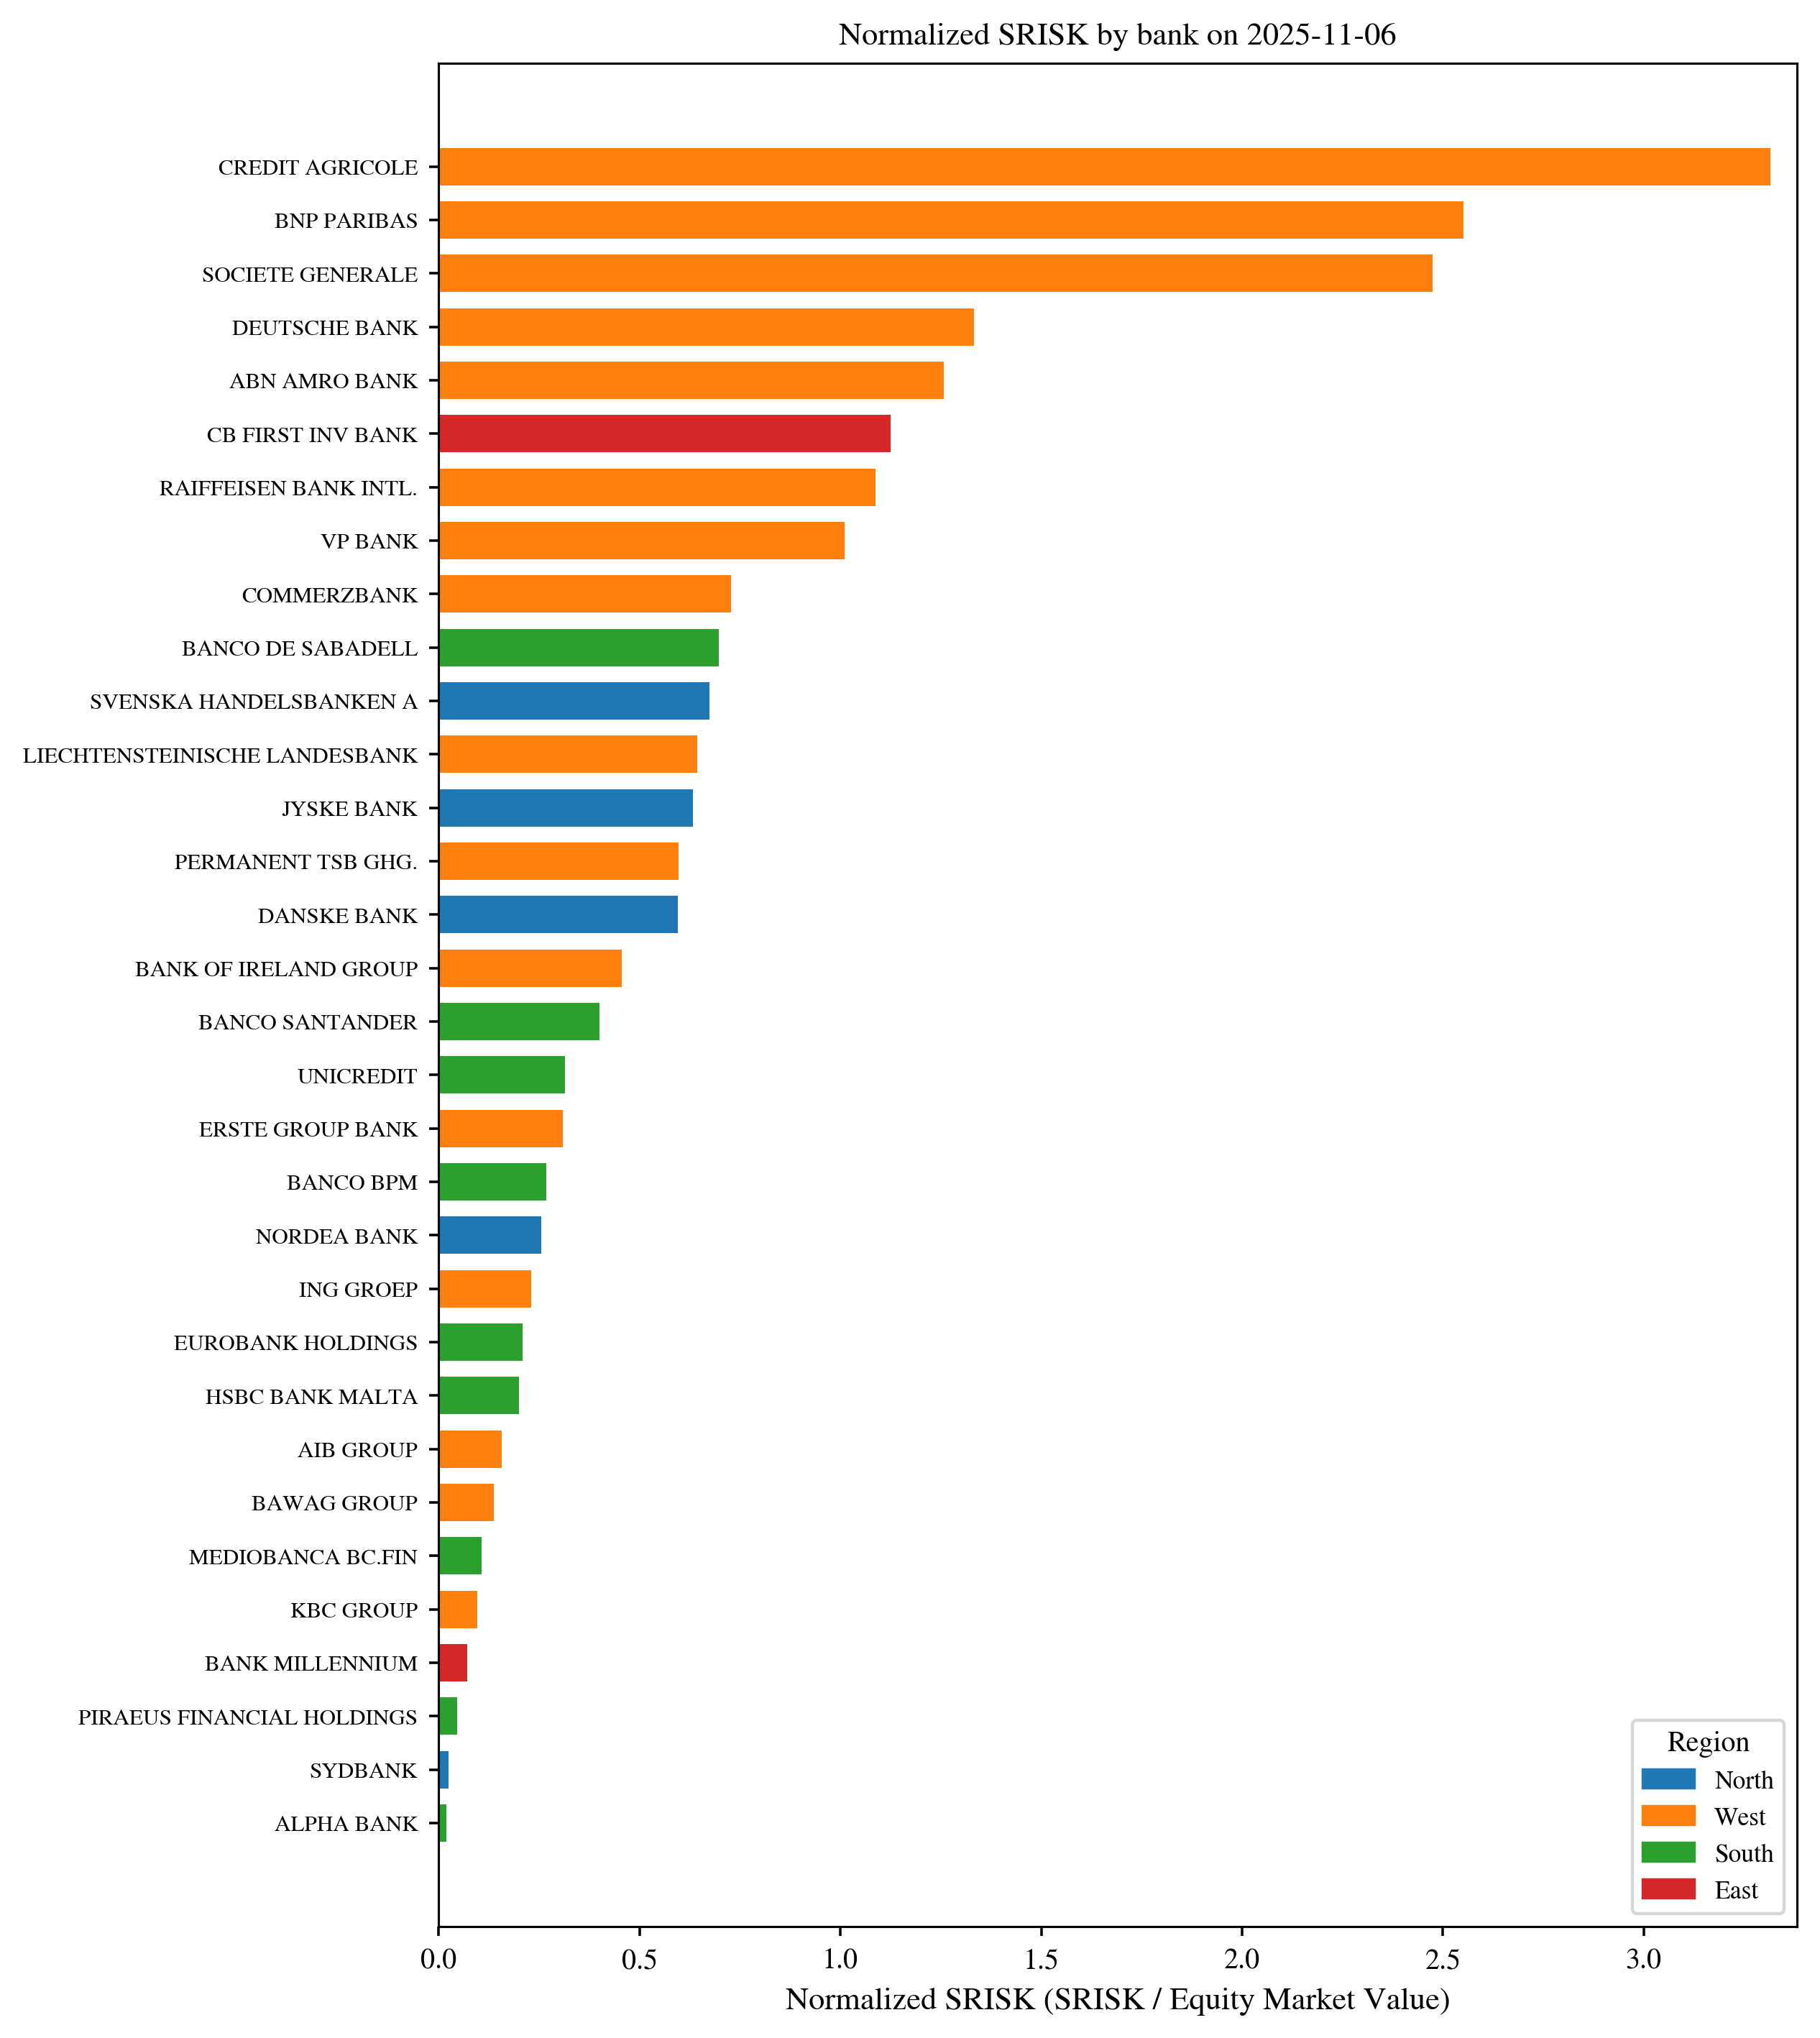

In [178]:
# Horizontal bar chart of ranked normalized SRISK (coloured by region) at a specified date
# Uses dataset-specific region mapping (GSIB vs OSII)

NORM_KEY = "SRISK_norm_max0"      # or "SRISK_norm"
RANK_DATE = "2025-11-06"          # <- change this
EXCLUDE_ZEROS = True
CAP_RATIO = None                  # e.g., 1.0 to cap extreme outliers; None = no cap

df = runs.get(PLOT_RUN, {}).get(NORM_KEY)

if df is None or df.empty:
    raise ValueError(
        f"No '{NORM_KEY}' found (or empty) for PLOT_RUN='{PLOT_RUN}'. "
        f"Make sure you computed and stored runs[run]['{NORM_KEY}']."
    )

# Make sure the mapping selector exists
if "get_region_mapping" not in globals():
    raise ValueError(
        "get_region_mapping(plot_run) not found. Run the cell that defines "
        "REGION_BY_BANK_GSIB / REGION_BY_BANK_OSII and get_region_mapping()."
    )

df = df.copy()
df.index = pd.to_datetime(df.index)

rank_date = pd.to_datetime(RANK_DATE)

# Use most recent available date <= RANK_DATE if exact date missing
if rank_date not in df.index:
    df_upto = df.loc[df.index <= rank_date]
    if df_upto.empty:
        raise ValueError(
            f"No data on or before {rank_date.date()} for PLOT_RUN='{PLOT_RUN}'. "
            f"First available date is {df.index.min().date()}."
        )
    used_date = df_upto.index.max()
else:
    used_date = rank_date

# Extract values on the date
row = df.loc[used_date].dropna()

# Exclude zeros (useful for truncated series)
if EXCLUDE_ZEROS:
    row = row[row != 0]

# Optional cap for readability (nSRISK is a ratio)
if CAP_RATIO is not None:
    row = row[row < CAP_RATIO]

if row.empty:
    print(f"\nNo values to plot for {PLOT_RUN} on {used_date.date()} using {NORM_KEY}.")
else:
    # Build ranking DataFrame (ascending so largest appears at TOP in barh)
    ranking = (
        row.sort_values(ascending=True)
           .reset_index()
           .rename(columns={"index": "Bank", used_date: NORM_KEY})
    )

    # Dataset-specific region assignment
    region_map = get_region_mapping(PLOT_RUN)
    ranking["Region"] = ranking["Bank"].map(region_map).fillna("Unknown")

    # Dataset-specific colors
    if PLOT_RUN == "GSIB":
        region_colors = {
            "North America": "tab:blue",
            "Europe": "gold",          # "yellow" but more visible
            "Asia": "tab:green",
            "Unknown": "tab:gray",
        }
        region_order = ["North America", "Europe", "Asia", "Unknown"]
    else:
        region_colors = {
            "North": "tab:blue",
            "West":  "tab:orange",
            "South": "tab:green",
            "East":  "tab:red",
            "Unknown": "tab:gray",
        }
        region_order = ["North", "West", "South", "East", "Unknown"]

    bar_colors = ranking["Region"].map(region_colors).fillna("tab:gray").tolist()

    # Plot
    fig, ax = plt.subplots(figsize=(8.0, max(3.5, 0.28 * len(ranking))))
    ax.barh(ranking["Bank"], ranking[NORM_KEY], color=bar_colors, height=0.7)

    ax.set_title(f"Normalized SRISK by bank on {used_date.date()}", pad=6)
    ax.set_xlabel("Normalized SRISK (SRISK / Equity Market Value)")
    ax.set_ylabel("")
    ax.grid(False)
    ax.margins(x=0.02)
    ax.tick_params(axis="y", labelsize=7)

    # Legend (only regions present)
    from matplotlib.patches import Patch
    present_regions = [r for r in region_order if r in set(ranking["Region"])]
    legend_handles = [Patch(color=region_colors[r], label=r) for r in present_regions]
    ax.legend(handles=legend_handles, title="Region", loc="best", frameon=True, fontsize=8, title_fontsize=9)

    fig.tight_layout()
    plt.show()

### Eurozone focus

Omit all the non-Eurozone banks from the OSII dataframes

In [179]:
# Focus OSIIs on Eurozone banks only (EUR) — create a reusable group + per-run filtered frames

# 1) Define Eurozone OSII bank list (from your master list; keep ONLY EUR-area banks)
EUROZONE_BANKS = [
    # Austria
    "RAIFFEISEN BANK INTL.", "ERSTE GROUP BANK", "BAWAG GROUP",
    # Belgium
    "KBC GROUP",
    # Cyprus
    "BANK OF CYPRUS HOLDING",
    # Germany
    "DEUTSCHE BANK", "COMMERZBANK",
    # Spain
    "BBV.ARGENTARIA", "BANCO DE SABADELL", "BANCO SANTANDER", "CAIXABANK",
    # France
    "CREDIT AGRICOLE", "SOCIETE GENERALE", "BNP PARIBAS",
    # Greece
    "NATIONAL BK.OF GREECE", "PIRAEUS FINANCIAL HOLDINGS", "EUROBANK HOLDINGS", "ALPHA BANK",
    # Croatia
    "HRVATSKA POSTANSKA BANKA", "ZAGREBACKA BANKA SER A", "ADDIKO BANK",
    # Italy
    "MEDIOBANCA BC.FIN", "BPER BANCA", "INTESA SANPAOLO", "BANCO BPM", "UNICREDIT",
    # Lithuania
    "ARTEA BANKAS",
    # Luxembourg
    "BQ.INTL.LUXEMBOURG",
    # Malta
    "BANK OF VALETTA", "APS BANK",
    # Portugal (only the one that is clearly EUR)
    "BANCO COMR.PORTUGUES 'R'",
    # Slovenia
    "NOVA LJUBLJANSKA BANKA",
]

EUROZONE_BANKS = list(dict.fromkeys(EUROZONE_BANKS))  # de-duplicate, keep order

# 2) Helper: filter any dataframe to eurozone banks that are present
def _keep_eurozone_cols(df, euro_list=EUROZONE_BANKS):
    if df is None or df.empty:
        return df
    cols = [c for c in euro_list if c in df.columns]
    return df[cols].copy()

# 3) Apply to your OSII runs (store as new keys so nothing breaks downstream)
OSII_RUNS = ["OSII_A", "OSII_B", "OSII_C"]

for run_name in OSII_RUNS:
    r = runs.get(run_name, {})
    if not r:
        print(f"Skipping {run_name}: not found in runs.")
        continue

    # Filter the most-used objects if they exist
    for key in [
        "SRISK_local", "SRISK_local_max0",
        "SRISK_norm", "SRISK_norm_max0",
        "liabilities_aligned", "equity_aligned",
        "LRMES"
    ]:
        if key in r and isinstance(r[key], pd.DataFrame):
            r[f"{key}_EUR"] = _keep_eurozone_cols(r[key])

    runs[run_name] = r

    # Quick check
    example_key = "SRISK_norm_max0_EUR" if "SRISK_norm_max0_EUR" in r else None
    if example_key and r[example_key] is not None and not r[example_key].empty:
        print(f"{run_name}: kept {r[example_key].shape[1]} Eurozone banks for {example_key}.")
    else:
        print(f"{run_name}: Eurozone filter created (some frames may be empty if keys not computed yet).")

# 4) Optional convenience: make a combined Eurozone OSII set (if you ever want one table)
EUROZONE_OSII_ALL = sorted(set().union(*[
    set([b for b in EUROZONE_BANKS if b in runs.get(run, {}).get("SRISK_norm_max0", pd.DataFrame()).columns])
    for run in OSII_RUNS
]))
print(f"\nEurozone bank universe present across OSII runs (based on SRISK_norm_max0 columns): {len(EUROZONE_OSII_ALL)}")

OSII_A: kept 21 Eurozone banks for SRISK_norm_max0_EUR.
OSII_B: kept 24 Eurozone banks for SRISK_norm_max0_EUR.
OSII_C: kept 26 Eurozone banks for SRISK_norm_max0_EUR.

Eurozone bank universe present across OSII runs (based on SRISK_norm_max0 columns): 26


Aggregate SRISK for Eurozone banks, when we do this we do like to have the max{0,...} operator

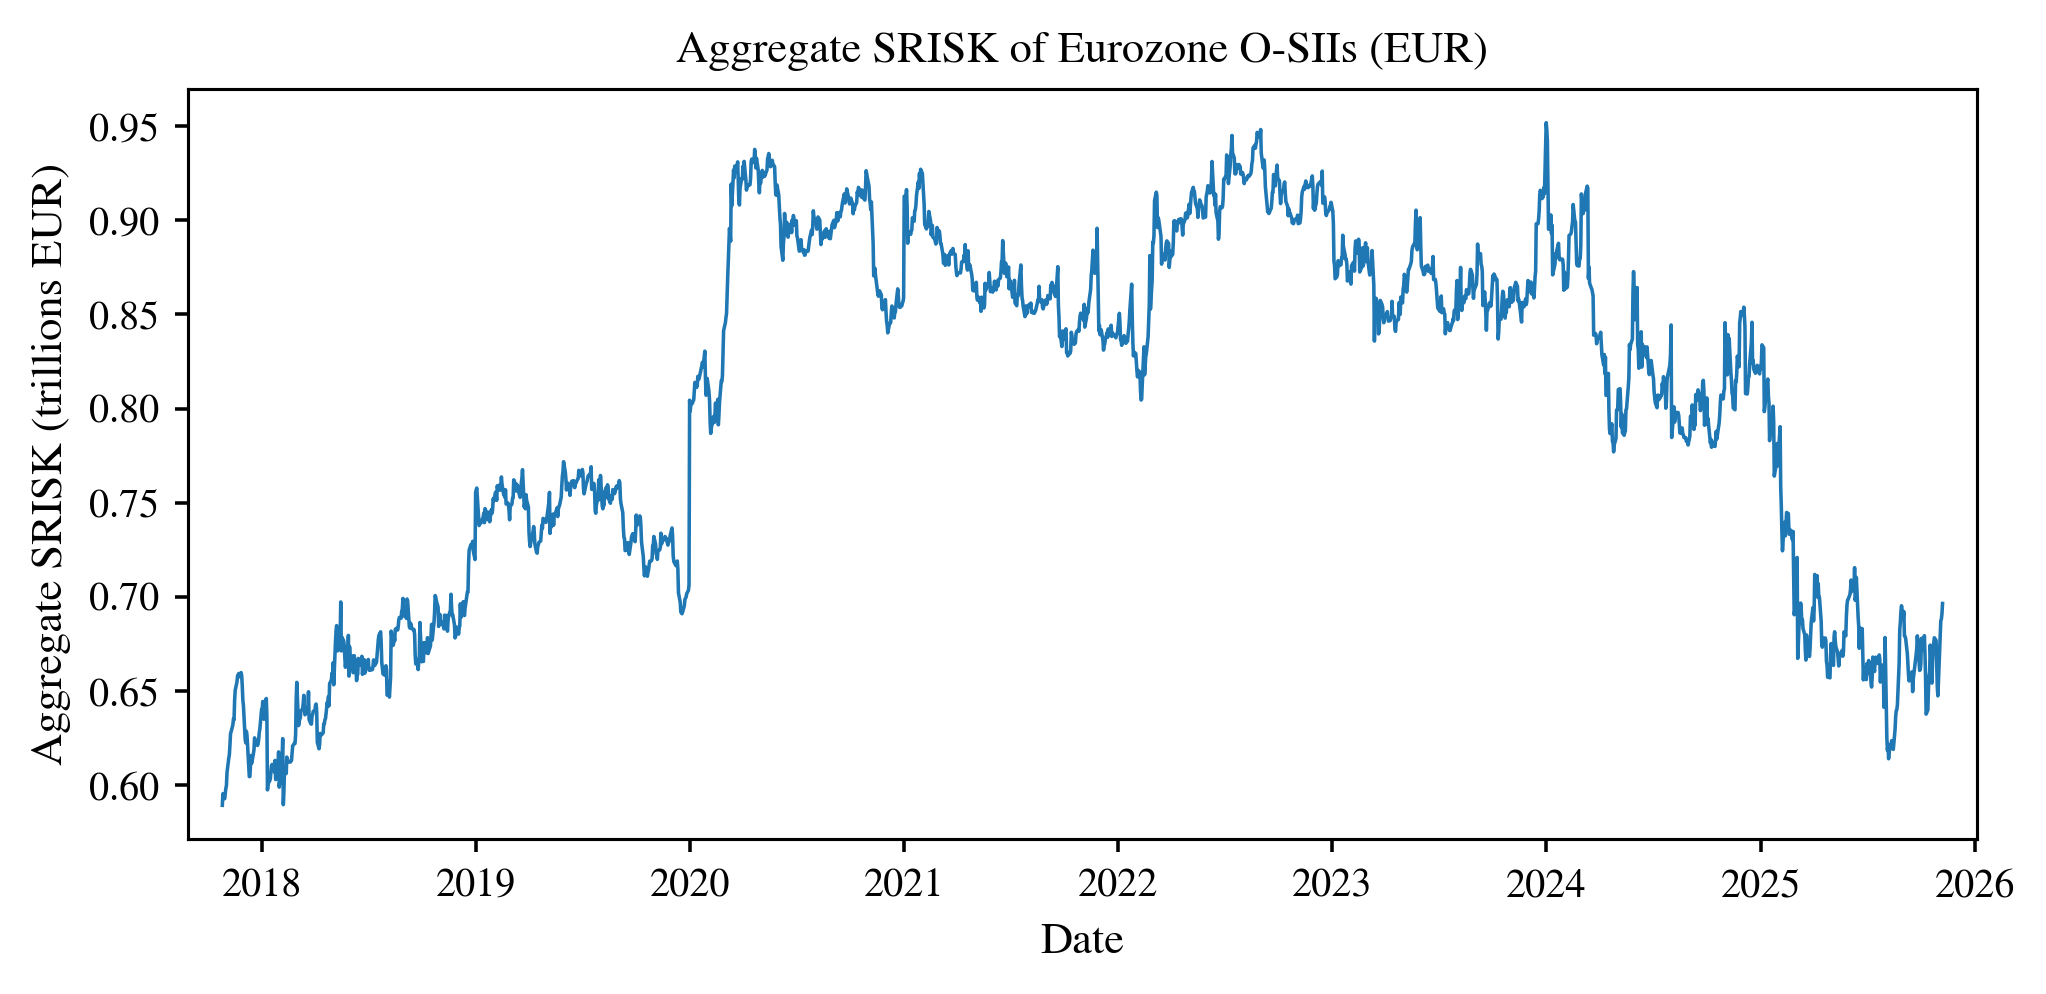

In [189]:
# Aggregate SRISK across Eurozone OSIIs (EUR) — no explicit k needed

AGG_RUN = "OSII_C"                      # <- change if needed: "OSII_A" / "OSII_B" / "OSII_C"
SRISK_KEY_EUR = "SRISK_local_max0_EUR"  # or "SRISK_local_EUR" if you want negatives too

r = runs.get(AGG_RUN, {})
srisk_obj = r.get(SRISK_KEY_EUR)

if srisk_obj is None:
    raise ValueError(
        f"No '{SRISK_KEY_EUR}' found for AGG_RUN='{AGG_RUN}'. "
        f"Make sure you created the *_EUR frames and computed SRISK for this run."
    )

if isinstance(srisk_obj, dict):
    if len(srisk_obj) == 0:
        raise ValueError(f"'{SRISK_KEY_EUR}' is an empty dict for AGG_RUN='{AGG_RUN}'.")
    if len(srisk_obj) > 1:
        raise ValueError(
            f"'{SRISK_KEY_EUR}' contains multiple k values ({list(srisk_obj.keys())}). "
            "Either keep one k in the notebook, or select one explicitly."
        )
    srisk_df = next(iter(srisk_obj.values())).copy()
else:
    srisk_df = srisk_obj.copy()

# Ensure datetime index
srisk_df.index = pd.to_datetime(srisk_df.index)

# Aggregate across banks (columns)
srisk_total = srisk_df.sum(axis=1)

# Plot (millions -> trillions)
fig, ax = plt.subplots(figsize=FIG_FULL)

ax.plot(
    srisk_total.index,
    srisk_total / 1e6,
    linewidth=0.8
)

ax.set_title("Aggregate SRISK of Eurozone O-SIIs (EUR)", pad=6)
ax.set_xlabel("Date")
ax.set_ylabel("Aggregate SRISK (trillions EUR)")

ax.grid(False)
ax.margins(x=0.02)

fig.tight_layout()
plt.show()

Our key chart will focus on one capital ratio, k = 0.08, since this is most in line with Basel. The others are for robustness and show that dynamics remain the same.

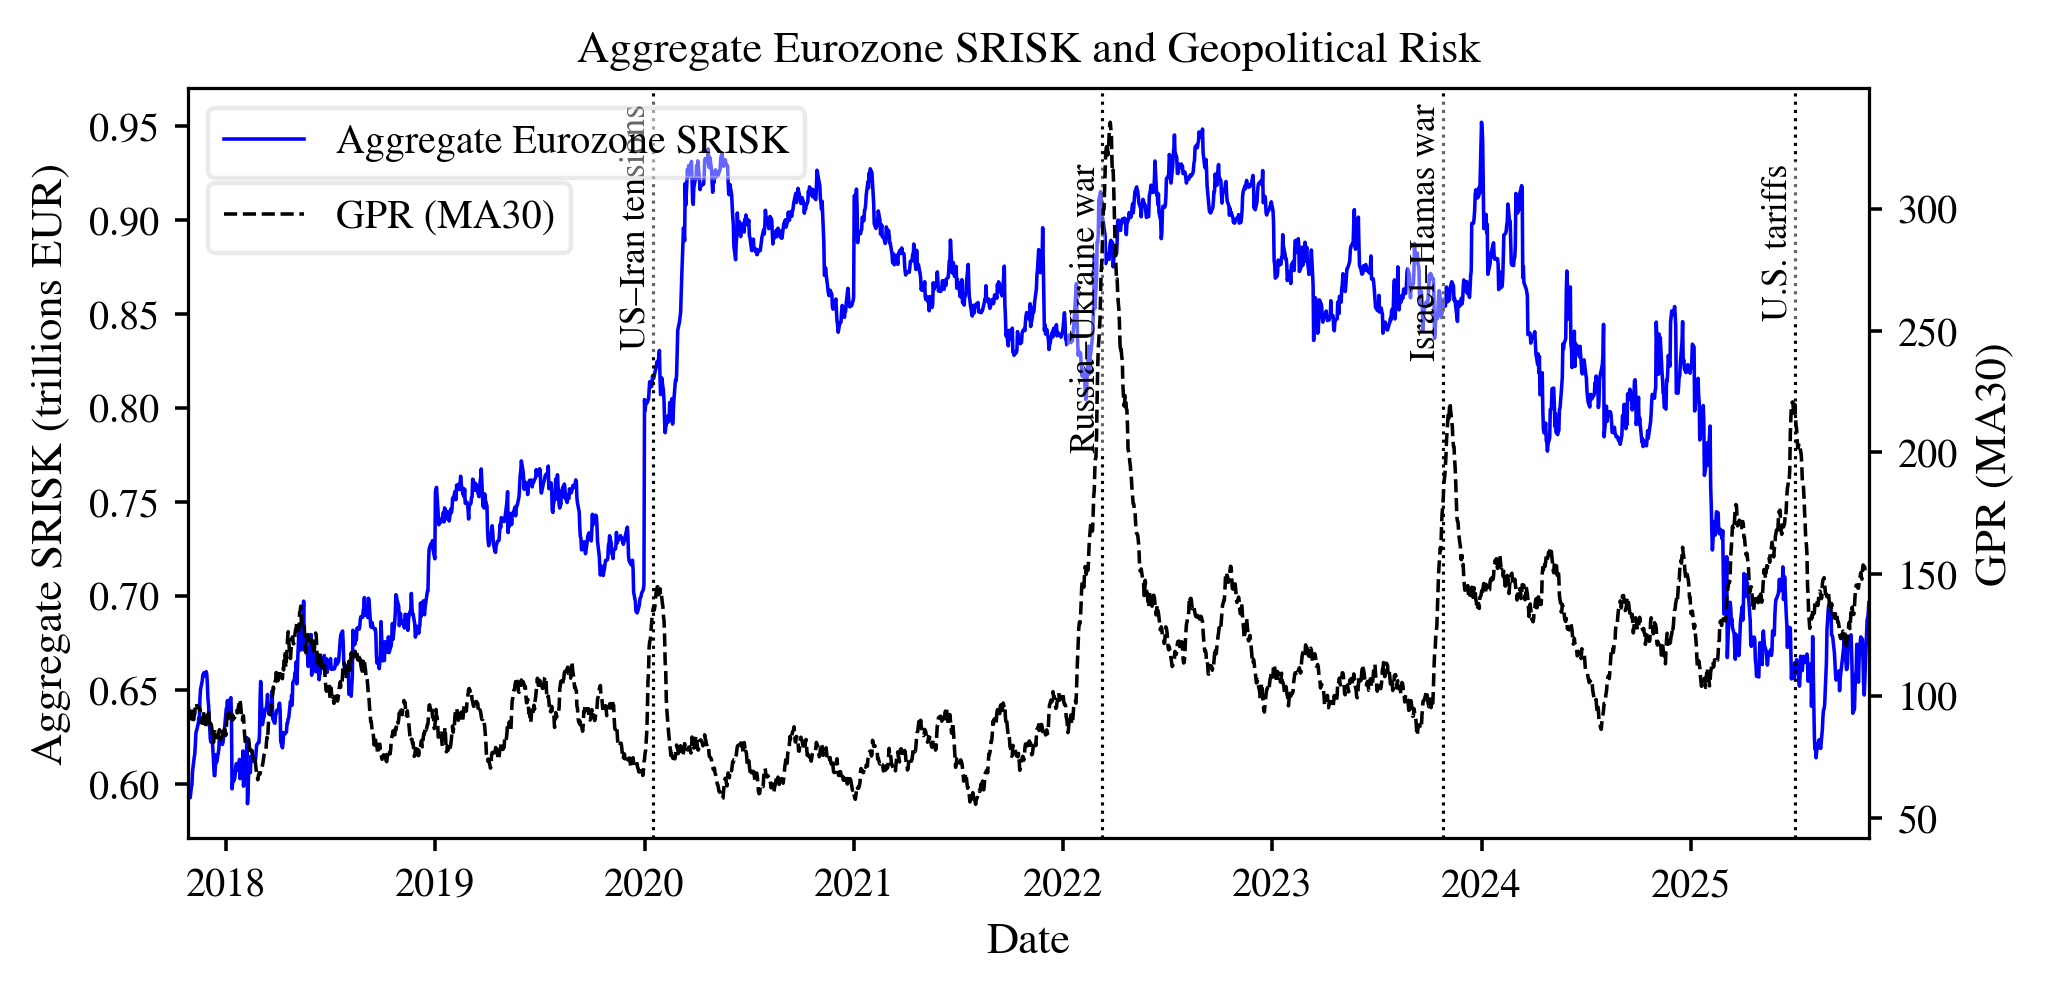

In [197]:
# Plot total SRISK in Eurozone (EUR) and GPR index over time
# -> GPR is restricted to the SRISK timeframe

AGG_RUN = "OSII_C"                      # <- change if needed: "OSII_A" / "OSII_B" / "OSII_C"
SRISK_KEY_EUR = "SRISK_local_max0_EUR"  # or "SRISK_local_EUR" if you want negatives too

r = runs.get(AGG_RUN, {})
srisk_obj = r.get(SRISK_KEY_EUR)

if srisk_obj is None:
    raise ValueError(
        f"No '{SRISK_KEY_EUR}' found for AGG_RUN='{AGG_RUN}'. "
        f"Make sure you created the *_EUR frames and computed SRISK for this run."
    )

# Handle either:
# (a) dict-by-k -> take the only entry
# (b) single DataFrame
if isinstance(srisk_obj, dict):
    if len(srisk_obj) == 0:
        raise ValueError(f"'{SRISK_KEY_EUR}' is an empty dict for AGG_RUN='{AGG_RUN}'.")
    if len(srisk_obj) > 1:
        raise ValueError(
            f"'{SRISK_KEY_EUR}' contains multiple k values ({list(srisk_obj.keys())}). "
            "Either keep one k in the notebook, or select one explicitly."
        )
    srisk_df = next(iter(srisk_obj.values())).copy()
else:
    srisk_df = srisk_obj.copy()

# Ensure datetime index
srisk_df.index = pd.to_datetime(srisk_df.index)

# Aggregate across Eurozone banks (columns)
srisk_total_eur = srisk_df.sum(axis=1)

# --- Restrict GPR to the SRISK timeframe ---
xmin, xmax = srisk_total_eur.index.min(), srisk_total_eur.index.max()

gpr_plot = gpr_data.copy()
gpr_plot.index = pd.to_datetime(gpr_plot.index)

# keep only overlapping dates
gpr_plot = gpr_plot.loc[(gpr_plot.index >= xmin) & (gpr_plot.index <= xmax)]

# ---- Plot with GPR on right axis ----
fig, ax1 = plt.subplots(figsize=FIG_FULL)
ax2 = ax1.twinx()

# Left axis: total Eurozone SRISK (EUR)
ax1.plot(
    srisk_total_eur.index,
    srisk_total_eur / 1e6,  # millions -> trillions
    label=f"Aggregate Eurozone SRISK",
    color="blue",
    linewidth=0.8
)

# Right axis: GPR index (trimmed)
ax2.plot(
    gpr_plot.index,
    gpr_plot["GPR"],
    color="black",
    linestyle="--",
    linewidth=0.8,
    label="GPR (MA30)"
)

ax1.set_title("Aggregate Eurozone SRISK and Geopolitical Risk", pad=6)
ax1.set_xlabel("Date")
ax1.set_ylabel("Aggregate SRISK (trillions EUR)")
ax2.set_ylabel("GPR (MA30)")

# Force x-limits to SRISK window (prevents old years from showing)
ax1.set_xlim(xmin, xmax)

# Event markers (restricted to SRISK x-range)
events = [
    ("Israel–Hezbollah war", "2006-07-12"),
    ("NATO intervention Libya", "2011-03-30"),
    ("ISIS caliphate declared", "2014-07-29"),
    ("Paris attacks", "2015-11-30"),
    ("US–Iran tensions", "2020-01-15"),
    ("Russia–Ukraine war", "2022-03-10"),
    ("Israel–Hamas war", "2023-10-25"),
    ("U.S. tariffs", "2025-07-01"),
]

for i, (label, date_str) in enumerate(events):
    dt = pd.Timestamp(date_str)
    if not (xmin <= dt <= xmax):
        continue
    ax1.axvline(dt, color="black", linestyle=":", linewidth=0.7)
    y_pos = 0.98 if i % 2 == 0 else 0.90
    ax1.text(
        dt,
        y_pos,
        label,
        transform=ax1.get_xaxis_transform(),
        rotation=90,
        va="top",
        ha="right",
        fontsize=8,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.4, pad=0.6),
    )

# Legends (stacked)
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

leg1 = ax1.legend(
    h1, l1,
    loc="upper left",
    bbox_to_anchor=(0.0, 1),
    frameon=True,
    fontsize=9
)
leg1.get_frame().set_alpha(0.4)
ax1.add_artist(leg1)

leg2 = ax1.legend(
    h2, l2,
    loc="upper left",
    bbox_to_anchor=(0.0, 0.9),
    frameon=True,
    fontsize=9
)
leg2.get_frame().set_alpha(0.4)

ax1.grid(False)
ax1.margins(x=0.02)
fig.tight_layout()
plt.show()

In [ ]:
# Correlation between GPR and aggregate Eurozone SRISK (OSII group)
AGG_RUN = "OSII_A"                      # <- "OSII_A" / "OSII_B" / "OSII_C"
SRISK_KEY_EUR = "SRISK_local_max0_EUR"  # or "SRISK_local_EUR"
USE_TRILLIONS = True                    # use SRISK in trillions (just rescales; correlation unchanged)

r = runs.get(AGG_RUN, {})
srisk_obj = r.get(SRISK_KEY_EUR)

if srisk_obj is None:
    raise ValueError(
        f"No '{SRISK_KEY_EUR}' found for AGG_RUN='{AGG_RUN}'. "
        f"Make sure you created the *_EUR frames and computed SRISK for this run."
    )

# Handle either dict-by-k (single entry) or single DataFrame
if isinstance(srisk_obj, dict):
    if len(srisk_obj) == 0:
        raise ValueError(f"'{SRISK_KEY_EUR}' is an empty dict for AGG_RUN='{AGG_RUN}'.")
    if len(srisk_obj) > 1:
        raise ValueError(
            f"'{SRISK_KEY_EUR}' contains multiple k values ({list(srisk_obj.keys())}). "
            "Either keep one k in the notebook, or select one explicitly."
        )
    srisk_df = next(iter(srisk_obj.values())).copy()
else:
    srisk_df = srisk_obj.copy()

srisk_df.index = pd.to_datetime(srisk_df.index)

# Aggregate across banks
srisk_total = srisk_df.sum(axis=1)

# Scale (optional; does NOT affect correlation)
if USE_TRILLIONS:
    srisk_total = srisk_total / 1e6  # millions -> trillions

# Prepare GPR
gpr = gpr_data.copy()
gpr.index = pd.to_datetime(gpr.index)

if "GPR" not in gpr.columns:
    raise ValueError("gpr_data must have a 'GPR' column (e.g., MA30 series).")

# Build aligned dataframe on overlapping dates
xmin, xmax = srisk_total.index.min(), srisk_total.index.max()
gpr_trim = gpr.loc[(gpr.index >= xmin) & (gpr.index <= xmax), "GPR"]

aligned = (
    pd.concat([srisk_total.rename("SRISK_agg"), gpr_trim.rename("GPR")], axis=1)
      .dropna()
)

if aligned.empty:
    raise ValueError("No overlapping (non-NaN) dates between SRISK and GPR after trimming.")

# Correlations
pearson = aligned["SRISK_agg"].corr(aligned["GPR"], method="pearson")
spearman = aligned["SRISK_agg"].corr(aligned["GPR"], method="spearman")

print(f"AGG_RUN = {AGG_RUN}")
print(f"Overlap window: {aligned.index.min().date()} to {aligned.index.max().date()}")
print(f"Observations used: {len(aligned):,}\n")

print(f"Pearson corr(SRISK_agg, GPR)  = {pearson:.4f}")
print(f"Spearman corr(SRISK_agg, GPR) = {spearman:.4f}")

# Optional: check simple lead/lag correlations (does GPR lead SRISK?)
# Positive lag means: correlate SRISK(t) with GPR(t - lag) -> GPR leads by 'lag'
LAGS = [0, 5, 10, 20]  # adjust to your data frequency (e.g., weekly/daily)
print("\nLag correlations (GPR leads SRISK):")
for lag in LAGS:
    corr_lag = aligned["SRISK_agg"].corr(aligned["GPR"].shift(lag))
    print(f"  lag={lag:>3}: corr = {corr_lag:.4f}")

AGG_RUN = OSII_A
Overlap window: 2001-12-14 to 2025-10-31
Observations used: 6,231

Pearson corr(SRISK_agg, GPR)  = -0.3371
Spearman corr(SRISK_agg, GPR) = -0.2688

Lag correlations (GPR leads SRISK):
  lag=  0: corr = -0.3371
  lag=  5: corr = -0.3388
  lag= 10: corr = -0.3407
  lag= 20: corr = -0.3441
